In [ ]:
""" import useful functions """
##########################################################################
import os

# set the environment variable to control the number of threads
# NEEDS TO BE DONE BEFORE CCL IS IMPORTED
original_omp_num_threads = os.environ.get('OMP_NUM_THREADS', None)
os.environ['OMP_NUM_THREADS'] = '1'

# Generic
#import pandas as pd
import numpy as np
import scipy
from itertools import islice, cycle
import math
import os
import sys
from scipy.integrate import odeint
#from joblib import Parallel, delayed
import itertools
from importlib import reload
from functools import lru_cache
import scipy.integrate
from scipy.interpolate import interpn
from scipy.interpolate import CubicSpline
import gc
from scipy.signal import savgol_filter

# cosmology
import pyccl as ccl
from astropy.io import fits
import yaml
#import sacc
import time

# SRD Binning
import srd_redshift_distributions as srd
import binning

# Data Visualization
import matplotlib.pyplot as plt
#from tabulate import tabulate
from matplotlib.colors import LogNorm
#import seaborn as sns

# Parallelising 
from multiprocessing import Pool
import multiprocessing

# MCMC
import emcee
import matplotlib.pyplot as plt
from scipy.optimize import minimize
#import corner
#from chainconsumer import ChainConsumer, Chain, make_sample
from IPython.display import display, Math
from multiprocessing import Pool
#from tqdm import tqdm

# HiCOLA background
from HiCOLA.Frontend import expression_builder as eb
import HiCOLA.Frontend.numerical_solver as ns
from HiCOLA.Frontend.read_parameters import read_in_parameters
import sympy as sym


In [ ]:
# Cubic Galileon emu and background
from CubicGalileonEmu.load import *
from CubicGalileonEmu.viz import *
from CubicGalileonEmu.pca import *
from CubicGalileonEmu.gp import *
from CubicGalileonEmu.emu import *
from CubicGalileonEmu.mcmc import *


if_train_all = False ## Re-train all the models. Time-consuming. 
if_mcmc_all = False  ## Full MCMC run. Time-consuming. 
if_savefig = False

from configobj import ConfigObj
import subprocess

ModuleNotFoundError: No module named 'CubicGalileonEmu'

In [4]:
"""For tests"""

cosmo_testing = ccl.Cosmology(Omega_c = (0.1417493400784 - 0.0223)/0.67**2,
                           Omega_b =  0.0223/0.67**2,
                           h = 0.67,
                           n_s = 0.9665,
                           A_s = 2.01e-9)

cosmo_testing_linear = ccl.Cosmology(Omega_c = (0.1417493400784 - 0.0223)/0.67**2,
                           Omega_b =  0.0223/0.67**2,
                           h = 0.67,
                           n_s = 0.9665,
                           A_s = 2.01e-9,
                           matter_power_spectrum='linear')

In [5]:
# Loading CuGal files

Bk_all, Bk_all_smooth, k_all, z_all = load_boost_data()
Bk_lin_all, _, _ = load_boost_data_lin()
p_all = load_params()

print(p_all.shape, flush=True)

## Data prep
z_index = 1

y_vals = Bk_all[:, z_index, :]

# y_ind = np.arange(0, y_vals.shape[1])
y_ind = k_all

# Load validation data

Bk_all_val, Bk_lin_all_val, _, _ = load_boost_data(LIBRARY_BK_FILE_VAL, LIBRARY_ZK_FILE_VAL)
target_vals = Bk_all_val[:, z_index, :]
input_params = load_params(LIBRARY_PARAM_FILE_VAL)

train_indices = [i for i in np.arange(49)] # if i not in test_indices]
print(train_indices, flush=True)

p_all_train = p_all[train_indices]
y_vals_train = Bk_all[:, z_index, :][train_indices]

sepia_data = sepia_data_format(p_all_train, y_vals_train, y_ind)
print(sepia_data)
model_filename = '/global/homes/c/carolazn/CubicGalileonEmu/CubicGalileonEmu/model/multivariate_model_z_index' + str(z_index) 

#sepia_model = do_pca(sepia_data, exp_variance=0.95)
#sepia_model = do_gp_train(sepia_model, model_filename)
#plot_train_diagnostics(sepia_model)

if if_train_all:
    
    do_gp_train_multiple(model_dir='/global/homes/c/carolazn/CubicGalileonEmu/CubicGalileonEmu/model/', 
                        p_train_all = p_all[train_indices],
                        y_vals_all = Bk_all_smooth[train_indices],
                        y_ind_all = k_all,
                        z_index_range=range(49))



(50, 5)
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48)]
This SepiaData instance implies the following:
This is a simulator (eta)-only model, y dimension 768
m  =    49 (number of simulated data)
p  =     1 (number of inputs)
q  =     5 (number of additional simulation inputs)
pu NOT SET (transformed response dimension); call method create_K_basis 



In [6]:
sepia_model_list, sepia_data_list = load_model_multiple(model_dir='/global/homes/c/carolazn/CubicGalileonEmu/CubicGalileonEmu/model/', 
                                        p_train_all=p_all[train_indices],
                                        y_vals_all=Bk_all_smooth[train_indices],
                                        y_ind_all=k_all,
                                        z_index_range=range(50))


Number of models loaded: 50 from: /global/homes/c/carolazn/CubicGalileonEmu/CubicGalileonEmu/model/


#### Test Cubic Galileon Emulator

In [7]:
input_params_and_redshift = np.append(np.array([0.30,0.97498,2.1,0.67,1.0]) , 0.0)     
#input_params_and_redshift = np.append([input_params_and_redshift],[input_params_and_redshift],axis=0)
print("z = ", input_params_and_redshift[-1])
print("params = ", input_params_and_redshift[:-1])
print((z_all - input_params_and_redshift[-1]).argmin())
bk_target, err_target = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list,sepia_data_list, z_all)

k_test = np.logspace(-3, 1, 100)
plt.semilogx(k_test, np.interp(k_test, k_all, bk_target.reshape(len(k_all))))


z =  0.0
params =  [0.3     0.97498 2.1     0.67    1.     ]
0


TypeError: solve() got an unexpected keyword argument 'sym_pos'

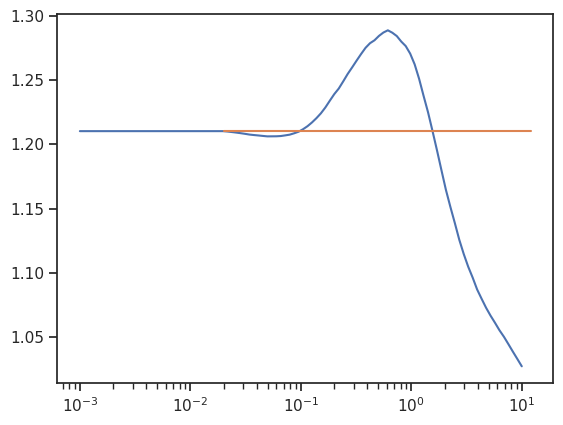

In [7]:
#Old_compare = bk_target.reshape(len(k_all))
k_test = np.logspace(-3, 1, 100)
#Old_compare =bk_target.reshape(len(k_all))
plt.semilogx(k_test, np.interp(k_test, k_all, bk_target.reshape(len(k_all))))

plt.semilogx(k_all, bk_target[0]*np.ones(len(k_all)))

In [8]:
# Define the range of redshift values
z_range = np.linspace(0.0, 12, 50)  # Example range from 0 to 1.5 with 50 points
bk_target_2D = []

# Loop over each redshift value
for z_val in z_range:
    input_params_and_redshift[-1] = z_val  # Update redshift
    bk_target, _ = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list,sepia_data_list, z_all)
    bk_target_2D.append(bk_target.flatten())  # Flatten to 1D and append

# Convert to a 2D array with shape (len(z_range), len(k_all))
bk_target_2D = np.array(bk_target_2D)

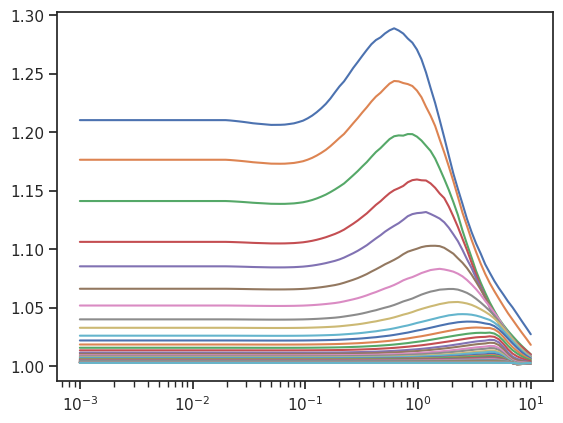

In [9]:
for i in range(len(z_range)):
    plt.semilogx(k_test, np.interp(k_test, k_all, bk_target_2D[i]))


# 1. Mock redshift distribution

In [10]:
# Define the redshift interval and forecast years
redshift_range = np.linspace(0.01, 3.5, 500)
forecast_years = ["1", "10"]  # Assuming integers are appropriate

# Create a dictionary to store the redshift distributions
# for each forecast year and galaxy sample
redshift_distribution = {
    "sources": {},
    "lenses": {}
}

for year in forecast_years:
    source_dist = srd.SRDRedshiftDistributions(redshift_range, 
                                               galaxy_sample="source_sample",
                                               forecast_year=year)
    lens_dist = srd.SRDRedshiftDistributions(redshift_range, 
                                             galaxy_sample="lens_sample",
                                             forecast_year=year)

    redshift_distribution["sources"][year] = source_dist.get_redshift_distribution(normalised=True,
                                                                                   save_file=False)
    redshift_distribution["lenses"][year] = lens_dist.get_redshift_distribution(normalised=True,
                                                                                save_file=False)

# Uncomment to check if the dictionary is populated correctly
# print(redshift_distribution["sources"].keys())


bins = {
    "sources": {},
    "lenses": {}
}

# Perform the binning procedure
for year in forecast_years:
    bins["sources"][year] = binning.Binning(redshift_range, 
                                            redshift_distribution["sources"][year],
                                            year).source_bins(normalised=True,
                                                              save_file=False)
    bins["lenses"][year] = binning.Binning(redshift_range, 
                                           redshift_distribution["lenses"][year],
                                           year).lens_bins(normalised=True,
                                                           save_file=False)


#(5, 256)
Binned_distribution_lens = [list(bins["lenses"]["1"].items())[0][1]]
for i in range(4):
    Binned_distribution_lens = np.append(Binned_distribution_lens,\
               [list(bins["lenses"]["1"].items())[i+1][1]], axis=0)

Binned_distribution_source = [list(bins["sources"]["1"].items())[0][1]]
for i in range(4):
    Binned_distribution_source = np.append(Binned_distribution_source,\
               [list(bins["sources"]["1"].items())[i+1][1]], axis=0)
    
print(Binned_distribution_lens.shape)
print(Binned_distribution_source.shape)
print(redshift_range.shape)

(5, 500)
(5, 500)
(500,)


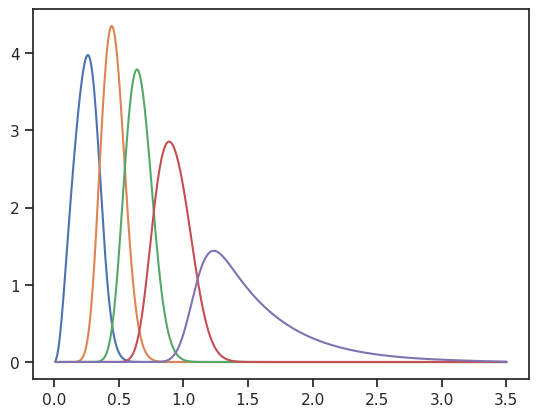

In [11]:
## TEST1: Plots to check binned source redshift distribution
z = redshift_range

plt.plot(z ,Binned_distribution_source[0])
plt.plot(z ,Binned_distribution_source[1])
plt.plot(z ,Binned_distribution_source[2])
plt.plot(z ,Binned_distribution_source[3])
plt.plot(z ,Binned_distribution_source[4])


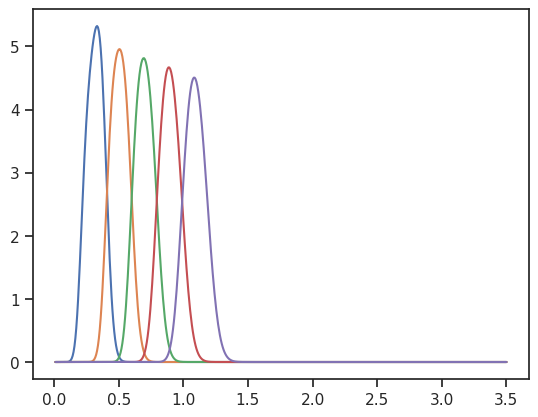

In [12]:
## TEST2: Plots to check binned redshift distribution


plt.plot(z ,Binned_distribution_lens[0])
plt.plot(z ,Binned_distribution_lens[1])
plt.plot(z ,Binned_distribution_lens[2])
plt.plot(z ,Binned_distribution_lens[3])
plt.plot(z ,Binned_distribution_lens[len(Binned_distribution_lens)-1])

## 1b. Create mock bias distribution

In [13]:
# Match SRD
# from Table 2 in https://arxiv.org/pdf/2212.09345
Bias_distribution_fiducial = np.array([1.562362*np.ones(len(z)),
                             1.732963*np.ones(len(z)),
                             1.913252*np.ones(len(z)),
                             2.100644*np.ones(len(z)),
                             2.293210*np.ones(len(z))])

# Background (LCDM and Cubic Galileon)

In [14]:
"""Define tracker functions"""

# If we are on the tracker, we will get the following constraints equations

# For today formalism 
def k_1T(Omg_m, Omg_r, f_phi):
    return 6*f_phi*(Omg_m + Omg_r - 1)

def wr_funct(T_CMB):
    return 4.48150052e-7*T_CMB**4 *(1+ 3.044*7/8 * (4/11)**(4/3))

T_CMB = 2.72548 # K
print(wr_funct(T_CMB))

4.182345109176885e-05


In [15]:
"""Background in GR"""

# dimensionless hubble parameter in GR
def E_LCDM(cosmoMCMCStep, a):
    Omg_r = cosmoMCMCStep["Omega_g"]*(1+ 3.046*7/8 * (4/11)**(7/8))
    return np.sqrt(cosmoMCMCStep["Omega_m"]/a**3 +Omg_r/a**4 + (1 - cosmoMCMCStep["Omega_m"] - Omg_r))

# deriv. of E wrt scale factor, GR
def dEda(cosmo, a):
    Omg_r = cosmo["Omega_g"]*(1+ 3.046*7/8 * (4/11)**(7/8))
    E_val = E_LCDM(cosmo, a)
    
    return (-3*cosmo["Omega_m"]/a**4 -4*Omg_r/a**5)/2/E_val


In [16]:
def initialize_Horndeski():
    """
    Generates and stores the Horndeski functions needed for simulations.
    This should be run once at the start.
    """
    global lambdified_functions  # Store in a global variable for later use

    to_exec = eb.declare_symbols()
    
    # Create a dictionary for execution
    local_dict = {"sym": sym}
    
    # Execute symbol declarations
    exec(to_exec, globals(), local_dict)  

    # Store declared symbols into globals()
    globals().update(local_dict)

    # Generate symbolic Horndeski functions
    lambdified_functions = lambda K, G3, G4, symbol_list, mass_ratio_list: eb.create_Horndeski(
        K, G3, G4, symbol_list, mass_ratio_list
    )

    print("Horndeski functions initialized.")

# Call this once at the start
initialize_Horndeski()


Horndeski functions initialized.


In [17]:
K = sym.Symbol('X')*sym.Symbol('k_1')#read_out_dict['K']
G3 = sym.Symbol('X')*sym.Symbol('g_31')#read_out_dict['G3']
G4 = 0.5#read_out_dict['G4']
symbol_list = ['k_1', 'g_31']# read_out_dict['symbol_list']
mass_ratio_list = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]#read_out_dict['mass_ratio_list']

# Generate the Horndeski functions
functions_CuGal_HiCOLA = lambdified_functions(K, G3, G4, symbol_list, mass_ratio_list)


In [18]:
def run_Horndeski_simulation(f_phi, cosmo):
    """
    Given the Horndeski and numerical ini files, solves the system and returns:
    - a_arr (scale factor array)
    - UE_arr (Hubble parameter)
    - coupling_factor_arr (Horndeski coupling factor)
    """
    Omg_L = (1. - f_phi)*(1. - cosmo['Omega_g']*(1+ 3.046*7/8 * (4/11)**(7/8)) - cosmo['Omega_m'])
    k1_track = k_1T(cosmo['Omega_m'], cosmo['Omega_g']*(1+ 3.046*7/8 * (4/11)**(7/8)), f_phi)

    # Read the parameters from the ini files
    read_out_dict = {'model_name': 'horndeski_model', 
                     'cosmo_name': 'run_X', 
                     'output_directory': '/global/homes/c/carolazn/CuGal_Emu_project_mcmc/HiCOLA_background/Output_validation', 
                     'K': sym.Symbol('X')*sym.Symbol('k_1'), 
                     'G3': sym.Symbol('X')*sym.Symbol('g_31'), 
                     'G4': 0.500000000000000, 
                     'mass_ratio_list': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 
                     'symbol_list': ['k_1', 'g_31'], 
                     'closure_declaration': ['parameters', 1], 
                     'simulation_parameters': [1000, 1000.0, False, 0.0, False], 
                     'threshold_value': 0.0, 
                     'GR_flag': False, 
                     'cosmological_parameters': [cosmo['Omega_g']*(1+ 3.046*7/8 * (4/11)**(7/8)), cosmo['Omega_m'], Omg_L], 
                     'Horndeski_parameters': [k1_track, 0.9], 'initial_conditions': [1.0, 1.0]}

    # Update from funct, defined further up
    read_out_dict.update(functions_CuGal_HiCOLA)
    
    # Ensure E, phiprime, omegar, omegam are accessible from globals()
    E = globals().get('E')
    phiprime = globals().get('phiprime')
    omegar = globals().get('omegar')
    omegam = globals().get('omegam')

    # Define 'odeint_parameter_symbols'
    odeint_parameter_symbols = [E, phiprime, omegar, omegam]
    read_out_dict.update({'odeint_parameter_symbols': odeint_parameter_symbols})
    # Run the solver
    background_quantities = ns.run_solver(read_out_dict)

    # Extract required arrays
    a_arr = background_quantities['a']
    UE_arr = background_quantities['Hubble']
    coupling_factor_arr = background_quantities['coupling_factor']

    return a_arr, UE_arr, coupling_factor_arr


In [19]:
"""
def E_CuGal(f_phi, cosmo, a):
    if f_phi == 0.0:
        return E_LCDM(cosmo, a)
    else:
        a_arr, UE_arr, coupling_factor_arr = run_Horndeski_simulation(f_phi,cosmo)
    
        spl = CubicSpline(a_arr[::-1], UE_arr[::-1])
        return spl(a)
"""

def CuGal_initialize(f_phi, cosmo):
    if f_phi == 0.0:
        a_arr = np.logspace(0,-3,1000)
        return a_arr, E_LCDM(cosmo, a_arr), np.ones(1000)
    else:
        a_arr, UE_arr, coupling_factor_arr = run_Horndeski_simulation(f_phi,cosmo)
        return a_arr, UE_arr, coupling_factor_arr

def E_CuGal(a_arr, UE_arr, a):
    spl = CubicSpline(a_arr[::-1], UE_arr[::-1])
    return spl(a)

# mu(k,a) = mu(a) in CuGal (modified gravity parametrization parameter)
def mu_CuGal(a_arr, coupling_factor_arr, a):
    spl = CubicSpline(a_arr[::-1], coupling_factor_arr[::-1])
    return spl(a) + 1.0

CPU times: user 3 μs, sys: 0 ns, total: 3 μs
Wall time: 9.54 μs
(1000,)


Text(0, 0.5, '$E^{CuGal}$')

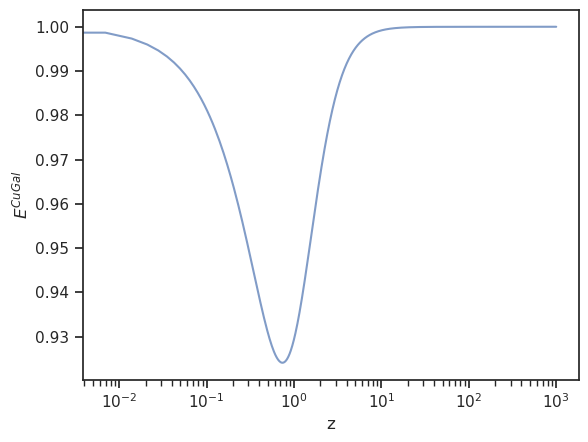

In [20]:
%time
a_test = np.linspace(0.001, 1.0, 100)
a_arr, UE_arr, coupling_factor_arr = run_Horndeski_simulation(1.0,cosmo_testing)
print(a_arr.shape)
a_testing, UE_testing, coupling_testing = CuGal_initialize(1.0, cosmo_testing)

plt.plot(1/a_arr -1,E_CuGal(a_testing, UE_testing, a_arr)/E_LCDM(cosmo_testing, a_arr), alpha=0.7)
#plt.plot(1/a_arr -1,E_CuGal(0.0, cosmo_testing, a_arr)/E_LCDM(cosmo_testing, a_arr), alpha=0.7)

plt.xscale("log")
plt.xlabel("z")
plt.ylabel(r"$E^{CuGal}$")

Text(0, 0.5, '$\\mu^{CuGal}$')

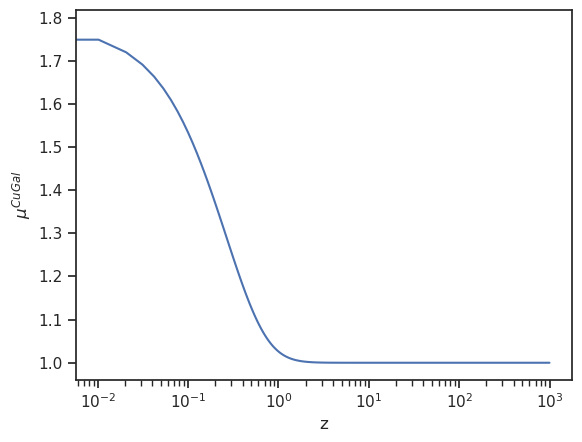

In [21]:
plt.plot(1/a_test - 1, mu_CuGal(a_testing, coupling_testing, a_test))
#plt.plot(1/a_test - 1, mu_CuGal(0.0, cosmo_testing, a_test))

plt.xscale("log")
plt.xlabel("z")
plt.ylabel(r"$\mu^{CuGal}$")

# 2. Define functions to get various (P(k)) from Emulators, etc.

In [22]:
def Get_Pk2D_obj_kk_GR_nl(cosmo):
   
    ########### Functions for linear matter power spectrum multiplied by Sigma**2 ###########        
    def pk_funcSigma2(k, a):
        return ccl.nonlin_matter_power(cosmo, k=k, a=a)

    return ccl.pk2d.Pk2D.from_function(pkfunc=pk_funcSigma2, is_logp=False)

def Get_Pk2D_obj_kk_GR_lin(cosmo):
   
    ########### Functions for linear matter power spectrum multiplied by Sigma**2 ###########        
    def pk_funcSigma2(k, a):
        return ccl.linear_matter_power(cosmo, k=k, a=a)

    return ccl.pk2d.Pk2D.from_function(pkfunc=pk_funcSigma2, is_logp=False)


The power spectrum in $\Lambda$CDM and nDGP is the same in the early universe (i.e. $\approx z=49$). This means we have:

$P_{\delta}(z=49) = \Big(\frac{\delta^{\Lambda CDM}(z=49)}{\delta^{\Lambda CDM}(z=0)}\Big)^2P^{\Lambda CDM}_{\delta}(z=0) = \Big(\frac{\delta^{nDGP}(z=49)}{\delta^{nDGP}(z=z_{ini})}\Big)^2P^{nDGP}_{\delta}(z=z_{ini})$

Therefore 

$P^{nDGP}_{\delta}(z=z_{ini}) = \Big(\frac{D_+^{\Lambda CDM}(z=49)}{D_+^{nDGP}(z=49)} \times \frac{D_+^{nDGP}(z=z_{ini})}{D_+^{\Lambda CDM}(z=z_{ini})}
\Big)^2P^{\Lambda CDM}_{\delta}(z=0)$

where $D_+(z=0) = 1$.

## Non-linear matter power spectra CuGal

In [23]:
# NL matter power spectra in fR
def P_k_NL_CuGal(GR_pk2D_obj, f_phi, cosmo, k, a):
    """
    input k (array) -> wavevector, units 1/Mpc
    input a (float or array) -> scale factor (1/(1+z))
    input cosmo (cosmology object) -> Cosmology object from CCL
    
    output Pk_fR (array) -> Nonlinear matter power spectrum for Hu-Sawicki fR gravity, units (Mpc)^3
    """
    if isinstance(a, (float, int)):  # Single scale factor case
        input_params_and_redshift = np.append(
            np.array([cosmo["Omega_m"], cosmo["n_s"], 1e9 * cosmo["A_s"], cosmo["h"], f_phi]),
            1.0 / a - 1.0
        )
        bk_target, err_target = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list,sepia_data_list, z_all)
        interp_func = scipy.interpolate.interp1d(k_all * cosmo["h"], bk_target.flatten(), kind='linear', fill_value="extrapolate")
        pkratio_CuGal = interp_func(k)
        
    else:
        bk_target = []
        z_range = 1.0 / a - 1.0  # Array of redshift values

        # Loop over each redshift value
        for z_val in z_range:
            input_params_and_redshift = np.append(
                np.array([cosmo["Omega_m"], cosmo["n_s"], 1e9 * cosmo["A_s"], cosmo["h"], f_phi]),
                z_val
            )
            bk_target_i, _ = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list,sepia_data_list, z_all)
            bk_target.append(bk_target_i.flatten()) 
    
        # Convert list to array with shape (len(a), len(k_all))
        bk_target = np.array(bk_target)

        
        # Interpolating each row in bk_target over k
        pkratio_CuGal = np.array([
            scipy.interpolate.interp1d(k_all * cosmo["h"], bk_row, kind='linear', fill_value="extrapolate")(k) 
            for bk_row in bk_target
        ])
    

    Pk_ccl = GR_pk2D_obj.__call__(k, a=a) # units (Mpc)^3
    Pk = pkratio_CuGal*Pk_ccl
    
    return Pk

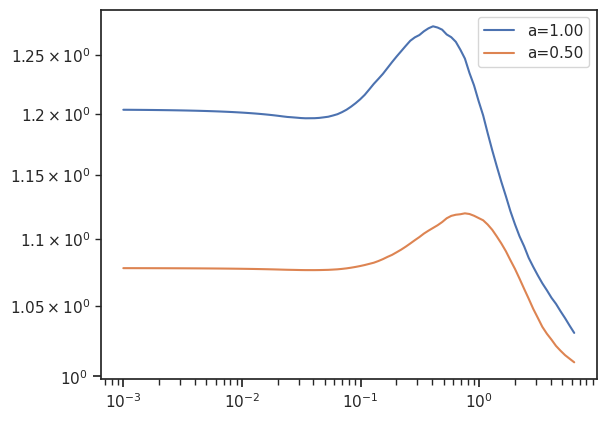

In [24]:
# Example test case

P_delta2D_GR_lin_test = Get_Pk2D_obj_kk_GR_lin(cosmo_testing)
P_delta2D_GR_nl_test = Get_Pk2D_obj_kk_GR_nl(cosmo_testing)

a_test = np.linspace(1, 0.5, 2)
k_test = np.logspace(-3,0.8,100)
PkTest_new = P_k_NL_CuGal(P_delta2D_GR_nl_test,1.0, cosmo_testing, k_test, a_test)
for i in range(len(a_test)):
    plt.loglog(k_test, PkTest_new[i]/ccl.power.nonlin_power(cosmo_testing, k_test, a=a_test[i]), label=f"a={a_test[i]:.2f}")
plt.legend()
plt.show()

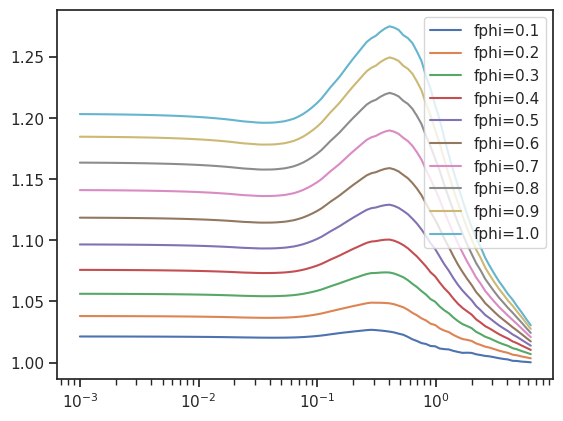

In [25]:
# Example test case

P_delta2D_GR_lin_test = Get_Pk2D_obj_kk_GR_lin(cosmo_testing)
P_delta2D_GR_nl_test = Get_Pk2D_obj_kk_GR_nl(cosmo_testing)

a_test = 1
k_test = np.logspace(-3,0.8,100)
f_phi_range = np.linspace(0.1,1.0,10)
for i in range(len(f_phi_range)):
    PkTest_new = P_k_NL_CuGal(P_delta2D_GR_nl_test,f_phi_range[i], cosmo_testing, k_test, a_test)

    plt.semilogx(k_test, PkTest_new/ccl.power.nonlin_power(cosmo_testing, k_test, a=a_test), label=f"fphi={f_phi_range[i]:.1f}")
plt.legend()
plt.show()

## Linear matter power spectra CuGal

In [26]:
"""Linear matter power spectra CuGal"""

def P_k_CuGal_lin(GR_pk2D_obj,f_phi, cosmo, k, a):
    """
    input k (array) -> wavevector, units 1/Mpc
    input a (float) -> scale factor (1/(1+z))
    input cosmo (cosmology object) -> Cosmology object from CCL
    
    output Pk_fR (array) -> Nonlinear matter power spectrum for Hu-Sawicki fR gravity, units (Mpc)^3
    """

    input_params_and_redshift = np.append(np.array([cosmo["Omega_m"],cosmo["n_s"],1e9*cosmo["A_s"],cosmo["h"],f_phi]) , 1.0/a -1.0)     
    bk_target, err_target = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list,sepia_data_list, z_all)
    
    pkratio_CuGal = bk_target[0]

    Pk_ccl = GR_pk2D_obj.__call__(k, a=a) # units (Mpc)^3
    Pk = pkratio_CuGal*Pk_ccl

    return Pk

In [27]:
# use mu(a) to get linear matter power spectrum in CuGal, and compare with emulator - should be the same


def solverGrowth_CG(y,a,cosmoMCMCStep, a_testing, UE_testing, coupling_testing):
    D , a3EdDda = y

    mu = mu_CuGal(a_testing, coupling_testing, a)
    E_val = E_CuGal(a_testing, UE_testing, a)
    
    ydot = [a3EdDda / (E_val*a**3), 3*cosmoMCMCStep["Omega_m"]*D*(mu)/(2*E_val*a**2)]
    return ydot

def solverGrowth_D2_CG(y,a,cosmoMCMCStep, a_testing, UE_testing, coupling_testing, D1_solver, a_solver):
    D2 , a3EdDda = y

    mu = mu_CuGal(a_testing, coupling_testing, a)
    E_val = E_CuGal(a_testing, UE_testing, a)
    D1 = np.interp(a, a_solver, D1_solver)
    
    ydot = [a3EdDda / (E_val*a**3), 3*cosmoMCMCStep["Omega_m"]*(D2 - D1)*(mu)/(2*E_val*a**2)]
    return ydot


def solverGrowth_D2_GR(y,a,cosmoMCMCStep, D1_solver, a_solver):
    D2 , a3EdDda = y

    mu = 1
    E_val = E_LCDM(cosmoMCMCStep, a)
    D1 = np.interp(a, a_solver, D1_solver)
    
    ydot = [a3EdDda / (E_val*a**3), 3*cosmoMCMCStep["Omega_m"]*(D2 - D1)*(mu)/(2*E_val*a**2)]
    return ydot

def solverGrowth_Geffonly(y,a,cosmoMCMCStep, a_testing, UE_testing, coupling_testing):
    D , a3EdDda = y

    mu = mu_CuGal(a_testing, coupling_testing, a)
    E_val = E_LCDM(cosmoMCMCStep, a)
    
    ydot = [a3EdDda / (E_val*a**3), 3*cosmoMCMCStep["Omega_m"]*D*(mu)/(2*E_val*a**2)]
    return ydot

def solverGrowth_QCDM(y,a,cosmoMCMCStep, a_testing, UE_testing, coupling_testing):
    D , a3EdDda = y

    mu = 1
    E_val = E_CuGal(a_testing, UE_testing, a)
    
    ydot = [a3EdDda / (E_val*a**3), 3*cosmoMCMCStep["Omega_m"]*D*(mu)/(2*E_val*a**2)]
    return ydot

def solverGrowth_GR(y,a,cosmoMCMCStep):
    E_val = E_LCDM(cosmoMCMCStep, a)
    D , a3EdDda = y

    
    ydot = [a3EdDda / (E_val*a**3), 3*cosmoMCMCStep["Omega_m"]*D/(2*E_val*a**2)]
    return ydot

def P_k_CuGal_lin_QCDM(GR_pk2D_obj, f_phi,cosmoMCMCStep, k, a):
    
    """
    input k (array) -> wavevector, units 1/Mpc
    input a (float) -> scale factor (1/(1+z))
    input cosmo (cosmology object) -> Cosmology object from CCL
    input f_phi (float) -> coupling parameter
    
    output P_k_CuGal (array) -> linear matter power spectrum for CuGal model, units (Mpc)^3
    """
        
    # Get growth factor in nDGP and GR
    a_solver = np.linspace(1/500,1,1000)
    # initialize QCDM
    a_arr, UE_arr, coupling_arr = CuGal_initialize(f_phi, cosmoMCMCStep)
    E_CG_ini = E_CuGal(a_arr, UE_arr, a_solver[0])
    Soln = odeint(solverGrowth_QCDM, [a_solver[0], (E_CG_ini*a_solver[0]**3)], a_solver, \
                  args=(cosmoMCMCStep,a_arr, UE_arr, coupling_arr), mxstep=int(1e4))
    
    Delta = Soln.T[0]
    Soln = odeint(solverGrowth_GR, [a_solver[0], (E_LCDM(cosmoMCMCStep, a_solver[0])*a_solver[0]**3)], a_solver,\
                  args=(cosmoMCMCStep,), mxstep=int(1e4))
    
    Delta_GR = Soln.T[0]

    # Get Pk linear in GR
    Pk_GR = GR_pk2D_obj.__call__(k, a)

    # find the index for matter domination)
    idx_mdom = 0         
    # get normalization at matter domination
    Delta_49 = Delta[idx_mdom]
    Delta_GR_49 = Delta_GR[idx_mdom]
    plt.plot(1/a_solver - 1, Delta/(Delta_GR), label='QCDM')
    print((Delta/(Delta_GR))[np.argmin(np.abs(a_solver-1/50))])
    plt.xscale("log")
    plt.xlabel("z")
    plt.xlim(2e-3, 10)
    plt.ylabel(r"$\Delta/\Delta_{LCDM}$")
    
    return Pk_GR * np.interp(a, a_solver, (Delta / Delta_49) **2 / (Delta_GR / Delta_GR_49)**2)  # units (Mpc)^3

def P_k_CuGal_lin_Geffonly(GR_pk2D_obj, f_phi,cosmoMCMCStep, k, a):
    
    """
    input k (array) -> wavevector, units 1/Mpc
    input a (float) -> scale factor (1/(1+z))
    input cosmo (cosmology object) -> Cosmology object from CCL
    input f_phi (float) -> coupling parameter
    
    output P_k_CuGal (array) -> linear matter power spectrum for CuGal model, units (Mpc)^3
    """
        
    # Get growth factor in nDGP and GR
    a_solver = np.linspace(1/500,1,1000)
    # initialize QCDM
    a_arr, UE_arr, coupling_arr = CuGal_initialize(f_phi, cosmoMCMCStep)
    Soln = odeint(solverGrowth_Geffonly, [a_solver[0], (E_LCDM(cosmoMCMCStep, a_solver[0])*a_solver[0]**3)], a_solver, \
                  args=(cosmoMCMCStep,a_arr, UE_arr, coupling_arr), mxstep=int(1e4))
    
    Delta = Soln.T[0]
    Soln = odeint(solverGrowth_GR, [a_solver[0], (E_LCDM(cosmoMCMCStep, a_solver[0])*a_solver[0]**3)], a_solver,\
                  args=(cosmoMCMCStep,), mxstep=int(1e4))
    
    Delta_GR = Soln.T[0]

    # Get Pk linear in GR
    Pk_GR = GR_pk2D_obj.__call__(k, a)

    # find the index for matter domination)
    idx_mdom = 0         
    # get normalization at matter domination
    Delta_49 = Delta[idx_mdom]
    Delta_GR_49 = Delta_GR[idx_mdom]
    plt.plot(1/a_solver - 1, Delta/(Delta_GR), label='Geff only')
    print((Delta/(Delta_GR))[np.argmin(np.abs(a_solver-1/50))])
    plt.xscale("log")
    plt.xlabel("z")
    plt.xlim(2e-3, 10)
    plt.ylabel(r"$\Delta/\Delta_{LCDM}$")
    
    return Pk_GR * np.interp(a, a_solver, (Delta / Delta_49) **2 / (Delta_GR / Delta_GR_49)**2)  # units (Mpc)^3

def P_k_CuGal_lin_CG(GR_pk2D_obj, f_phi,cosmoMCMCStep, k, a):
    
    """
    input k (array) -> wavevector, units 1/Mpc
    input a (float) -> scale factor (1/(1+z))
    input cosmo (cosmology object) -> Cosmology object from CCL
    input f_phi (float) -> coupling parameter
    
    output P_k_CuGal (array) -> linear matter power spectrum for CuGal model, units (Mpc)^3
    """
        
    # Get growth factor in CG and GR
    a_solver = np.linspace(1/500,1,1000)
    # initialize CG
    a_arr, UE_arr, coupling_arr = CuGal_initialize(f_phi, cosmoMCMCStep)
    E_CG_ini = E_CuGal(a_arr, UE_arr, a_solver[0])
    Soln = odeint(solverGrowth_CG, [a_solver[0], (E_CG_ini*a_solver[0]**3)], a_solver, \
                  args=(cosmoMCMCStep,a_arr, UE_arr, coupling_arr), mxstep=int(1e4))
    
    Delta = Soln.T[0]

    Soln_2ndorder = odeint(solverGrowth_D2_CG, [-3./7.*a_solver[0], -6./7.*(E_CG_ini*a_solver[0]**3)], a_solver, \
                  args=(cosmoMCMCStep,a_arr, UE_arr, coupling_arr, Delta, a_solver), mxstep=int(1e4))
    
    Delta2 = Soln_2ndorder.T[0]

    Soln = odeint(solverGrowth_GR, [a_solver[0], (E_LCDM(cosmoMCMCStep, a_solver[0])*a_solver[0]**3)], a_solver,\
                  args=(cosmoMCMCStep,), mxstep=int(1e4))

    Soln_2ndorder_GR = odeint(solverGrowth_D2_GR, [-3./7.*a_solver[0], -6./7.*(E_LCDM(cosmoMCMCStep, a_solver[0])*a_solver[0]**3)], a_solver, \
                  args=(cosmoMCMCStep, Delta, a_solver), mxstep=int(1e4))
    
    Delta2_GR = Soln_2ndorder_GR.T[0]
    
    Delta_GR = Soln.T[0]

    # Get Pk linear in GR
    Pk_GR = GR_pk2D_obj.__call__(k, a)

    # find the index for matter domination)
    idx_mdom = 0#np.argmax(a_solver**(-3) / E_LCDM(cosmoMCMCStep, a_solver)**2)
    
    # get normalization at matter domination
    Delta_49 = Delta[idx_mdom]
    Delta_GR_49 = Delta_GR[idx_mdom]

    # plot the growth relative to the LCDM growth divided by Delta_49, to check that they are the same at early times
    plt.plot(1/a_solver - 1, Delta/(Delta_GR), label='CuGal')
    plt.plot(1/a_solver - 1, (Delta2+Delta)/(Delta_GR+Delta2_GR), label='CuGal 2nd order')
    print((Delta/(Delta_GR))[np.argmin(np.abs(a_solver-1/50))])
    plt.xscale("log")
    plt.xlabel("z")
    plt.xlim(2e-3, 10)
    plt.ylabel(r"$\Delta/\Delta_{LCDM}$")
    plt.legend()
    return Pk_GR * np.interp(a, a_solver, (Delta / Delta_49) **2 / (Delta_GR / Delta_GR_49)**2)  # units (Mpc)^3



## sigma_8 and f for CuGal

In [28]:
def sigma_8_CuGal(GR_pk2D_obj,f_phi, cosmo, a_array):
    k_val = np.logspace(-4, 3, 3000)
    sigma_8_vals = []

    for a in a_array:
        P_k_vals = P_k_CuGal_lin(GR_pk2D_obj,f_phi, cosmo, k_val, a)
        j1_vals = 3 * scipy.special.spherical_jn(1, k_val * 8 / cosmo["h"], derivative=False) / (k_val * 8 / cosmo["h"])
        integrand = k_val**2 * P_k_vals * j1_vals**2
        integral_val = scipy.integrate.trapz(integrand, x=k_val)
        sigma_8_val = np.sqrt(integral_val / (2 * np.pi**2))
        sigma_8_vals.append(sigma_8_val)
    
    return np.array(sigma_8_vals)

def solverGrowth_CuGal(y,a,a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo):
    E_val = E_CuGal(a_arr, UE_arr, a)
    D , a3EdDda = y
    
    mu = mu_CuGal(a_arr, coupling_factor_arr, a)
    
    ydot = [a3EdDda / (E_val*a**3), 3*cosmo["Omega_m"]*D*(mu)/(2*E_val*a**2)]
    return ydot
    
def fsigma8_CuGal(GR_pk2D_obj,a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo, a):
    
    """
    input k (array) -> wavevector, units 1/Mpc
    input a (float) -> scale factor (1/(1+z))
    input cosmo (cosmology object) -> Cosmology object from CCL
    """
    
    
    a_solver = np.linspace(1/50,1,100)
    Soln = odeint(solverGrowth_CuGal, [a_solver[0], (E_CuGal(a_arr, UE_arr, a_solver[0])*a_solver[0]**3)], a_solver, \
                  args=(a_arr, UE_arr, coupling_factor_arr,f_phi, cosmo), mxstep=int(1e4))
    
    Delta = Soln.T[0]
    a3EdDda = Soln.T[1]

    f_CuGal_interp = a3EdDda/a_solver**2 / Delta / E_CuGal(a_arr, UE_arr, a_solver)
    
    f_CuGal = np.interp(a, a_solver, f_CuGal_interp)

    return f_CuGal * sigma_8_CuGal(GR_pk2D_obj,f_phi,cosmo, a)

def growthfactor_CuGal(a_arr, UE_arr, coupling_factor_arr,f_phi, cosmo, a):
        
    a_solver = np.linspace(1/50,1,100)
    Soln = odeint(solverGrowth_CuGal, [a_solver[0], (E_CuGal(a_arr, UE_arr, a_solver[0])*a_solver[0]**3)], a_solver, \
                  args=(a_arr, UE_arr, coupling_factor_arr,f_phi, cosmo), mxstep=int(1e4))
    
    Delta = Soln.T[0]
    return np.interp(a,a_solver,Delta/Delta[-1])

def growthrate_CuGal(a_arr, UE_arr, coupling_factor_arr,f_phi, cosmo, a):
        
    a_solver = np.linspace(1/50,1,100)
    Soln = odeint(solverGrowth_CuGal, [a_solver[0], (E_CuGal(a_arr, UE_arr, a_solver[0])*a_solver[0]**3)], a_solver, \
                  args=(a_arr, UE_arr, coupling_factor_arr,f_phi, cosmo), mxstep=int(1e4))
    
    Delta = Soln.T[0]
    a3EdDda = Soln.T[1]

    f_CuGal_interp = a3EdDda/a_solver**2 / Delta / E_CuGal(a_arr, UE_arr, a_solver)
    
    f_CuGal = np.interp(a, a_solver, f_CuGal_interp)

    return f_CuGal

## 2.a. Test functions for P(k)

### Cubic Galileon

1.0000451228850797
1.0000435835397743
1.000017625015345


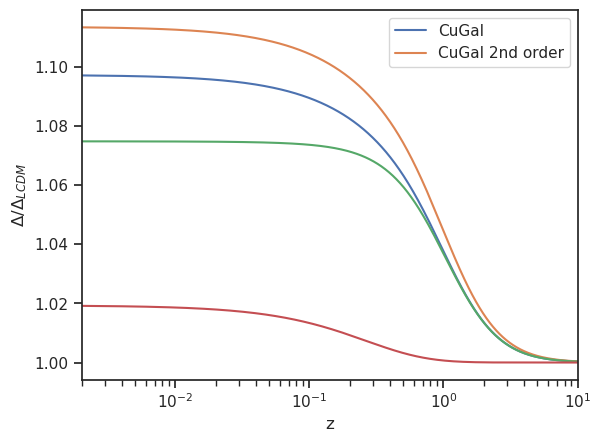

In [29]:
cosmo_testing = ccl.Cosmology(Omega_c = (0.1417493400784 - 0.0223)/0.67**2,
                           Omega_b =  0.0223/0.67**2,
                           h = 0.67,
                           n_s = 0.9665,
                           A_s = 2.01e-9,
                           Omega_g = 0)

k_test = np.logspace(-3, 0, 100)
P_delta2D_GR_lin_test = Get_Pk2D_obj_kk_GR_lin(cosmo_testing)
pk_GR_test = ccl.nonlin_matter_power(cosmo_testing, k=k_test, a=1/50)
pk_GR_test_lin = P_delta2D_GR_lin_test.__call__(k_test, 1/50)

#pk_test = P_k_NL_CuGal(P_delta2D_GR_nl_test,1.0,cosmo_testing, k_test, 1/50)

#pk_test_lin = P_k_CuGal_lin(P_delta2D_GR_lin_test,1.0,cosmo_testing, k_test, 1/50)
#pk_test_lin_v2 = P_k_CuGal_lin_v2(P_delta2D_GR_lin_test,1.0,cosmo_testing, k_test, 1/50)
pk_test_lin_CG = P_k_CuGal_lin_CG(P_delta2D_GR_lin_test,1.0,cosmo_testing, k_test, 1/50)
pk_test_lin_QCDM = P_k_CuGal_lin_QCDM(P_delta2D_GR_lin_test,1.0,cosmo_testing, k_test, 1/50)
pk_test_lin_Geffonly = P_k_CuGal_lin_Geffonly(P_delta2D_GR_lin_test,1.0,cosmo_testing, k_test, 1/50)

In [30]:
#plt.loglog(k_test, pk_test, 1)
#plt.loglog(k_test, pk_test_lin, 1)
plt.loglog(k_test, pk_test_lin_v2, color="blue", label="v2")
plt.loglog(k_test, pk_test_lin_v3, color="magenta", label="v3", linestyle="dotted") # dotted
plt.loglog(k_test,pk_GR_test_lin, "k--", alpha=0.6)
plt.loglog(k_test,pk_GR_test, "k--", alpha=0.6)
plt.legend()

NameError: name 'pk_test_lin_v2' is not defined

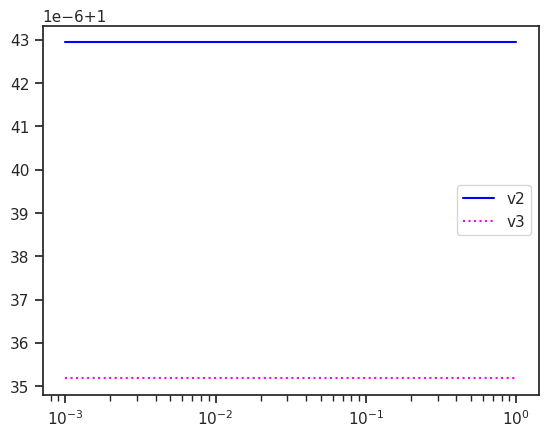

In [ ]:
#plt.semilogx(k_test, pk_test_lin/pk_GR_test_lin, color="orange", label="v1")
plt.semilogx(k_test, pk_test_lin_v2/pk_GR_test_lin, color="blue", label="v2")
plt.semilogx(k_test, pk_test_lin_v3/pk_GR_test_lin, color="magenta", label="v3", linestyle="dotted")
#plt.semilogx(k_test,pk_GR_test_lin/pk_GR_test_lin, "k--", alpha=0.6)
plt.legend()

## 2.b. Test functions for fsigma8

In [ ]:
z_testing = np.linspace(0, 10, 100)

a_testing, UE_testing, coupling_testing = CuGal_initialize(1.0, cosmo_testing)

plt.plot(z_testing, fsigma8_CuGal(P_delta2D_GR_lin_test, a_testing, UE_testing, coupling_testing,1.0, cosmo_testing, 1/(z_testing+1)))
a_testing, UE_testing, coupling_testing = CuGal_initialize(0.0, cosmo_testing)
plt.plot(z_testing, fsigma8_CuGal(P_delta2D_GR_lin_test,a_testing, UE_testing, coupling_testing,0.0, cosmo_testing, 1/(z_testing+1)), "purple")

#sigma_8_vals = np.zeros(len(z_testing))
#for i in range(len(z_testing)):
#    sigma_8_vals[i] = ccl.power.sigmaR(cosmo_testing, 8/cosmo_testing["h"], a=1/(z_testing[i]+1))

#plt.plot(z_testing, ccl.background.growth_rate(cosmo_testing, 1/(z_testing+1))*sigma_8_vals, "k--") 

# 3. Getting C(ell) functions

In [ ]:
"""Get n_zbins logarithmically spaced ell bins (total n of ell bins = ell_bin_num)"""
def bin_ell_kk(ell_min, ell_max, ell_bin_num, Binned_distribution):
    # define quantities for binning in ell
    n_zbins = int(((len(Binned_distribution)+1)*len(Binned_distribution))/2)
    ell_binned_limits = np.linspace(np.log10(ell_min),np.log10(ell_max),num=ell_bin_num + 1)
    bin_edge1 = ell_binned_limits[:-1]
    bin_edge2 = ell_binned_limits[1:]
    ell_binned = 10**((bin_edge1 + bin_edge2) / 2)
Paper draft
    # Repeat ell_binned over all redshift bins, so that len(ell_binned)=len(C_ell_array)
    ell_binned = np.repeat([ell_binned], repeats=n_zbins, axis=0)
    
    #ell_binned = list(islice(cycle(ell_binned), int(ell_bin_num*((len(Binned_distribution)+1)*len(Binned_distribution))/2)))
    return ell_binned
    
"""Get n_zbins logarithmically spaced ell bins (total n of ell bins = ell_bin_num)"""
def bin_ell_delk(ell_min, ell_max, ell_bin_num,Binned_distribution_s, Binned_distribution_l):
    # define quantities for binning in ell
    n_zbins = 0
    for j in range(len(Binned_distribution_l)):
        for k in range(len(Binned_distribution_s)):
            if k - 1 > j or (k == 4 and j == 3):
                n_zbins += 1
    
    ell_binned_limits = np.linspace(np.log10(ell_min),np.log10(ell_max),num=ell_bin_num + 1)
    bin_edge1 = ell_binned_limits[:-1]
    bin_edge2 = ell_binned_limits[1:]
    ell_binned = 10**((bin_edge1 + bin_edge2) / 2)

    # Repeat ell_binned over all redshift bins, so that len(ell_binned)=len(C_ell_array)
    ell_binned = np.repeat([ell_binned], repeats=n_zbins, axis=0)
    
    #ell_binned = list(islice(cycle(ell_binned), int(ell_bin_num*((len(Binned_distribution)+1)*len(Binned_distribution))/2)))
    return ell_binned

"""Get n_zbins logarithmically spaced ell bins (total n of ell bins = ell_bin_num)"""
def bin_ell_deldel(ell_min, ell_max, ell_bin_num, Binned_distribution):
    # define quantities for binning in ell
    n_zbins = len(Binned_distribution)
    ell_binned_limits = np.linspace(np.log10(ell_min),np.log10(ell_max),num=ell_bin_num + 1)
    bin_edge1 = ell_binned_limits[:-1]
    bin_edge2 = ell_binned_limits[1:]
    ell_binned = 10**((bin_edge1 + bin_edge2) / 2)

    # Repeat ell_binned over all redshift bins, so that len(ell_binned)=len(C_ell_array)
    ell_binned = np.repeat([ell_binned], repeats=n_zbins, axis=0)
    
    #ell_binned = list(islice(cycle(ell_binned), int(ell_bin_num*((len(Binned_distribution)+1)*len(Binned_distribution))/2)))
    return ell_binned

def bins(ell_min, ell_max, ell_bin_num):

    # define quantities for binning in ell
    ell_binned_limits = np.linspace(np.log10(ell_min),np.log10(ell_max),num=ell_bin_num + 1)
    bin_edge1 = ell_binned_limits[:-1]
    bin_edge2 = ell_binned_limits[1:]
    ell_binned = 10**((bin_edge1 + bin_edge2) / 2)
    # Repeat ell_binned over all redshift bins, so that len(ell_binned)=len(C_ell_array)
    return ell_binned

## Cell for GR

In [36]:
"""Functions to find Cell given a Pdelta_2D ccl object  - GR"""

# A: Function for cosmic shear angular power spectrum (lensing-lensing C_ell) from a given P_delta2D_S
def C_ell_arr_kk_GR(ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution):
    C_ell_array = []
    n_zbins = int(((len(Binned_distribution_s)+1)*len(Binned_distribution_s))/2)
    # how far along z binning we are
    idx = 0
    # at what z bin we start calculating Cell
    start_idx = n_zbins - len(ell_binned)

    for j in range(len(Binned_distribution_s)):
        tracer1 = ccl.WeakLensingTracer(cosmo, dndz=(z, Binned_distribution_s[j]))
        for k in range(len(Binned_distribution_s)):
            if k >= j:
                if start_idx <= idx:
                    tracer2 = ccl.WeakLensingTracer(cosmo, dndz=(z, Binned_distribution_s[k]))
                    C_ell = ccl.angular_cl(cosmo, tracer1, tracer2, ell_binned[idx - start_idx])
                    C_ell_array.append([C_ell])
                    idx += 1
                else:
                    idx += 1
    return C_ell_array

# B: Function for galaxy-galaxy lensing angular power spectrum (clustering-lensing C_ell) from a given P_delta2D_S
def C_ell_arr_delk_GR(ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution):
    C_ell_array = []
    
    n_zbins = 0
    for j in range(len(Binned_distribution_l)):
        for k in range(len(Binned_distribution_s)):
            if k - 1 > j or (k == 4 and j == 3):
                n_zbins += 1
                
    # how far along z binning we are
    idx = 0
    # at what z bin we start calculating Cell
    start_idx = n_zbins - len(ell_binned)

    for j in range(len(Binned_distribution_l)):
        tracer1 = ccl.NumberCountsTracer(cosmo, dndz=(z, Binned_distribution_l[j]), bias=(z, Bias_distribution[j]), has_rsd=False)
        for k in range(len(Binned_distribution_s)):
            if k - 1 > j or (k == 4 and j == 3):
                if start_idx <= idx:
                    tracer2 = ccl.WeakLensingTracer(cosmo, dndz=(z, Binned_distribution_s[k]))
                    C_ell = ccl.angular_cl(cosmo, tracer1, tracer2, ell_binned[idx - start_idx])
                    C_ell_array.append([C_ell])
                    idx += 1
                else:
                    idx += 1
    return C_ell_array

# C: Function for galaxy-galaxy clustering angular power spectrum (clustering-clustering C_ell) from a given P_delta2D_S
def C_ell_arr_deldel_GR(ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution):
    C_ell_array = []
    n_zbins = len(Binned_distribution_l)
    # how far along z binning we are
    idx = 0
    # at what z bin we start calculating Cell
    start_idx = n_zbins - len(ell_binned)

    for j in range(len(Binned_distribution_l)):
        tracer1 = ccl.NumberCountsTracer(cosmo, dndz=(z, Binned_distribution_l[j]), bias=(z, Bias_distribution[j]), has_rsd=False)
        for k in range(len(Binned_distribution_l)):
            if k == j:
                if start_idx <= idx:
                    tracer2 = ccl.NumberCountsTracer(cosmo, dndz=(z, Binned_distribution_l[k]), bias=(z, Bias_distribution[k]), has_rsd=False)
                    C_ell = ccl.angular_cl(cosmo, tracer1, tracer2, ell_binned[idx - start_idx])
                    C_ell_array.append([C_ell])
                    idx += 1
                else:
                    idx += 1
    return C_ell_array

## Find Cell for Cubic Galileon

In [37]:
"""Functions to find Cell for Cubic Galileon given a Pdelta_2D ccl object"""


"""Comoving radial distance in Cubic Galileon"""
def comoving_radial_dist_CuGal(a_arr, UE_arr, cosmo, a_array):
    c = 3e5  # Speed of light in km/s
    
    # Define the redshift integral range
    #z_integral = np.linspace(1/a_array.min() - 1, 0, int(1e4))  # Use the minimum value of `a_array`
    x_integral = np.linspace(np.log(a_array.min()), 0, int(2e2)) # Compute the scale factor over the range
    a_integral = np.exp(x_integral)
    z_integral = 1/a_integral - 1
    
    # Calculate E(a_integral) only once over the entire range
    E_val = E_CuGal(a_arr, UE_arr, a_integral)

    # Define the integrand for each value of a
    integrand = c / (a_integral * E_val * cosmo["H0"])
    
    # Now integrate over the entire range for each value in `a_array`
    results = []
    for a_iter in a_array:
        z_lower_bound = 1/a_iter - 1  # Adjust the upper bound of the integration
        mask = (z_integral <= z_lower_bound)  # Mask the integrand for the valid integration range
        
        # Perform integration for the valid portion of the integrand
        integral = scipy.integrate.simps(integrand[mask], x_integral[mask])
        results.append(integral)

    return np.array(results)

In [38]:
def Cell_CuGal(ell_binned, a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo_GR, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution,
         GR_pk2D_obj, tracer1_type="k", 
         tracer2_type="k"):
    # Define the scale factor array
    a_array = np.logspace(np.log10(1/14), 0, 50)
    
    # Compute chi using the comoving radial distance function
    chi_array = comoving_radial_dist_CuGal(a_arr, UE_arr, cosmo_GR, a_array)
    
    # Compute h_over_h0 using the Hubble expansion rate function
    h_over_h0_array = E_CuGal(a_arr, UE_arr, a_array)
    
    # Create the background dictionary
    background_dict = {
        'a': a_array,
        'chi': chi_array,
        'h_over_h0': h_over_h0_array
    }

    growthfact_array = growthfactor_CuGal(a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo_GR, a_array)
    growthrate_array = growthrate_CuGal(a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo_GR, a_array)
    
    # Create the growth dictionary
    growth_dict = {
        'a': a_array,
        'growth_factor': growthfact_array,
        'growth_rate': growthrate_array
    }
    k_array = np.logspace(-4,3,100)

    """
    # Split a_array based on the condition a < 1/12
    a_threshold = 1/12
    a_GR = a_array[a_array < a_threshold]
    a_MG = a_array[a_array >= a_threshold]

    # Compute P(k, a) for a < 1/12 using P_k_GR
    Pk_GR_array = np.array([ccl.power.nonlin_power(cosmo_GR, k_array, a) for a in a_GR])
    """
    # Compute P(k, a) for a >= 1/12 using P_k_NL_CuGal
    Pk_NL_array = P_k_NL_CuGal(GR_pk2D_obj,f_phi,cosmo_GR, k_array, a_array) #np.array([P_k_NL_CuGal(f_phi,cosmo_GR, k_array, a) for a in a_array])

    # Combine the results back into a single array
    #Pk_NL_array = np.vstack((Pk_GR_array, Pk_NL_CuGal_array))

    Pk_NL_dict = {
        'a': a_array,
        'k': k_array,
        'delta_matter:delta_matter': Pk_NL_array,
    }
    
    cosmo = ccl.cosmology.CosmologyCalculator(Omega_c = cosmo_GR["Omega_c"],
                                              Omega_b = cosmo_GR["Omega_b"],
                                              h = cosmo_GR["h"],
                                              n_s = cosmo_GR["n_s"],
                                              A_s = cosmo_GR["A_s"],
                                              background = background_dict,
                                              growth = growth_dict,
                                              pk_nonlin = Pk_NL_dict)
    
    ops = {
        ("k" , "k"): C_ell_arr_kk_GR,
        ("k" , "g"): C_ell_arr_delk_GR, 
        ("g" , "k"): C_ell_arr_delk_GR,
        ("g" , "g"): C_ell_arr_deldel_GR
    }

    def invalid_op2():
        raise ValueError('invalid tracer selected.')
    ########## Find Cell ##########

    C_ell_array_funct = ops.get((tracer1_type, tracer2_type), invalid_op2)
    C_ell_array = C_ell_array_funct(ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution)

    return np.array(list(itertools.chain(*ell_binned))), C_ell_array

In [39]:
def Cell_CuGal(ell_binned, a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo_GR, z, 
               Binned_distribution_s, Binned_distribution_l, Bias_distribution,
               GR_pk2D_obj, tracer1_type="k", tracer2_type="k"):
    # Define the scale factor array
    a_array = np.logspace(np.log10(1/14), 0, 50)
    
    # Compute chi using the comoving radial distance function
    chi_array = comoving_radial_dist_CuGal(a_arr, UE_arr, cosmo_GR, a_array)
    
    # Compute h_over_h0 using the Hubble expansion rate function
    h_over_h0_array = E_CuGal(a_arr, UE_arr, a_array)
    
    # Create the background dictionary
    background_dict = {
        'a': a_array,
        'chi': chi_array,
        'h_over_h0': h_over_h0_array
    }

    growthfact_array = growthfactor_CuGal(a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo_GR, a_array)
    growthrate_array = growthrate_CuGal(a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo_GR, a_array)
    
    # Create the growth dictionary
    growth_dict = {
        'a': a_array,
        'growth_factor': growthfact_array,
        'growth_rate': growthrate_array
    }

    k_array = np.logspace(-4, 3, 100)
    
    # Compute P(k, a) separately for different tracer combinations
    mu_cugal_val = np.repeat(mu_CuGal(a_arr, coupling_factor_arr, a_array)[:, np.newaxis], 100, axis=1)
    Pk_NL_kk = mu_cugal_val**2 * P_k_NL_CuGal(GR_pk2D_obj,f_phi,cosmo_GR, k_array, a_array)
    Pk_NL_kg = mu_cugal_val * P_k_NL_CuGal(GR_pk2D_obj,f_phi,cosmo_GR, k_array, a_array)
    Pk_NL_gg = P_k_NL_CuGal(GR_pk2D_obj,f_phi,cosmo_GR, k_array, a_array)

    # Dictionary to store the correct P(k, a) choice
    Pk_NL_dict_map = {
        ("k", "k"): Pk_NL_kk,
        ("k", "g"): Pk_NL_kg,
        ("g", "k"): Pk_NL_kg,
        ("g", "g"): Pk_NL_gg
    }

    # Select the correct Pk_NL array
    Pk_NL_selected = Pk_NL_dict_map.get((tracer1_type, tracer2_type))
    if Pk_NL_selected is None:
        raise ValueError(f"Invalid tracer combination: ({tracer1_type}, {tracer2_type})")

    Pk_NL_dict = {
        'a': a_array,
        'k': k_array,
        'delta_matter:delta_matter': Pk_NL_selected,
    }
    
    # Create the cosmology object
    cosmo = ccl.cosmology.CosmologyCalculator(
        Omega_c=cosmo_GR["Omega_c"],
        Omega_b=cosmo_GR["Omega_b"],
        h=cosmo_GR["h"],
        n_s=cosmo_GR["n_s"],
        A_s=cosmo_GR["A_s"],
        background=background_dict,
        growth=growth_dict,
        pk_nonlin=Pk_NL_dict
    )
    
    # Mapping of tracer combinations to their respective power spectra
    ops = {
        ("k", "k"): C_ell_arr_kk_GR,
        ("k", "g"): C_ell_arr_delk_GR, 
        ("g", "k"): C_ell_arr_delk_GR,
        ("g", "g"): C_ell_arr_deldel_GR
    }

    def invalid_op2():
        raise ValueError('Invalid tracer selection.')

    ########## Compute C_ell ##########

    C_ell_array_funct = ops.get((tracer1_type, tracer2_type), invalid_op2)
    C_ell_array = C_ell_array_funct(ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l, Bias_distribution)

    return np.array(list(itertools.chain(*ell_binned))), C_ell_array


In [40]:
def Cell_CuGal_Validation(ell_binned, a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo_GR, z, 
               Binned_distribution_s, Binned_distribution_l, Bias_distribution,
               GR_pk2D_obj, tracer1_type="k", tracer2_type="k"):
    # Define the scale factor array
    a_array = np.logspace(np.log10(1/14), 0, 50)
    
    # Compute chi using the comoving radial distance function
    chi_array = comoving_radial_dist_CuGal(a_arr, UE_arr, cosmo_GR, a_array)
    
    # Compute h_over_h0 using the Hubble expansion rate function
    h_over_h0_array = E_CuGal(a_arr, UE_arr, a_array)
    
    # Create the background dictionary
    background_dict = {
        'a': a_array,
        'chi': chi_array,
        'h_over_h0': h_over_h0_array
    }

    growthfact_array = growthfactor_CuGal(a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo_GR, a_array)
    growthrate_array = growthrate_CuGal(a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo_GR, a_array)
    
    # Create the growth dictionary
    growth_dict = {
        'a': a_array,
        'growth_factor': growthfact_array,
        'growth_rate': growthrate_array
    }

    k_array = np.logspace(-4, 3, 100)

    Pk_ccl = GR_pk2D_obj.__call__(k_array, a=a_array)

    # Compute P(k, a) separately for different tracer combinations
    mu_cugal_val = np.repeat(mu_CuGal(a_arr, coupling_factor_arr, a_array)[:, np.newaxis], 100, axis=1)
    Pk_NL_kk = mu_cugal_val**2 * Pk_CuGal_cosmo_funct_ECOSMOG(a_array, k_array)
    Pk_NL_kg = mu_cugal_val * Pk_CuGal_cosmo_funct_ECOSMOG(a_array, k_array)
    Pk_NL_gg = Pk_CuGal_cosmo_funct_ECOSMOG(a_array, k_array)

    # Dictionary to store the correct P(k, a) choice
    Pk_NL_dict_map = {
        ("k", "k"): Pk_NL_kk,
        ("k", "g"): Pk_NL_kg,
        ("g", "k"): Pk_NL_kg,
        ("g", "g"): Pk_NL_gg
    }

    # Select the correct Pk_NL array
    Pk_NL_selected = Pk_NL_dict_map.get((tracer1_type, tracer2_type))
    if Pk_NL_selected is None:
        raise ValueError(f"Invalid tracer combination: ({tracer1_type}, {tracer2_type})")

    Pk_NL_dict = {
        'a': a_array,
        'k': k_array,
        'delta_matter:delta_matter': Pk_NL_selected,
    }
    
    # Create the cosmology object
    cosmo = ccl.cosmology.CosmologyCalculator(
        Omega_c=cosmo_GR["Omega_c"],
        Omega_b=cosmo_GR["Omega_b"],
        h=cosmo_GR["h"],
        n_s=cosmo_GR["n_s"],
        A_s=cosmo_GR["A_s"],
        background=background_dict,
        growth=growth_dict,
        pk_nonlin=Pk_NL_dict
    )
    
    # Mapping of tracer combinations to their respective power spectra
    ops = {
        ("k", "k"): C_ell_arr_kk_GR,
        ("k", "g"): C_ell_arr_delk_GR, 
        ("g", "k"): C_ell_arr_delk_GR,
        ("g", "g"): C_ell_arr_deldel_GR
    }

    def invalid_op2():
        raise ValueError('Invalid tracer selection.')

    ########## Compute C_ell ##########

    C_ell_array_funct = ops.get((tracer1_type, tracer2_type), invalid_op2)
    C_ell_array = C_ell_array_funct(ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l, Bias_distribution)

    return np.array(list(itertools.chain(*ell_binned))), C_ell_array


In [41]:
def Cell_GR(ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution,
         tracer1_type="k", 
         tracer2_type="k"):
    """
    Finds C^{i,j}(ell) for {i,j} redshift bins.
    tracer_type = "k", "g"
    linear = True, False
    if tracer1_type = "k" and tracer2_type = "k", shape-shape angular power spectrum
    if tracer1_type = "k" and tracer2_type = "g", galaxy-galaxy lensing angular power spectrum
    if tracer1_type = "g" and tracer2_type = "g", pos-pos angular power spectrum
    if linear=True, use linear matter power spectrum to compute the angular one, otherwise use the non-linear
    input:
        ell_binned: array of ell bins for the full C{ij}(ell) range (for all i and j), with scale cuts included
        cosmo: ccl cosmology object
        redshift z: numpy.array with dim:N
        Binned_distribution_s: numpy.array with dim:(N,M) (M = no. source z bins)
        Binned_distribution_l: numpy.array with dim:(N,L) (L = no. lens z bins)
        Bias_distribution: numpy.array with dim:(N,L) (galaxy bias)
    returns:
        ell bins: numpy.array (dim = dim C_ell)
        C_ell: numpy.array
    """

    ops = {
        ("k" , "k"): C_ell_arr_kk_GR,
        ("k" , "g"): C_ell_arr_delk_GR, 
        ("g" , "k"): C_ell_arr_delk_GR,
        ("g" , "g"): C_ell_arr_deldel_GR
    }

    def invalid_op2():
        raise ValueError('invalid tracer selected.')
    ########## Find Cell ##########

    C_ell_array_funct = ops.get((tracer1_type, tracer2_type), invalid_op2)
    C_ell_array = C_ell_array_funct(ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution)

    return np.array(list(itertools.chain(*ell_binned))), C_ell_array

#### Test Plots CuGal

In [42]:
binned_ell = bin_ell_kk(20, 15000, 20, Binned_distribution_source)

a_testing, UE_testing, coupling_testing = CuGal_initialize(1.0, cosmo_testing)

manualdata = Cell_CuGal(binned_ell, a_testing, UE_testing, coupling_testing, 1.0,
                cosmo_testing, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,\
                P_delta2D_GR_nl_test, tracer1_type="g", tracer2_type="g")


D_CG_testata_new = manualdata[1]
D_CG_testata_new = (np.array(D_CG_testata_new)).flatten()

In [ ]:
binned_ell = bin_ell_kk(20, 15000, 20, Binned_distribution_source)
"""GR"""
# find C_ell for non-linear matter power spectrum
start = time.time()
testdata = Cell_GR(binned_ell, \
                cosmo_testing, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,\
                tracer1_type="g", tracer2_type="g")

D_testdata_kk = testdata[1]

D_testdata_kk = (np.array(D_testdata_kk)).flatten()

In [ ]:
plt.plot(bins(20, 15000, 20), D_testdata_kk[:20], "b", label = "non-linear theory")
plt.plot(bins(20, 15000, 20),D_CG_testata_new[:20], "r",linestyle="--",  label = "non-linear manually computed")

#plt.plot(ell, data/manualdata)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell$')
plt.legend()

### Test these functions for Cubic Galileon

In [ ]:

f_phi = 1.0
a_testing, UE_testing, coupling_testing = CuGal_initialize(f_phi, cosmo_testing)

"""Test C_kk(ell) function"""


binned_ell = bin_ell_kk(20, 15000, 20, Binned_distribution_source)
"""CuGal"""
# find C_ell for non-linear matter power spectrum
start = time.time()
testdata = Cell_CuGal(binned_ell, a_testing, UE_testing, coupling_testing, f_phi,
                cosmo_testing, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,\
                P_delta2D_GR_nl_test,tracer1_type="k", tracer2_type="k")

print("time1 = ", time.time() - start)

ell_testdata = testdata[0]
D_testdata_kk = testdata[1]

D_testdata_kk = (np.array(D_testdata_kk)).flatten()

start = time.time()
testdata_lin = Cell_CuGal(binned_ell, a_testing, UE_testing, coupling_testing, f_phi,
                cosmo_testing, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,
                P_delta2D_GR_lin_test, tracer1_type="k", tracer2_type="k")

print("time2 = ", time.time() - start)

D_testdata_lin_kk = testdata_lin[1]
D_testdata_lin_kk = (np.array(D_testdata_lin_kk)).flatten()

del testdata, testdata_lin

"""GR"""
# find C_ell for non-linear matter power spectrum
start = time.time()
testdata_GR = Cell_GR(binned_ell, \
                cosmo_testing, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,\
                tracer1_type="k", tracer2_type="k")
print("time5 = ", time.time() - start)

D_testdata_GR_kk = testdata_GR[1]
D_testdata_GR_kk = (np.array(D_testdata_GR_kk)).flatten()

start = time.time()
testdata_GR_lin = Cell_GR(binned_ell, \
                cosmo_testing_linear, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,\
                tracer1_type="k", tracer2_type="k")
print("time6 = ", time.time() - start)

D_testdata_GR_lin_kk = testdata_GR_lin[1]
D_testdata_GR_lin_kk = (np.array(D_testdata_GR_lin_kk)).flatten()

del testdata_GR, testdata_GR_lin

In [ ]:
"""Plots: Test C_kk(ell) function"""

ell_bin_number = 20
print(D_testdata_kk.shape)

for j in range(int(len(D_testdata_kk)/ell_bin_number) ):
    plt.plot(ell_testdata[j*ell_bin_number:(j+1)*ell_bin_number], D_testdata_kk[j*ell_bin_number:(j+1)*ell_bin_number], "r", alpha= 0.6)
    plt.plot(ell_testdata[j*ell_bin_number:(j+1)*ell_bin_number], D_testdata_GR_kk[j*ell_bin_number:(j+1)*ell_bin_number], "g", alpha= 0.6)


plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_{\kappa\kappa}(\ell)$')
plt.legend(["CuGal", "GR"])
plt.xscale('log')
plt.yscale('log')
plt.show()

# 4. Get quantities to put in MCMC step

In [ ]:
# visualize

filepath = './Validation_data/ECOSMOG_sims/ECOSMOG/PK_cGal_full_s06.dat'
data = np.loadtxt(filepath)
k_ECOSMOG = data[:,0]
Pk_ECOSMOG_noshot = data[:,3] - data[:,4]/512**3 # subtract shot noise (Pk_shot, n = 512^3 for ECOSMOG sims) from the raw power spectrum to get the matter power spectrum
Pk_ECOSMOG = data[:,3]
cosmo_universe = ccl.Cosmology(Omega_c= 0.264201, Omega_b= 0.0490218, h= 0.6732, n_s= 0.9655, A_s= 2.0095e-9)

k_ECOSMOG = k_ECOSMOG*(2*np.pi/(400/cosmo_universe["h"])) # convert to 1/Mpc

/global/homes/c/carolazn/.conda/envs/HiCOLA_Env/lib/python3.11/site-packages/pyccl/pk2d.py:287: RuntimeWarning: divide by zero encountered in log
  lk_use = np.log(k_use)


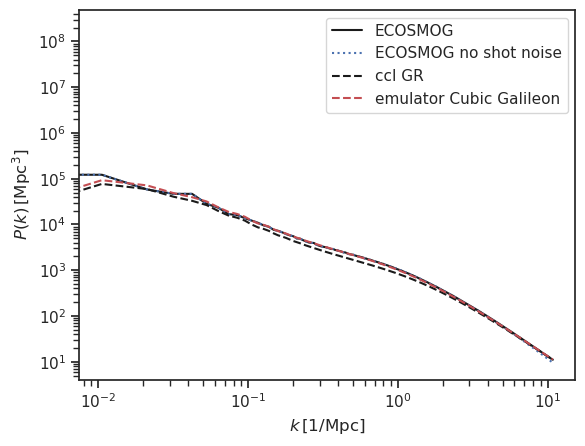

In [ ]:

data_CG_emu = P_k_NL_CuGal(P_delta2D_GR_nl_test,1.0, cosmo_universe, k_ECOSMOG, 1.0)

plt.loglog(k_ECOSMOG, Pk_ECOSMOG*(400/cosmo_universe["h"])**3, "k", label = "ECOSMOG") # convert to Mpc^3
plt.loglog(k_ECOSMOG, Pk_ECOSMOG_noshot*(400/cosmo_universe["h"])**3, "b:", label = "ECOSMOG no shot noise") # convert to Mpc^3
plt.loglog(k_ECOSMOG, ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG, a=1), "k--", label = "ccl GR")

plt.loglog(k_ECOSMOG, data_CG_emu, "r--", label = "emulator Cubic Galileon")

plt.xlabel(r'$k \, [1/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k) \, [\mathrm{Mpc}^3]$')
plt.legend()

/tmp/ipykernel_292307/120895143.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.semilogx(k_ECOSMOG, Pk_ECOSMOG*(400/cosmo_universe["h"])**3/ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG, a=1), "k", label = "ECOSMOG")
/tmp/ipykernel_292307/120895143.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.semilogx(k_ECOSMOG, Pk_ECOSMOG_noshot*(400/cosmo_universe["h"])**3/ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG, a=1), "b:", label = "ECOSMOG no shot noise")


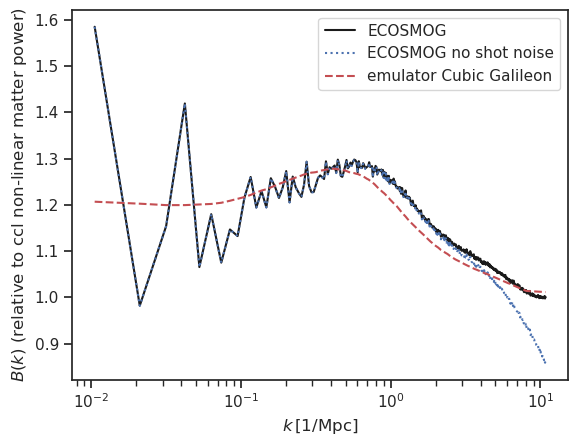

In [ ]:
plt.semilogx(k_ECOSMOG, Pk_ECOSMOG*(400/cosmo_universe["h"])**3/ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG, a=1), "k", label = "ECOSMOG")
plt.semilogx(k_ECOSMOG, Pk_ECOSMOG_noshot*(400/cosmo_universe["h"])**3/ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG, a=1), "b:", label = "ECOSMOG no shot noise")
plt.semilogx(k_ECOSMOG, data_CG_emu/ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG, a=1), "r--", label = "emulator Cubic Galileon")

plt.xlabel(r'$k \, [1/\mathrm{Mpc}]$')
plt.ylabel(r'$B(k)$ (relative to ccl non-linear matter power)')
plt.legend()

0.5604538462151119


/global/homes/c/carolazn/.conda/envs/HiCOLA_Env/lib/python3.11/site-packages/pyccl/pk2d.py:287: RuntimeWarning: divide by zero encountered in log
  lk_use = np.log(k_use)
/tmp/ipykernel_292307/3745057540.py:20: RuntimeWarning: divide by zero encountered in divide
  plt.semilogx(k_ECOSMOG, Pk_ECOSMOG*(400/cosmo_universe["h"])**3/ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG, a=1), "k", label = "ECOSMOG")
/tmp/ipykernel_292307/3745057540.py:21: RuntimeWarning: divide by zero encountered in divide
  plt.semilogx(k_ECOSMOG, Pk_ECOSMOG_noshot*(400/cosmo_universe["h"])**3/ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG, a=1), "b:", label = "ECOSMOG no shot noise")


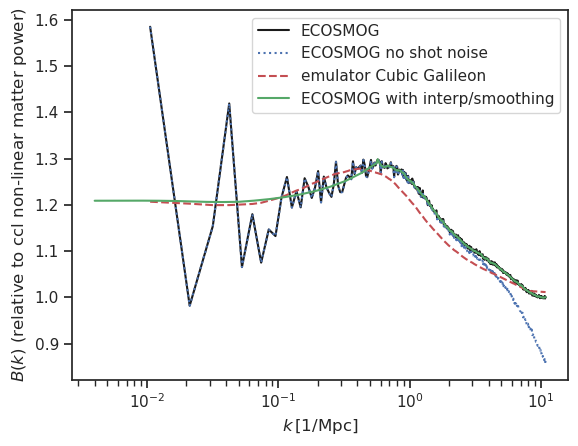

In [ ]:
from scipy.interpolate import UnivariateSpline

# get CG linear at large scales
#k_large = np.logspace(np.log10(4e-3), np.log10(5e-2), 10)
#CG_lin_Bk = P_k_CuGal_lin_v2(P_delta2D_GR_lin_test,1.0,cosmo_universe, k_large, 1)/ccl.power.linear_matter_power(cosmo_universe, k=k_large, a=1)

# for intermediate scales, do a monotonically increasing smooth interpolation between the CG linear and non-linear (ecosmog)
idx_k = np.argmax(savgol_filter(Pk_ECOSMOG[k_ECOSMOG > 1e-1], 17,3)/ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG[k_ECOSMOG > 1e-1], a=1))
k_interp_large = k_ECOSMOG[k_ECOSMOG > 1e-1][idx_k]
print(k_interp_large)
k_interp = np.logspace(np.log10(5e-2), np.log10(k_interp_large), 10)
spl = UnivariateSpline([5e-2, k_interp_large], np.array([CG_lin_Bk[-1], savgol_filter(Pk_ECOSMOG, 17,3)[k_ECOSMOG > k_interp_large][0]*(400/cosmo_universe["h"])**3/ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG[k_ECOSMOG > k_interp_large][0], a=1)]), k=1, s=0)
Bk_interp = spl(k_interp)

# create a version of ecosmog that is smooth on large scales
Bk_ecosmog_small = Pk_ECOSMOG[k_ECOSMOG > k_interp_large]*(400/cosmo_universe["h"])**3/ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG[k_ECOSMOG > k_interp_large], a=1)
Bk_smooth = np.append(np.append(CG_lin_Bk, Bk_interp), savgol_filter(Bk_ecosmog_small, 17, 3))
k_test = np.append(np.append(k_large, k_interp), k_ECOSMOG[k_ECOSMOG > k_interp_large])

plt.semilogx(k_ECOSMOG, Pk_ECOSMOG*(400/cosmo_universe["h"])**3/ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG, a=1), "k", label = "ECOSMOG")
plt.semilogx(k_ECOSMOG, Pk_ECOSMOG_noshot*(400/cosmo_universe["h"])**3/ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG, a=1), "b:", label = "ECOSMOG no shot noise")
plt.semilogx(k_ECOSMOG, data_CG_emu/ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG, a=1), "r--", label = "emulator Cubic Galileon")

plt.plot(k_test, Bk_smooth, "g", label = "ECOSMOG with interp/smoothing")

plt.xlabel(r'$k \, [1/\mathrm{Mpc}]$')
plt.ylabel(r'$B(k)$ (relative to ccl non-linear matter power)')
plt.legend()



/global/homes/c/carolazn/.conda/envs/HiCOLA_Env/lib/python3.11/site-packages/pyccl/pk2d.py:287: RuntimeWarning: divide by zero encountered in log
  lk_use = np.log(k_use)


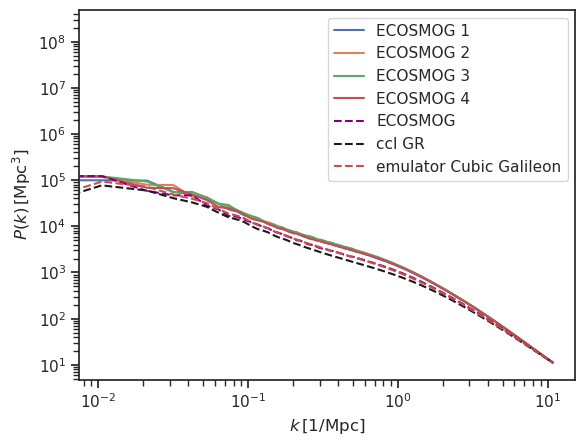

In [36]:
## method 2: use P(k) at z=0

# visualize

for i in range(1,5):
    filepath = './Validation_data/ECOSMOG_sims/5_boxes_Pk/z0{0}_b400np512_pk_a100.dat'.format(i)
    data = np.loadtxt(filepath)
    k_ECOSMOG = data[:,0]
    #Pk_ECOSMOG_noshot = data[:,3] - data[:,4]/512**3 # subtract shot noise (Pk_shot, n = 512^3 for ECOSMOG sims) from the raw power spectrum to get the matter power spectrum
    Pk_ECOSMOG = data[:,3]
    k_ECOSMOG = k_ECOSMOG*(2*np.pi/(400/cosmo_universe["h"])) # convert to 1/Mpc
    plt.loglog(k_ECOSMOG, Pk_ECOSMOG*(400/cosmo_universe["h"])**3, label = "ECOSMOG {0}".format(i)) # convert to Mpc^3


filepath = './Validation_data/ECOSMOG_sims/ECOSMOG/PK_cGal_full_s06.dat'
data = np.loadtxt(filepath)
k_ECOSMOG = data[:,0]
#Pk_ECOSMOG_noshot = data[:,3] - data[:,4]/512**3 # subtract shot noise (Pk_shot, n = 512^3 for ECOSMOG sims) from the raw power spectrum to get the matter power spectrum
Pk_ECOSMOG = data[:,3]
k_ECOSMOG = k_ECOSMOG*(2*np.pi/(400/cosmo_universe["h"])) # convert to 1/Mpc
plt.loglog(k_ECOSMOG, Pk_ECOSMOG*(400/cosmo_universe["h"])**3, color="purple",linestyle="--", label = "ECOSMOG") # convert to Mpc^3


cosmo_universe = ccl.Cosmology(Omega_c= 0.264201, Omega_b= 0.0490218, h= 0.6732, n_s= 0.9655, A_s= 2.0095e-9)

data_CG_emu = P_k_NL_CuGal(P_delta2D_GR_nl_test,1.0, cosmo_universe, k_ECOSMOG, 1.0)

plt.loglog(k_ECOSMOG, ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG, a=1), "k--", label = "ccl GR")

plt.loglog(k_ECOSMOG, data_CG_emu, "r--", label = "emulator Cubic Galileon")

plt.xlabel(r'$k \, [1/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k) \, [\mathrm{Mpc}^3]$')
plt.legend()

/tmp/ipykernel_365234/1793573835.py:14: RuntimeWarning: divide by zero encountered in divide
  plt.semilogx(k_ECOSMOG, Pk_ECOSMOG*(400/cosmo_universe["h"])**3/GR_Pk, label = "ECOSMOG {0}".format(i)) # convert to Mpc^3
/tmp/ipykernel_365234/1793573835.py:22: RuntimeWarning: divide by zero encountered in divide
  plt.semilogx(k_ECOSMOG, Pk_ECOSMOG*(400/cosmo_universe["h"])**3/GR_Pk, color="k",linestyle="--", label = "postreferee") # convert to Mpc^3
/tmp/ipykernel_365234/1793573835.py:31: RuntimeWarning: divide by zero encountered in divide
  plt.semilogx(k_ECOSMOG, Pk_ECOSMOG*(400/cosmo_universe["h"])**3/GR_Pk, color="purple",linestyle="--", label = "ECOSMOG") # convert to Mpc^3


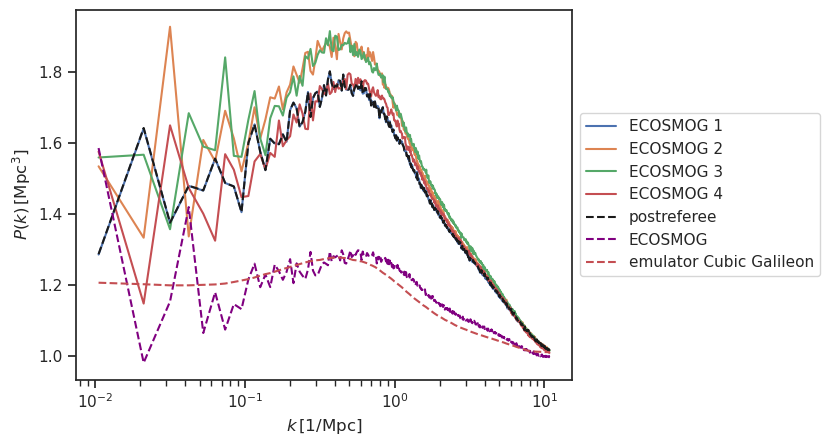

In [ ]:
## method 2: use P(k) at z=0

# visualize

GR_Pk =ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG, a=1)

for i in range(1,5):
    filepath = './Validation_data/ECOSMOG_sims/5_boxes_Pk/z0{0}_b400np512_pk_a100.dat'.format(i)
    data = np.loadtxt(filepath)
    k_ECOSMOG = data[:,0]
    #Pk_ECOSMOG_noshot = data[:,3] - data[:,4]/512**3 # subtract shot noise (Pk_shot, n = 512^3 for ECOSMOG sims) from the raw power spectrum to get the matter power spectrum
    Pk_ECOSMOG = data[:,3]
    k_ECOSMOG = k_ECOSMOG*(2*np.pi/(400/cosmo_universe["h"])) # convert to 1/Mpc
    plt.semilogx(k_ECOSMOG, Pk_ECOSMOG*(400/cosmo_universe["h"])**3/GR_Pk, label = "ECOSMOG {0}".format(i)) # convert to Mpc^3

filepath = './Validation_data/ECOSMOG_sims/5_boxes_Pk/z02_b400np512_pk_a100_postreferee.dat'
data = np.loadtxt(filepath)
k_ECOSMOG = data[:,0]
#Pk_ECOSMOG_noshot = data[:,3] - data[:,4]/512**3 # subtract shot noise (Pk_shot, n = 512^3 for ECOSMOG sims) from the raw power spectrum to get the matter power spectrum
Pk_ECOSMOG = data[:,3]
k_ECOSMOG = k_ECOSMOG*(2*np.pi/(400/cosmo_universe["h"])) # convert to 1/Mpc
plt.semilogx(k_ECOSMOG, Pk_ECOSMOG*(400/cosmo_universe["h"])**3/GR_Pk, color="k",linestyle="--", label = "postreferee") # convert to Mpc^3


filepath = './Validation_data/ECOSMOG_sims/ECOSMOG/PK_cGal_full_s06.dat'
data = np.loadtxt(filepath)
k_ECOSMOG = data[:,0]
#Pk_ECOSMOG_noshot = data[:,3] - data[:,4]/512**3 # subtract shot noise (Pk_shot, n = 512^3 for ECOSMOG sims) from the raw power spectrum to get the matter power spectrum
Pk_ECOSMOG = data[:,3]
k_ECOSMOG = k_ECOSMOG*(2*np.pi/(400/cosmo_universe["h"])) # convert to 1/Mpc
plt.semilogx(k_ECOSMOG, Pk_ECOSMOG*(400/cosmo_universe["h"])**3/GR_Pk, color="purple",linestyle="--", label = "ECOSMOG") # convert to Mpc^3


cosmo_universe = ccl.Cosmology(Omega_c= 0.264201, Omega_b= 0.0490218, h= 0.6732, n_s= 0.9655, A_s= 2.0095e-9)

data_CG_emu = P_k_NL_CuGal(P_delta2D_GR_nl_test,1.0, cosmo_universe, k_ECOSMOG, 1.0)


plt.semilogx(k_ECOSMOG, data_CG_emu/GR_Pk, "r--", label = "emulator Cubic Galileon")

plt.xlabel(r'$k \, [1/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k) \, [\mathrm{Mpc}^3]$')
# plot legend outside to the right of plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# 

In [46]:
# load data from PowerI4 - we don't use this because it's for too limited a redshift range
"""
data = np.loadtxt("./Validation_data/ECOSMOG_sims/Box1/AB_linCuGal_a1dot00_PowerI4.txt", skiprows=1)

#rescale k
data[:,0] = data[:,0] / cosmo_testing["h"]
# rescale P(k)
data[:,1] = data[:,1] * cosmo_testing["h"]**3

cosmo_universe = ccl.Cosmology(Omega_c= 0.264201, Omega_b= 0.0490218, h= 0.6732, n_s= 0.9655, A_s= 2.0095e-9)

data_CG_emu = P_k_NL_CuGal(P_delta2D_GR_nl_test,1.0, cosmo_universe, data[:,0], 1.0)

plt.loglog(data[:,0], (2*np.pi)**3*data[:,2], "r", label = "ECOSMOG Cubic Galileon")
plt.loglog(data[:,0], ccl.power.nonlin_matter_power(cosmo_universe, k=data[:,0], a=1), "k--", label = "ccl GR")
plt.loglog(data[:,0], data_CG_emu, "r--", label = "emulator Cubic Galileon")

plt.xlabel(r'$k \, [1/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k) \, [\mathrm{Mpc}^3]$')
plt.legend()
"""

'\ndata = np.loadtxt("./Validation_data/ECOSMOG_sims/Box1/AB_linCuGal_a1dot00_PowerI4.txt", skiprows=1)\n\n#rescale k\ndata[:,0] = data[:,0] / cosmo_testing["h"]\n# rescale P(k)\ndata[:,1] = data[:,1] * cosmo_testing["h"]**3\n\ncosmo_universe = ccl.Cosmology(Omega_c= 0.264201, Omega_b= 0.0490218, h= 0.6732, n_s= 0.9655, A_s= 2.0095e-9)\n\ndata_CG_emu = P_k_NL_CuGal(P_delta2D_GR_nl_test,1.0, cosmo_universe, data[:,0], 1.0)\n\nplt.loglog(data[:,0], (2*np.pi)**3*data[:,2], "r", label = "ECOSMOG Cubic Galileon")\nplt.loglog(data[:,0], ccl.power.nonlin_matter_power(cosmo_universe, k=data[:,0], a=1), "k--", label = "ccl GR")\nplt.loglog(data[:,0], data_CG_emu, "r--", label = "emulator Cubic Galileon")\n\nplt.xlabel(r\'$k \\, [1/\\mathrm{Mpc}]$\')\nplt.ylabel(r\'$P(k) \\, [\\mathrm{Mpc}^3]$\')\nplt.legend()\n'

In [47]:
z_vals_sim = (np.array([49., 2., 1., 0.5, 0.25, 0.]))
indx_sim = (np.array([1, 2, 3, 4, 5, 6])) # indices of simulations to use

Pk_vals_sim = np.zeros((len(z_vals_sim), len(k_ECOSMOG)))
for i in range(len(z_vals_sim)):
    filepath = './Validation_data/ECOSMOG_sims/ECOSMOG/PK_cGal_full_s0{}.dat'.format(indx_sim[i])
    data = np.loadtxt(filepath)
    # check k is the same as k_ECOSMOG
    k_sim = data[:,0]*(2*np.pi/(400/cosmo_universe["h"]))
    if not np.allclose(k_sim, k_ECOSMOG):
        raise ValueError("k values in the simulation data do not match expected k_ECOSMOG")
    Pk_ECOSMOG = (data[:,3] - data[:,4]/512**3)*(400/cosmo_universe["h"])**3 # subtract shot noise and convert to Mpc^3
    
    Pk_vals_sim[i,:] = Pk_ECOSMOG


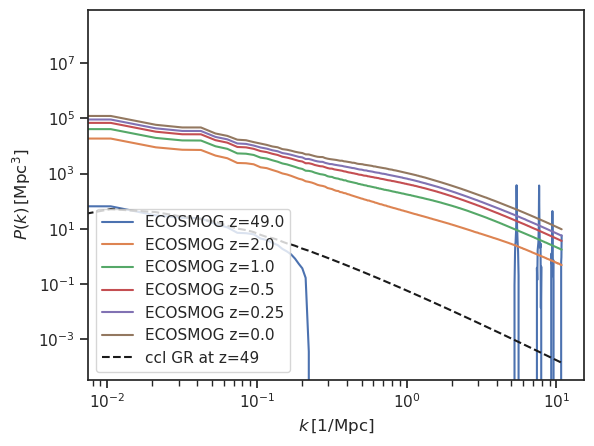

In [48]:
# plot P(k) at different redshifts 
for i in range(len(z_vals_sim)):
    plt.loglog(k_ECOSMOG, Pk_vals_sim[i,:], label = "ECOSMOG z={}".format(z_vals_sim[i]))
    
plt.loglog(k_ECOSMOG, ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG, a=1/(1+49)), "k--", label = "ccl GR at z=49")
plt.xlabel(r'$k \, [1/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k) \, [\mathrm{Mpc}^3]$')
plt.legend()

In [49]:
# set Pk_vals_sim[-1,:] = GR expectation at z=49 from ccl (good enough for our purposes since we don't use much past z=2)
Pk_vals_sim[0,:] = ccl.power.nonlin_matter_power(cosmo_universe, k=k_ECOSMOG, a=1/(1+49))

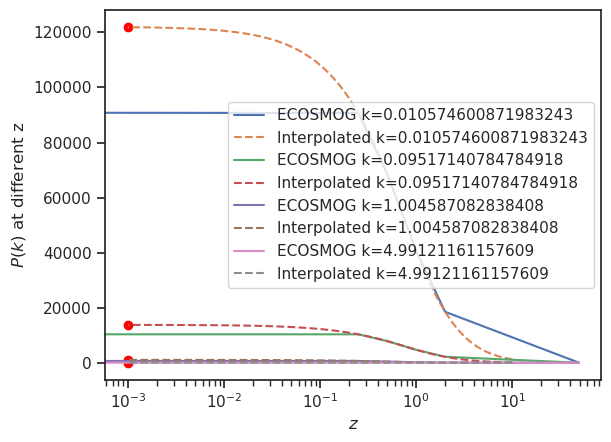

In [50]:
# create interpolator
Pk_CuGal_cosmo_funct_ECOSMOG =  scipy.interpolate.RectBivariateSpline(1/(z_vals_sim+1), k_ECOSMOG, Pk_vals_sim)
# plot P(z) at different k values
k_indices = [1e-2, 1e-1, 1, 5]

z_arr_test = np.flip(np.logspace(-3, 1, 100))

for k_val in k_indices:
    k_idx = np.argmin(np.abs(k_ECOSMOG - k_val))
    plt.semilogx(z_vals_sim, Pk_vals_sim[:, k_idx], label = "ECOSMOG k={}".format(k_ECOSMOG[k_idx]),)
    plt.semilogx(z_arr_test, Pk_CuGal_cosmo_funct_ECOSMOG(1/(z_arr_test+1), k_ECOSMOG[k_idx]), label = "Interpolated k={}".format(k_ECOSMOG[k_idx]), linestyle="--")
    plt.scatter(1e-3, Pk_vals_sim[-1, k_idx], color='red')

plt.xlabel(r'$z$')
plt.ylabel(r'$P(k)$ at different z')
plt
plt.legend()

In [51]:
# Define cosmology -- our "universe cosmology"

f_phi_universe = 1.0
a_setup_universe, UE_setup_universe, coupling_setup_universe = CuGal_initialize(f_phi_universe, cosmo_universe)

P_delta2D_GR_lin_universe = Get_Pk2D_obj_kk_GR_lin(cosmo_universe)
P_delta2D_GR_nl_universe = Get_Pk2D_obj_kk_GR_nl(cosmo_universe)

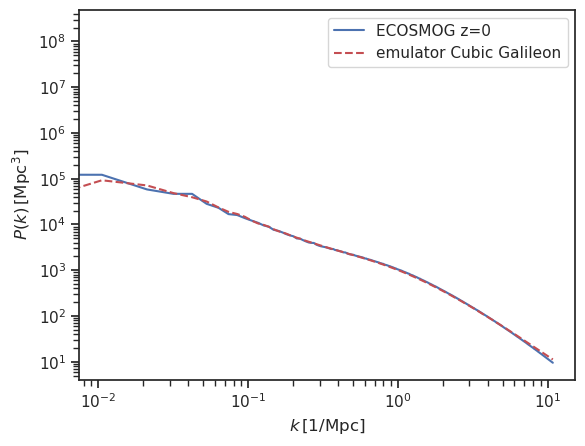

In [52]:
# plot emulator P(k) against ECOSMOG simulations for our "universe cosmology"
data_CG_emu_universe = P_k_NL_CuGal(P_delta2D_GR_nl_universe, f_phi_universe, cosmo_universe, k_ECOSMOG, 1.0)
plt.loglog(k_ECOSMOG, Pk_CuGal_cosmo_funct_ECOSMOG([1], k_ECOSMOG).flatten(), "b", label = "ECOSMOG z=0")
plt.loglog(k_ECOSMOG, data_CG_emu_universe, "r--", label = "emulator Cubic Galileon")
plt.xlabel(r'$k \,[1/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k) \, [\mathrm{Mpc}^3]$')
plt.legend()

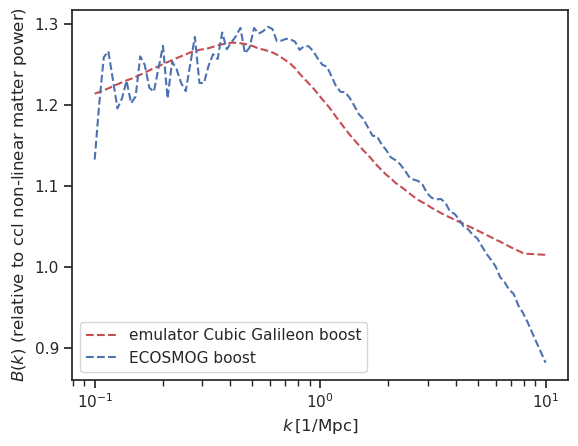

In [53]:
# plot the boosts
k_plot = np.logspace(-1,1,100)
z_plot = 0.0
Pk_CuGal_plot = P_k_NL_CuGal(P_delta2D_GR_nl_universe, f_phi_universe, cosmo_universe, k_plot, 1.0)
Pk_GR_plot = ccl.power.nonlin_matter_power(cosmo_universe, k=k_plot, a=1)
plt.semilogx(k_plot, Pk_CuGal_plot/Pk_GR_plot, "r--", label = "emulator Cubic Galileon boost")
plt.semilogx(k_plot, Pk_CuGal_cosmo_funct_ECOSMOG(1/(z_plot+1), k_plot).flatten()/ccl.power.nonlin_matter_power(cosmo_universe, k=k_plot, a=1/(1+z_plot)), "b--", label = "ECOSMOG boost")
plt.xlabel(r'$k \, [1/\mathrm{Mpc}]$')
plt.ylabel(r'$B(k)$ (relative to ccl non-linear matter power)')
plt.legend()

## 4a. Get mock 3x2pt data

In [54]:
"""Check we match SRD"""


# ell binning for shear
print(np.loadtxt("ell-values").shape)
ells_SRD = np.loadtxt("ell-values")

print(ells_SRD)
print(bins(20, 1478.5, 13))
print(bins(20, 15000, 20))

(20,)
[   23.5997     32.8594     45.75227    63.70386    88.69901   123.5014
   171.959     239.4297    333.3735    464.1775    646.3045    899.8917
  1252.978    1744.602    2429.122    3382.225    4709.291    6557.052
  9129.808   12712.02   ]
[  23.59970561   32.85941027   45.75230138   63.70391509   88.6991184
  123.5015712   171.95929751  239.43015228  333.37422663  464.17869231
  646.30628639  899.89442158 1252.98173181]
[   23.59970245    32.85939707    45.75227075    63.70385538
    88.69901151   123.50138929   171.95899817   239.42967137
   333.37346775   464.17751136   646.30446899   899.89165011
  1252.97753734  1744.60192946  2429.12247153  3382.22483998
  4709.29111325  6557.05159727  9129.80841814 12712.02468297]


In [55]:

# define ell and C_ell shapes -- will depend on the data

ell_min_mockdata = 20
ell_max_mockdata = 15000

# define quantities for binning of ell -- will depend on the data

ell_bin_num_mockdata = 20

In [56]:
"""Get mock C(ell) data"""

## LENSING - LENSING

binned_ell = bin_ell_kk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata, Binned_distribution_source)

# find C_ell for non-linear matter power spectrum
mockdata = Cell_CuGal_Validation(binned_ell,a_setup_universe, UE_setup_universe, coupling_setup_universe, f_phi_universe, cosmo_universe, 
                      z , Binned_distribution_source,Binned_distribution_lens,
                      Bias_distribution_fiducial, P_delta2D_GR_nl_universe, tracer1_type="k", tracer2_type="k")

ell_kk_mockdata = mockdata[0]
D_kk_mockdata = mockdata[1]
D_kk_mockdata = (np.array(D_kk_mockdata)).flatten()

## CLUSTERING - LENSING

binned_ell = bin_ell_delk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata,Binned_distribution_source,Binned_distribution_lens)

# find C_ell for non-linear matter power spectrum
mockdata = Cell_CuGal_Validation(binned_ell,a_setup_universe, UE_setup_universe, coupling_setup_universe, f_phi_universe,
                      cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,\
                      Bias_distribution_fiducial,P_delta2D_GR_nl_universe, tracer1_type="k", tracer2_type="g")

ell_delk_mockdata = mockdata[0]
D_delk_mockdata = mockdata[1]
D_delk_mockdata = (np.array(D_delk_mockdata)).flatten()

## CLUSTERING - CLUSTERING
binned_ell = bin_ell_deldel(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata,Binned_distribution_lens)

# find C_ell for non-linear matter power spectrum
mockdata = Cell_CuGal_Validation(binned_ell,a_setup_universe, UE_setup_universe, coupling_setup_universe, f_phi_universe,
                      cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,\
                      Bias_distribution_fiducial, P_delta2D_GR_nl_universe, tracer1_type="g", tracer2_type="g")

ell_deldel_mockdata = mockdata[0]
D_deldel_mockdata = mockdata[1]
D_deldel_mockdata = (np.array(D_deldel_mockdata)).flatten()


ell_mockdata = np.append(np.append(ell_kk_mockdata, ell_delk_mockdata), ell_deldel_mockdata)
D_mockdata = np.append(np.append(D_kk_mockdata, D_delk_mockdata), D_deldel_mockdata)

print(D_kk_mockdata.shape, D_delk_mockdata.shape, D_deldel_mockdata.shape)
del mockdata



(300,) (140,) (100,)


(540,)
27
20


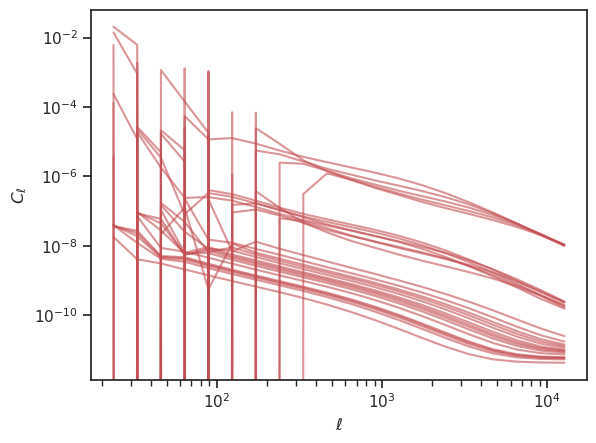

In [57]:
"""Plots: Test C(ell) function"""
print(D_mockdata.shape)
print(int(len(D_mockdata)/ell_bin_num_mockdata))
print(ell_bin_num_mockdata)

ell_bin_number = int(len(ell_mockdata)/((len(Binned_distribution_source)+1)*len(Binned_distribution_source)/2))

for j in range(int(len(D_mockdata)/ell_bin_num_mockdata)):
    plt.plot(ell_mockdata[j*ell_bin_num_mockdata:(j+1)*ell_bin_num_mockdata], D_mockdata[j*ell_bin_num_mockdata:(j+1)*ell_bin_num_mockdata], "r", alpha=0.6)
    #plt.plot(ell_mockdata[j*ell_bin_num_mockdata:(j+1)*ell_bin_num_mockdata], D_data_lin_plot[j*ell_bin_num_mockdata:(j+1)*ell_bin_num_mockdata], "k", alpha=0.6)
    #plt.plot(ell_mockdata[j*ell_bin_number:(j+1)*ell_bin_number], (D_mockdata[j*ell_bin_number:(j+1)*ell_bin_number] - D_data_lin_plot[j*ell_bin_number:(j+1)*ell_bin_number])/D_mockdata[j*ell_bin_number:(j+1)*ell_bin_number], "k", alpha=0.6)

plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell$')
plt.xscale('log')
plt.yscale('log')
plt.show()

## 4b. Get mock fsigma8 data

In [58]:
"""Get simulated DESI LRG data using Danielle's code"""

def f_frac_err(GR_pk2D_obj, a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo,b, zeff, nbar, V):
    """ Get the fractional error on the growth rate.
    params is a dictionary of required cosmological parameters.
    zeff is the effective redshift of the sample.
    nbar is the number density of the sample in units of (h/Mpc)^3.
    V is the volume of the survey in (Mpc/h)^3. """
    
    # Set up a k and mu vector at which to do the integrals
    # (Result depends on kmax chosen, see White et al. 2008)
	
    k = np.logspace(-3, -1, 400)
    mu = np.linspace(-1, 1., 200)
        
    # Get the inverse covariance value at each k and mu
    print("Getting inverse data covariance for beta variance calculation.")
    invcov = Pobs_covinv(GR_pk2D_obj, a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo,b, k, mu, zeff, nbar)
    
    # Get the derivative of the observed z-space
    # P(k) with respect to b and f at each k and mu
    # (linear theory)
    print("Getting derivative.")
    dPdf = diff_P_f(GR_pk2D_obj, a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo,b, k, mu, zeff)
    
    # Do the integration in k in each case
    print("Doing k integration.")
    int_in_k_ff = [scipy.integrate.simps(k**2 * dPdf[mi] * invcov[mi] * dPdf[mi], k) for mi in range(len(mu))]
	
    # And in mu.
    print("Doing mu integration.")
    int_in_mu_ff = scipy.integrate.simps(np.asarray(int_in_k_ff), mu)
	
    Fisher_ff = np.zeros((2,2)) # order is b then f
    
    # Add necessary factors of volume (Mpc/h)^3 and pi etc
    ff= V * int_in_mu_ff / (2. * np.pi**2)
    err_f = np.sqrt(1./ff)
    
    # Now use this to construct the error on f:
    f_sigma8_val = fsigma8_CuGal(GR_pk2D_obj, a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo,[1./(1. + zeff),1./(1. + zeff)])[0]

    f_fid = f_sigma8_val/sigma_8_CuGal(GR_pk2D_obj, f_phi, cosmo, [1./(1. + zeff),1./(1. + zeff)])[0]
    
    frac_err_f = err_f / f_fid
    
    return frac_err_f, f_sigma8_val
    
def diff_P_f(GR_pk2D_obj, a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo,b, k, mu, zeff):
    """ Calculate the derivative of the redshift space power spectrum
    wrt linear growth rate f at each k and mu
    params: dictionary of cosmological parameters
    k: list or array of wavenumbers
    mu: list of array of angles
    lens: lens sample label
    """
		
    # Get the linear power spectrum at the effective z of the lens sample
    Pklin = P_k_CuGal_lin(GR_pk2D_obj, f_phi,cosmo, k,  1./ (1. + zeff))
    
    # Get the derivative at each mu / k
    f = fsigma8_CuGal(GR_pk2D_obj, a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo, [1./(1. + zeff),1./(1. + zeff)])[0]/sigma_8_CuGal(GR_pk2D_obj, f_phi, cosmo, [1./(1. + zeff),1./(1. + zeff)])[0]
    dPdf = [2. * (b + mu[mi]**2*f) * mu[mi]**2 * Pklin  for mi in range(len(mu))]
	
    return dPdf
    
def Pobs_covinv(GR_pk2D_obj, a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo,b, k, mu, zeff, nbar):
    """ Get the inverse covariance of the redshift space observed power 
    spectrum at a list of k and mu (cosine of angle to line of sight) vals.
    params: dictionary of cosmological parameters
    k: list or array of wavenumbers
    mu: list of array of angles
    lens: lens sample label """	
 
	
    # Get the linear power spectrum at the effective z of the lens sample
    Pklin = P_k_CuGal_lin(GR_pk2D_obj,f_phi,cosmo, k,  1./ (1. + zeff))
	
    # Get the redshift space galaxy power spectrum in linear theory
    f = fsigma8_CuGal(GR_pk2D_obj, a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo, [1./(1. + zeff),1./(1. + zeff)])[0]/sigma_8_CuGal(GR_pk2D_obj, f_phi, cosmo, [1./(1. + zeff),1./(1. + zeff)])[0]
    Pgg = [(b + f * mu[mi]**2)**2 * Pklin for mi in range(len(mu))]
	
    # Get the covariance matrix at each k and mu
    cov = [ 2. * (Pgg[mi]**2 + 2 * Pgg[mi] / nbar + 1. / nbar**2) for mi in range(len(mu))]
	
    #Pgg_arr = np.zeros((len(k), len(mu)))
    #for mi in range(len(mu)):
    #	Pgg_arr[:, mi] = Pgg[mi]
	
    # Get the inverse at each k and mu
    invcov = [[1./ cov[mi][ki] for ki in range(len(k))] for mi in range(len(mu))]
			
    return invcov

zeff= 0.72
nbar = 5*10**(-4)
Vol = 3*10**9

f_fe, f_fid = f_frac_err(P_delta2D_GR_lin_universe, a_setup_universe, UE_setup_universe, coupling_setup_universe, f_phi_universe,cosmo_universe,2.03, zeff, nbar, Vol)

print('sigma(f) / f =',f_fe)
print('fid f sigma8=', f_fid)
print('sigma(f sigma8) =', f_fe*f_fid)

Getting inverse data covariance for beta variance calculation.
Getting derivative.
Doing k integration.
Doing mu integration.
sigma(f) / f = 0.015040247889027705
fid f sigma8= 0.531438529405877
sigma(f sigma8) = 0.007992967220044729


In [59]:
# Using data described in Section 3.4 of https://arxiv.org/pdf/2201.07025 (Jaime's paper)
# Dataset 1 (x3): RSD BOSS DR12 data https://arxiv.org/pdf/1607.03155
# Dataset 2 (x1): BOSS DR16 quasar sample 𝑓𝜎8(𝑧eff) measurement https://arxiv.org/pdf/2007.08998
# Dataset 3 (x3): WiggleZ Dark Energy Survey data https://arxiv.org/pdf/1204.3674
# Dataset 4 (x1): 𝑓𝜎8(𝑧 = 0) from peculiar velocities of Democratic Samples of Supernovae https://arxiv.org/pdf/2105.05185

z_eff = np.array([0.38 , 0.51 , 0.61 , 1.48 , 0.44 , 0.6 , 0.73 , 0.0, zeff])

fsigma_8_realdata = np.array([0.497 , 0.458 , 0.436, 0.462 , 0.413 , 0.39 , 0.437 , 0.39])

fsigma_8_fracerror = np.array([0.045/0.497 , 0.038/0.458 , 0.034/0.436, 0.045/0.462 , \
                               0.08/0.413 , 0.063/0.39 , 0.072/0.437 , 0.022/0.39, f_fe])

reducedcov_fsigma_8 = np.array([[1 , 0.4773 , 0.1704 , 0 , 0 , 0 , 0 , 0,0],
                               [ 0.4773 , 1 , 0.5103 , 0 , 0 , 0 , 0 , 0,0],
                               [0.1704 , 0.5103 , 1 , 0 , 0 , 0 , 0 , 0,0],
                               [0 , 0 , 0 , 1 , 0 , 0 , 0 , 0,0],
                               [0 , 0 , 0 , 0 , 1 , 0.50992 , 0.0 , 0,0],
                               [0 , 0 , 0 , 0 , 0.50992 , 1 , 0.559965 , 0,0],
                               [0 , 0 , 0 , 0 , 0.0 , 0.559965 , 1 , 0,0],
                               [0 , 0 , 0 , 0 , 0 , 0 , 0 , 1,0],
                               [0 , 0 , 0 , 0 , 0 , 0 , 0 , 0,1]]
                       )

headers = z_eff.tolist()

## Create our data:

fsigma_8_data = fsigma8_CuGal(P_delta2D_GR_lin_universe, a_setup_universe, UE_setup_universe, coupling_setup_universe, f_phi_universe,cosmo_universe, 1/(z_eff+1))

cov_fsigma8 = reducedcov_fsigma_8 * np.outer(fsigma_8_data*fsigma_8_fracerror, fsigma_8_data*fsigma_8_fracerror)
invcov_fsigma8 = np.linalg.inv(cov_fsigma8)

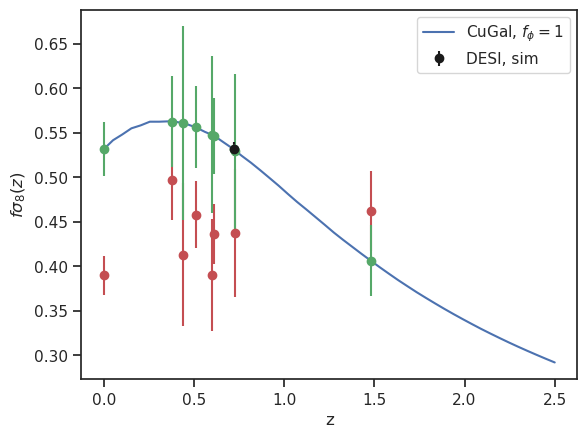

In [60]:
""" Plots: Test our fsigma8 data """

# TEST by comparing with tables in papers
#print(tabulate(reducedcov_fsigma_8[:-1,:-1] * np.outer(fsigma_8_realdata*fsigma_8_fracerror[:-1], fsigma_8_realdata*fsigma_8_fracerror[:-1]), headers))

plt.plot(np.linspace(0.0, 2.5, 50), fsigma8_CuGal(P_delta2D_GR_lin_universe, a_setup_universe, UE_setup_universe, coupling_setup_universe, f_phi_universe,cosmo_universe, 1/(np.linspace(0.0, 2.5, 50)+1)), label=r"CuGal, $f_\phi = 1$")
plt.errorbar(z_eff[:-1], fsigma_8_realdata, yerr=fsigma_8_realdata*fsigma_8_fracerror[:-1], fmt="o", color="r")
plt.errorbar(z_eff, fsigma_8_data, yerr=fsigma_8_data*fsigma_8_fracerror, fmt="o", color="g")
plt.errorbar(z_eff[-1], fsigma_8_data[-1], yerr=fsigma_8_data[-1]*fsigma_8_fracerror[-1], fmt="o", color="k", label = "DESI, sim")

plt.xlabel("z")
plt.ylabel(r"$f \sigma_8(z)$")
plt.legend()

## 4c. Get covariance matrix

Note that for Y1 SRD gives area = 12.3 k deg^2 (total area on sphere = 41.253 k deg^2), so f_sky = 0.298.

Also, they define the number density following empirical results from the HSC survey (Appendix F1), finding a value of 18 arcmin^{−2} for Y1 lens sample.

Also, For Y1, the per-bin bias values that were actually used were [1.562362, 1.732963, 1.913252, 2.100644, 2.293210] (D1.1).

Also, for Y1, neff = 9.52 over the 5 bins (from plot Fig F4) (or 10 from D2.1), so 1.904 per bin

In [61]:
def cov2corr(cov):
    """
    Convert a covariance matrix into a correlation matrix
    input:
        cov: numpy.array with dim:(N,N)
    returns:
        corr: numpy.array with dim:(N,N)
    """
    sig = np.sqrt(cov.diagonal())
    return cov/np.outer(sig, sig)

In [62]:
"""Get SRD covariance matrix"""

# covariance for shear bin combinations, in order: z11, z12, z13,..., z15, z22, z23,...z55

########## Get full covariance (gauss only) ##########

covfile = np.genfromtxt("/global/u2/c/carolazn/CuGal_Emu_project_mcmc/Y1_3x2pt_clusterN_clusterWL_cov")
print(covfile.shape)

shear_SRD = np.zeros((705,705))
ell_test_SRD = np.zeros(705)

for i in range(0,covfile.shape[0]):
    shear_SRD[int(covfile[i,0]),int(covfile[i,1])] = covfile[i,8]+covfile[i,9] # non-gauss
    shear_SRD[int(covfile[i,1]),int(covfile[i,0])] = covfile[i,8]+covfile[i,9] # non-gauss
    if int(covfile[i,0]) == int(covfile[i,1]):
        ell_test_SRD[int(covfile[i,0])] = covfile[i,2]

del covfile
print(shear_SRD.shape)

SRD_compare = shear_SRD[:540,:540].copy()
print(SRD_compare.shape)
########## Cut ell bins ##########
"""
for j in 15+7+5 = 27,
for i in 20,
if i > 13, remove j*20 + i th element

15 = int(len(D_mockdata)/ell_bin_num_mockdata)
27 = len(SRD_compare)/15
13 = ell_bin_num_mockdata
"""

idx = 0

bins_SRD = int(len(SRD_compare)/(len(D_mockdata)/ell_bin_num_mockdata))
print(int(len(D_mockdata)/ell_bin_num_mockdata))
print(bins_SRD)
print(ell_bin_num_mockdata)

for j in range(int(len(D_mockdata)/ell_bin_num_mockdata)):
    for i in range(bins_SRD):
        if i >= ell_bin_num_mockdata:
            #print(int(len(SRD_compare)/(len(D_mockdata)/ell_bin_num_mockdata)))
            SRD_compare = np.delete(SRD_compare, j*bins_SRD + i - idx, 0)
            SRD_compare = np.delete(SRD_compare, j*bins_SRD + i - idx, 1)
            idx += 1

print(SRD_compare.shape)


(265275, 10)
(705, 705)
(540, 540)
27
20
20
(540, 540)


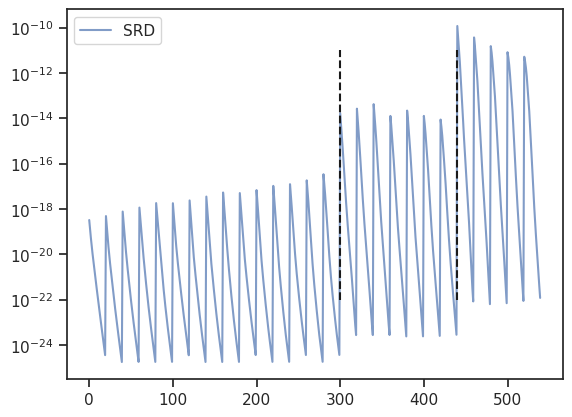

In [63]:
plt.plot(np.diag(SRD_compare), alpha = 0.7, label ="SRD")
#plt.plot(np.diag(gauss_cov_rotated), alpha = 0.7, label ="mine")
plt.plot([15*ell_bin_num_mockdata,15*ell_bin_num_mockdata],[1e-22,1e-11],"k--")
plt.plot([22*ell_bin_num_mockdata,22*ell_bin_num_mockdata],[1e-22,1e-11],"k--")
plt.yscale("log")
plt.legend()

(540, 540)


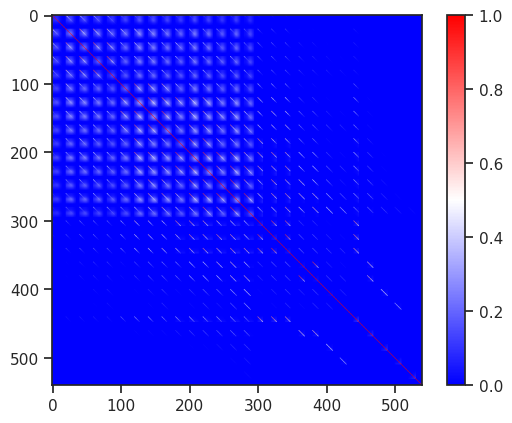

In [64]:
corr2 = cov2corr(SRD_compare)
print(corr2.shape)
plt.imshow(corr2, origin='upper', cmap='bwr')

plt.colorbar()
plt.show()
# kk, delk, deldel

## 4d. Apply scale cuts

In [65]:
"""Get list of lists rather than 1d array for non-uniform ell spacing"""

def ell_arrayfromlist(list):
    list_new = [[]]
    idx = 0
    for i in range(len(list)):
        if list[(i+1) % (len(list))] <= list[i]:
            list_new[idx].append(list[i])
            idx += 1
            list_new.append([])
        else:
            list_new[idx].append(list[i])
    del list_new[-1]
    return list_new



### Get data for linear scale cuts

In [66]:
# TO DO EXPLICITLY
"""
def linear_scale_cuts(ell, dvec_nl, dvec_lin, cov):
    # Function from Danielle.
    #Gets the scales (and vector indices) which are excluded if we
    #are only keeping linear scales. We define linear scales such that 
    #chi^2_{nl - lin) <=1.
    #dvec_nl: data vector from nonlinear theory 
    #dvec_lin: data vector from linear theory
    #cov: data covariance
    
    # Make a copy of these initial input things before they are changed,
    # so we can compare and get the indices
    dvec_nl_in = dvec_nl; dvec_lin_in = dvec_lin; cov_in = cov;
    
    # Check that data vector and covariance matrices have consistent dimensions.
    if ( (len(dvec_nl)!=len(dvec_lin)) or (len(dvec_nl)!=len(cov[:,0])) or (len(dvec_nl)!=len(cov[0,:])) or (len(dvec_nl)!=len(ell)) ):
        raise(ValueError, "in linear_scale_cuts: inconsistent shapes of data vectors and / or covariance matrix.")
    
    # Cut elements of the data vector / covariance matrix until chi^2 <=1
    inv_cov = np.linalg.pinv(cov)

    while(True):
        # Get an array of all the individual elements which would go into 
        # getting chi2
        sum_terms = np.zeros((len(dvec_nl), len(dvec_nl)))
        for i in range(len(dvec_nl)):
            for j in range(len(dvec_nl)):
                sum_terms[i,j] = (dvec_nl[i] - dvec_lin[i]) * inv_cov[i,j] * (dvec_nl[j] - dvec_lin[j])
    
            #print "sum_terms=", sum_terms
            #print "chi2=", np.sum(sum_terms)
            # Check if chi2<=1
        if (np.sum(sum_terms)<=1.0):
            break
        else:
            # Get the indices of the largest value in sum_terms.
            inds_max = np.unravel_index(np.argmax(sum_terms, axis=None), sum_terms.shape)
            #print "inds_max =", inds_max
            # Remove this / these from the data vectors and the covariance matrix
            
            if (inds_max[0] == inds_max[1]):
                
                inv_cov[inds_max[0]] = np.zeros(len(inv_cov[inds_max[0]]))
                inv_cov[:, inds_max[0]] = np.zeros(len(inv_cov[inds_max[0]]))
            else:
                
                inv_cov[inds_max] = np.zeros(len(inv_cov[inds_max]))
                inv_cov[:, inds_max] = np.zeros(len(inv_cov[inds_max]))
    # Now we should have the final data vector with the appropriate elements cut.
    # Use this to get the rp indices and scales we should cut.
    
    ex_inds = [i for i in range(len(dvec_nl_in)) if dvec_nl_in[i] not in dvec_nl]
    
    return ell, dvec_nl, dvec_lin, inv_cov #ex_inds
"""
# First need to calculate D_mockdata_GR, D_data_lin_plot_GR

#newdat_test = linear_scale_cuts(ell_mockdata, D_mockdata_GR, D_data_lin_plot_GR, SRD_compare)
# gauss_invcov_cut = newdat_test[3]

'\ndef linear_scale_cuts(ell, dvec_nl, dvec_lin, cov):\n    # Function from Danielle.\n    #Gets the scales (and vector indices) which are excluded if we\n    #are only keeping linear scales. We define linear scales such that \n    #chi^2_{nl - lin) <=1.\n    #dvec_nl: data vector from nonlinear theory \n    #dvec_lin: data vector from linear theory\n    #cov: data covariance\n    \n    # Make a copy of these initial input things before they are changed,\n    # so we can compare and get the indices\n    dvec_nl_in = dvec_nl; dvec_lin_in = dvec_lin; cov_in = cov;\n    \n    # Check that data vector and covariance matrices have consistent dimensions.\n    if ( (len(dvec_nl)!=len(dvec_lin)) or (len(dvec_nl)!=len(cov[:,0])) or (len(dvec_nl)!=len(cov[0,:])) or (len(dvec_nl)!=len(ell)) ):\n        raise(ValueError, "in linear_scale_cuts: inconsistent shapes of data vectors and / or covariance matrix.")\n    \n    # Cut elements of the data vector / covariance matrix until chi^2 <=1\n    inv_

In [67]:
### Load and collect the data for likelihood
#npzfile = np.load("../Biases_parametrization/Data_storage_fR.npz")
#npzfile_GR = np.load("Data_storage_GR.npz")

#gauss_invcov_cut = np.matrix(npzfile_GR['Inverse_cov'])

In [68]:
"""print(gauss_invcov_rotated.shape)
plt.imshow(cov2corr(gauss_invcov_rotated), origin='upper',  cmap='bwr')

plt.colorbar()
plt.show()
"""

"print(gauss_invcov_rotated.shape)\nplt.imshow(cov2corr(gauss_invcov_rotated), origin='upper',  cmap='bwr')\n\nplt.colorbar()\nplt.show()\n"

### Get data for baryonic (nonlinear) scale cuts

#### Get OWLS AGN P(k)

In [69]:
P_k_arrays_OWLSAGN = np.loadtxt("/global/homes/c/carolazn/CuGal_Emu_project_mcmc/Pk_OWLS_AGN.txt", skiprows=1)
P_k_arrays_DMO = np.loadtxt("/global/homes/c/carolazn/CuGal_Emu_project_mcmc/Pk_OWLS_DMO.txt", skiprows=1)


In [70]:
z_OWLSAGN_mesh = P_k_arrays_OWLSAGN.T[0]
k_OWLSAGN_mesh = P_k_arrays_OWLSAGN.T[1]
z_OWLSAGN = np.unique(z_OWLSAGN_mesh)
k_OWLSAGN = np.unique(k_OWLSAGN_mesh)

Pk_OWLSAGN_mesh = P_k_arrays_OWLSAGN.T[2].reshape(len(z_OWLSAGN),len(k_OWLSAGN))
Pk_OWLSDMO_mesh = P_k_arrays_DMO.T[2].reshape(len(z_OWLSAGN),len(k_OWLSAGN))

BaryonBoost_OWLSAGN = Pk_OWLSAGN_mesh/Pk_OWLSDMO_mesh
interp_Bk_OWLSAGN = scipy.interpolate.RegularGridInterpolator((k_OWLSAGN, z_OWLSAGN), BaryonBoost_OWLSAGN.T,bounds_error=False, fill_value=1.0)


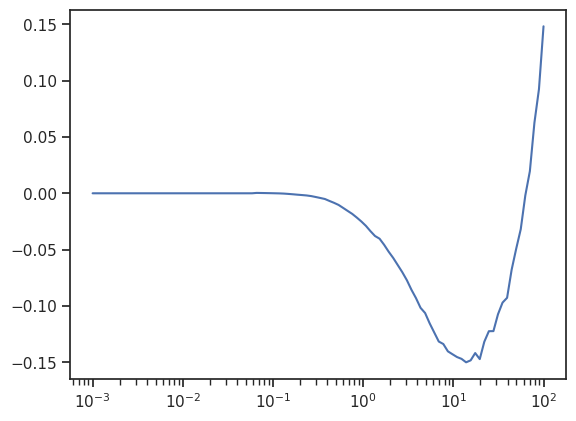

In [71]:

plt.semilogx(np.logspace(-3,2,100), np.log10(interp_Bk_OWLSAGN(np.array([np.logspace(-3,2,100),np.zeros(100)]).T)))


#### Apply cuts

In [72]:
# A: Function for cosmic shear angular power spectrum (lensing-lensing C_ell) from a given P_delta2D_S
def C_ell_arr_kk(P_delta2D_S_funct, ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution):
    C_ell_array = []
    n_zbins = int(((len(Binned_distribution_s)+1)*len(Binned_distribution_s))/2)
    # how far along z binning we are
    idx = 0
    # at what z bin we start calculating Cell
    start_idx = n_zbins - len(ell_binned)

    for j in range(len(Binned_distribution_s)):
        tracer1 = ccl.WeakLensingTracer(cosmo, dndz=(z, Binned_distribution_s[j]))
        for k in range(len(Binned_distribution_s)):
            if k >= j:
                if start_idx <= idx:
                    tracer2 = ccl.WeakLensingTracer(cosmo, dndz=(z, Binned_distribution_s[k]))
                    C_ell = ccl.angular_cl(cosmo, tracer1, tracer2, ell_binned[idx - start_idx], p_of_k_a=P_delta2D_S_funct)
                    C_ell_array.append([C_ell])
                    idx += 1
                else:
                    idx += 1
    return C_ell_array

# B: Function for galaxy-galaxy lensing angular power spectrum (clustering-lensing C_ell) from a given P_delta2D_S
def C_ell_arr_delk(P_delta2D_S_funct, ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution):
    C_ell_array = []
    
    n_zbins = 0
    for j in range(len(Binned_distribution_l)):
        for k in range(len(Binned_distribution_s)):
            if k - 1 > j or (k == 4 and j == 3):
                n_zbins += 1
                
    # how far along z binning we are
    idx = 0
    # at what z bin we start calculating Cell
    start_idx = n_zbins - len(ell_binned)

    for j in range(len(Binned_distribution_l)):
        tracer1 = ccl.NumberCountsTracer(cosmo, dndz=(z, Binned_distribution_l[j]), bias=(z, Bias_distribution[j]), has_rsd=False)
        for k in range(len(Binned_distribution_s)):
            if k - 1 > j or (k == 4 and j == 3):
                if start_idx <= idx:
                    tracer2 = ccl.WeakLensingTracer(cosmo, dndz=(z, Binned_distribution_s[k]))
                    C_ell = ccl.angular_cl(cosmo, tracer1, tracer2, ell_binned[idx - start_idx], p_of_k_a=P_delta2D_S_funct)
                    C_ell_array.append([C_ell])
                    idx += 1
                else:
                    idx += 1
    return C_ell_array

# C: Function for galaxy-galaxy clustering angular power spectrum (clustering-clustering C_ell) from a given P_delta2D_S
def C_ell_arr_deldel(P_delta2D_S_funct, ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution):
    C_ell_array = []
    n_zbins = len(Binned_distribution_l)
    # how far along z binning we are
    idx = 0
    # at what z bin we start calculating Cell
    start_idx = n_zbins - len(ell_binned)

    for j in range(len(Binned_distribution_l)):
        tracer1 = ccl.NumberCountsTracer(cosmo, dndz=(z, Binned_distribution_l[j]), bias=(z, Bias_distribution[j]), has_rsd=False)
        for k in range(len(Binned_distribution_l)):
            if k == j:
                if start_idx <= idx:
                    tracer2 = ccl.NumberCountsTracer(cosmo, dndz=(z, Binned_distribution_l[k]), bias=(z, Bias_distribution[k]), has_rsd=False)
                    C_ell = ccl.angular_cl(cosmo, tracer1, tracer2, ell_binned[idx - start_idx], p_of_k_a=P_delta2D_S_funct)
                    C_ell_array.append([C_ell])
                    idx += 1
                else:
                    idx += 1
    return C_ell_array

def Cell(ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution,P_delta2D_S,
         tracer1_type="k", 
         tracer2_type="k"):
    """
    Finds C^{i,j}(ell) for {i,j} redshift bins.
    tracer_type = "k", "g"
    linear = True, False
    gravity theory = "GR", "nDGP", "f(R)", "muSigma"
    if tracer1_type = "k" and tracer2_type = "k", shape-shape angular power spectrum
    if tracer1_type = "k" and tracer2_type = "g", galaxy-galaxy lensing angular power spectrum
    if tracer1_type = "g" and tracer2_type = "g", pos-pos angular power spectrum
    if linear=True, use linear matter power spectrum to compute the angular one, otherwise use the non-linear
    input:
        ell_binned: array of ell bins for the full C{ij}(ell) range (for all i and j), with scale cuts included
        cosmo: ccl cosmology object
        redshift z: numpy.array with dim:N
        Binned_distribution_s: numpy.array with dim:(N,M) (M = no. source z bins)
        Binned_distribution_l: numpy.array with dim:(N,L) (L = no. lens z bins)
        Bias_distribution: numpy.array with dim:(N,L) (galaxy bias)
        pk_F: function (cosmo, MGParams, k,a) for k (in 1/Mpc), returns matter power spectrum (in Mpc^3)
        MGParams: 
    returns:
        ell bins: numpy.array (dim = dim C_ell)
        C_ell: numpy.array
    """

    ops = {
        ("k" , "k"): C_ell_arr_kk,
        ("k" , "g"): C_ell_arr_delk, 
        ("g" , "k"): C_ell_arr_delk,
        ("g" , "g"): C_ell_arr_deldel
    }

    def invalid_op2():
        raise ValueError('invalid tracer selected.')
    ########## Find Cell ##########

    C_ell_array_funct = ops.get((tracer1_type, tracer2_type), invalid_op2)
    C_ell_array = C_ell_array_funct(P_delta2D_S, ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution)

    return np.array(list(itertools.chain(*ell_binned))), C_ell_array

In [73]:
"""Define functions to apply baryonic cuts"""
def Get_Pk2D_obj_OWLSAGN(cosmo,linear=False,gravity_model="GR"):

    ########### Functions for non-linear matter power spectrum multiplied by Sigma**2 ###########
    def pk_funcSigma2_GR_NL(k, a):
        
        if isinstance(a, (float, int)):  # Single scale factor case
            pk = ccl.nonlin_matter_power(cosmo, k=k, a=a) * interp_Bk_OWLSAGN(np.array([k, np.ones(len(k))*(1.0/a - 1.0)]).T)
        else:
            k_mesh, z_mesh = np.meshgrid(k,1.0/a - 1.0)

            # Calculate power spectra for different k ranges
            pk = ccl.nonlin_matter_power(cosmo, k=k, a=a) * interp_Bk_OWLSAGN(k_mesh, z_mesh)
                
        return pk
       
    ########### Functions for linear matter power spectrum multiplied by Sigma**2 ###########
    def pk_funcSigma2_GR_lin(k, a):
        
        if isinstance(a, (float, int)):  # Single scale factor case
            pk = ccl.linear_matter_power(cosmo, k=k, a=a) * interp_Bk_OWLSAGN(np.array([k, np.ones(len(k))*(1.0/a - 1.0)]).T)
        else:
            k_mesh, z_mesh = np.meshgrid(k,1.0/a - 1.0)

            # Calculate power spectra for different k ranges
            pk = ccl.linear_matter_power(cosmo, k=k, a=a) * interp_Bk_OWLSAGN(k_mesh, z_mesh)
                
        return pk

    def invalid_op(k, a):
        raise Exception("Invalid gravity model entered or Linear must be True or False.")

    ops = {
        ("GR" , False): pk_funcSigma2_GR_NL,
        ("GR" , True): pk_funcSigma2_GR_lin
    }
    
    ########### Find matter power spectrum multiplied by Sigma**2 ###########
    pk_funcSigma2 = ops.get((gravity_model, linear), invalid_op)

    return ccl.pk2d.Pk2D.from_function(pkfunc=pk_funcSigma2, is_logp=False)




In [74]:
def baryonic_scale_cuts(cosmo, ell, dvec_full, dvec_shear, dvec_kmax, cov_full):
    """ 
    Modified function from Danielle.
    Gets the scales (and vector indices) which are excluded if we
    are only keeping non-baryonic scales. We define these scales such that 
    chi^2_{baryonic - DMO) <=1.
    dvec_full: full data vector from baryonic theory 
    dvec_shear: shear data vector from baryonic theory 
    dvec_kmax: shear data vector from DMO theory
    cov_full: full data covariance, shear components come first
    derived    cov: shear data covariance. """
    
    # Make a copy of these initial input things before they are changed,
    # so we can compare and get the indices
    dvec_full_in = dvec_full; dvec_shear_in = dvec_shear; dvec_kmax_in = dvec_kmax; cov_in = cov_full;
	
	#### first cuts - clustering ######
    
    # for galaxy-galaxy lensing (size=91) bins=(02 , 03 , 04 , 13 , 14 , 24 , 34)
    # for galaxy-galaxy (size=65) bins=(00 , 11 , 22 , 33 , 44)
    
    k_max = 0.3 # h/Mpc
    delk_z_array = np.array([0.30,0.30,0.30,0.50,0.50,0.70,0.70])
    deldel_z_array = np.array([0.30,0.50,0.70,0.90,1.10])
    z_array = np.append(delk_z_array, deldel_z_array)
    chi = ccl.background.comoving_radial_distance(cosmo, 1/(z_array+1))
    ellmax = k_max * chi - 0.5
    
    starting_index = len(dvec_shear)
    len_ell_ranges = int((len(cov_full[0]) - len(dvec_shear))/len(z_array))
    idx_count = 0
    for j in range(len(z_array)):
        for i in range(len_ell_ranges):
            if ell[starting_index + i] >= ellmax[j]:
                cov_full = np.delete(np.delete(cov_full, starting_index + j*len_ell_ranges + i - idx_count, axis=0), starting_index + j*len_ell_ranges + i - idx_count, axis=1)
                dvec_full = np.delete(dvec_full, starting_index + j*len_ell_ranges + i - idx_count)
                idx_count +=1
    
    #### second cuts - lensing ######
    cov = cov_full[:len(dvec_shear), :len(dvec_shear)]
    
    while(True):
		
        # Get an array of all the individual elements which would go into 
        # getting chi2
        #sum_terms = np.zeros((len(dvec_shear), len(dvec_shear)))
        #for i in range(0,len(dvec_shear)):
        #    for j in range(0,len(dvec_shear)):
        #        sum_terms[i,j] = (dvec_shear[i] - dvec_kmax[i]) * inv_cov[i,j] * (dvec_shear[j] - dvec_kmax[j])
				
        #print("sum_terms=", sum_terms)
        #print("chi2=", np.sum(sum_terms))
        # Check if chi2<=1		
        
        # Get the chi2 in the case where you cut each data point
        # and then actually cut the one that reduces the chi2
        # the most
        chi2_temp = np.zeros(len(dvec_shear))
        for i in range(len(dvec_shear)):
            delta_dvec = np.delete(dvec_shear, i) - np.delete(dvec_kmax, i)
            cov_cut = np.delete(np.delete(cov,i, axis=0), i, axis=1)
            inv_cov_cut = np.linalg.pinv(cov_cut)
            chi2_temp[i] = np.dot(delta_dvec, np.dot(inv_cov_cut, delta_dvec))
            #sum_temp[i] = np.sum(np.delete(np.delete(sum_terms, i, axis=0), i, axis=1))
        print('chi2_temp=', chi2_temp)
            
        #Find the index of data point that is cut to produce the smallest chi2:
        ind_min = np.argmin(chi2_temp)
            
        # Cut that element
        dvec_shear = np.delete(dvec_shear, ind_min)
        dvec_kmax = np.delete(dvec_kmax, ind_min)
        cov = np.delete(np.delete(cov, ind_min, axis=0), ind_min, axis=1)
        dvec_full = np.delete(dvec_full, ind_min)

        if (chi2_temp[ind_min]<=1.0):
            break
				
    # Now we should have the final data vector with the appropriate elements cut.
    # Use this to get the rp indices and scales we should cut.
    cov_full[:len(dvec_shear), :len(dvec_shear)] = cov
    
    ex_inds = [i for i in range(len(dvec_full_in)) if dvec_full_in[i] not in dvec_full]
    print('ex_inds=', ex_inds)
	
    return ex_inds

In [75]:
def baryonic_scale_cuts(cosmo, ell, dvec_full, dvec_shear, dvec_kmax, cov_full):
    """ 
    Modified function from Danielle.
    Gets the scales (and vector indices) which are excluded if we
    are only keeping non-baryonic scales.
    """

    # Save originals for index comparison
    dvec_full_in = dvec_full.copy()
    dvec_shear_in = dvec_shear.copy()
    dvec_kmax_in = dvec_kmax.copy()
    cov_in = cov_full.copy()

    #### first cuts - clustering ######

    k_max = 0.3  # h/Mpc
    delk_z_array = np.array([0.30,0.30,0.30,0.50,0.50,0.70,0.70])
    deldel_z_array = np.array([0.30,0.50,0.70,0.90,1.10])
    z_array = np.append(delk_z_array, deldel_z_array)

    chi = ccl.background.comoving_radial_distance(cosmo, 1/(z_array+1))
    ellmax = k_max * chi - 0.5

    starting_index = len(dvec_shear)
    len_ell_ranges = int((len(cov_full[0]) - len(dvec_shear)) / len(z_array))
    idx_count = 0

    for j in range(len(z_array)):
        for i in range(len_ell_ranges):
            if ell[starting_index + i] >= ellmax[j]:
                cut_ind = starting_index + j*len_ell_ranges + i - idx_count
                cov_full = np.delete(np.delete(cov_full, cut_ind, axis=0), cut_ind, axis=1)
                dvec_full = np.delete(dvec_full, cut_ind)
                idx_count += 1

    #### second cuts - lensing (NEW: hard ell cut) ######

    ell_cut = 3000

    # Indices (within lensing block) to remove
    lensing_inds_to_cut = np.where(ell[:len(dvec_shear)] > ell_cut)[0]

    # Apply cuts
    dvec_shear = np.delete(dvec_shear, lensing_inds_to_cut)
    dvec_kmax  = np.delete(dvec_kmax,  lensing_inds_to_cut)
    dvec_full  = np.delete(dvec_full,  lensing_inds_to_cut)

    cov_full = np.delete(np.delete(cov_full,
                                   lensing_inds_to_cut, axis=0),
                                   lensing_inds_to_cut, axis=1)

    #### get excluded indices ######

    ex_inds = [i for i in range(len(dvec_full_in))
               if dvec_full_in[i] not in dvec_full]

    print('ex_inds=', ex_inds)
    return ex_inds


In [76]:
"""Get mock C(ell) data"""

## LENSING - LENSING

binned_ell = bin_ell_kk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata, Binned_distribution_source)

# find C_ell for non-linear matter power spectrum
mockdata = Cell_GR(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,\
                tracer1_type="k", tracer2_type="k")

ell_kk_mockdata = mockdata[0]
D_kk_mockdata_test = mockdata[1]
D_kk_mockdata_test = (np.array(D_kk_mockdata_test)).flatten()

print(D_kk_mockdata_test.shape)
del mockdata

"""Get mock C(ell, k_max) data"""

## LENSING - LENSING

binned_ell = bin_ell_kk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata, Binned_distribution_source)

# find C_ell for non-linear matter power spectrum
mockdata = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,\
                Get_Pk2D_obj_OWLSAGN(cosmo_universe, linear=False, gravity_model="GR"),tracer1_type="k", tracer2_type="k")

ell_kk_mockdata = mockdata[0]
D_kk_mockdata_kmax = mockdata[1]
D_kk_mockdata_kmax = (np.array(D_kk_mockdata_kmax)).flatten()

print(D_kk_mockdata_kmax.shape)
del mockdata



(300,)
(300,)


In [77]:
"""Get new Mock data with cuts in ell"""
##### FOR NOW ONLY #####
#print(SRD_compare.shape)
#print(D_kk_mockdata_test.shape)

newdat = baryonic_scale_cuts(cosmo_universe, ell_mockdata,D_mockdata, D_kk_mockdata_test, D_kk_mockdata_kmax, SRD_compare)


ex_inds= [15, 16, 17, 18, 19, 35, 36, 37, 38, 39, 55, 56, 57, 58, 59, 75, 76, 77, 78, 79, 95, 96, 97, 98, 99, 115, 116, 117, 118, 119, 135, 136, 137, 138, 139, 155, 156, 157, 158, 159, 175, 176, 177, 178, 179, 195, 196, 197, 198, 199, 215, 216, 217, 218, 219, 235, 236, 237, 238, 239, 255, 256, 257, 258, 259, 275, 276, 277, 278, 279, 295, 296, 297, 298, 299, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 411, 412, 413, 414, 415, 416, 417, 418, 419, 431, 432, 433, 434, 435, 436, 437, 438, 439, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 491, 492, 493, 494, 495, 496, 497, 498, 499, 512, 513, 514, 515, 516, 517, 518, 519, 532, 533, 534, 535, 536, 537, 538, 539]


In [78]:
gauss_invcov_rotated = np.linalg.pinv(SRD_compare)
    
for i in range(len(newdat)):
    gauss_invcov_rotated[newdat[i]] = np.zeros(len(gauss_invcov_rotated[0]))
    gauss_invcov_rotated[:,newdat[i]] = np.zeros(len(gauss_invcov_rotated[0]))
    

/tmp/ipykernel_1698115/3468767144.py:10: RuntimeWarning: invalid value encountered in divide
  return cov/np.outer(sig, sig)


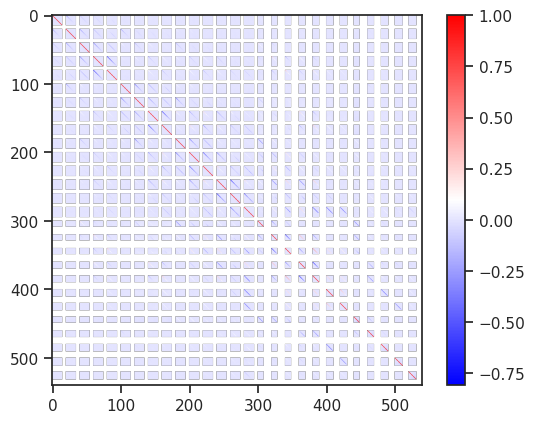

In [79]:
#print(newdat[3].shape)
plt.imshow(cov2corr(gauss_invcov_rotated), origin='upper',  cmap='bwr')

plt.colorbar()
plt.show()


## 4f. Package data

In [80]:
# WITHOUT NOISE
C_ell_data_mock = [D_mockdata, ell_mockdata, z,  Binned_distribution_source,\
                   Binned_distribution_lens, ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata]

#Data_fsigma8 = [z_eff, fsigma_8_data, invcov_fsigma8]
# WITH NOISE
#C_ell_data_mock = [D_mockdata_noise, ell_mockdata, z, Binned_distribution, ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata]




# 6. Likelihood function

In [81]:
# log likelihood - only baryonic cuts applied
def loglikelihood(Data, cosmo, f_phi, InvCovmat, Bias_distribution):
    #start = time.time()
    
    # Extract fsigma8 data vector
    #z_fsigma8, fsigma_8_dataset, invcovariance_fsigma8 = data_fsigma8
    
    # Extract 3x2pt data vector
    D_data, ell_mockdata, z, Binned_distribution_s,Binned_distribution_l,\
                   ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata = Data

    # Initialize CuGal stuff
    a_setup_mcmc, UE_setup_mcmc, coupling_setup_mcmc = CuGal_initialize(f_phi, cosmo)
    P_delta2D_GR_lin_mcmc = Get_Pk2D_obj_kk_GR_lin(cosmo)
    P_delta2D_GR_nl_mcmc = Get_Pk2D_obj_kk_GR_nl(cosmo)
    # shape-shape
    binned_ell_kk = bin_ell_kk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata, Binned_distribution_s)

    # shape-pos
    binned_ell_delk = bin_ell_delk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata, \
                              Binned_distribution_s,Binned_distribution_l)

    # pos-pos
    binned_ell_deldel = bin_ell_deldel(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata, Binned_distribution_l)

    
    ########## Get theoretical data vector for single MCMC step - linear , muSigmaparam ##########
    # shape-shape
    D_theory_kk = np.array(Cell_CuGal(binned_ell_kk,a_setup_mcmc, UE_setup_mcmc, coupling_setup_mcmc,f_phi,cosmo, z , Binned_distribution_s,Binned_distribution_l,\
                      Bias_distribution,P_delta2D_GR_nl_mcmc, tracer1_type="k", tracer2_type="k")[1]).flatten()
   
    # shape-pos
    
    D_theory_delk = np.array(Cell_CuGal(binned_ell_delk,a_setup_mcmc, UE_setup_mcmc, coupling_setup_mcmc,f_phi,cosmo, z , Binned_distribution_s,Binned_distribution_l,\
                      Bias_distribution,P_delta2D_GR_nl_mcmc, tracer1_type="g", tracer2_type="k")[1]).flatten()

    # pos-pos

    D_theory_deldel = np.array(Cell_CuGal(binned_ell_deldel,a_setup_mcmc, UE_setup_mcmc, coupling_setup_mcmc,f_phi,cosmo, z , Binned_distribution_s,Binned_distribution_l,\
                      Bias_distribution,P_delta2D_GR_nl_mcmc, tracer1_type="g", tracer2_type="g")[1]).flatten()


    D_theory = np.append(np.append(D_theory_kk, D_theory_delk), D_theory_deldel)
    
    Diff = (D_data - D_theory)

    #print("time = ", time.time() - start)
    #### fsigma8 ####
    #Diff_fsigma8 = fsigma_8_dataset - fsigma8_CuGal(P_delta2D_GR_lin_mcmc,a_setup_mcmc, UE_setup_mcmc, coupling_setup_mcmc,f_phi,cosmo, 1/(z_fsigma8+1))
    #loglik_fsigma8 = -0.5*(np.matmul(np.matmul(Diff_fsigma8,invcovariance_fsigma8),Diff_fsigma8))

    return -0.5*(np.matmul(np.matmul(Diff,InvCovmat),Diff)) #+ loglik_fsigma8 

In [82]:
%%time
# Check this is very small
lik_1_test = (loglikelihood(C_ell_data_mock, cosmo_universe, 1.0, gauss_invcov_rotated,Bias_distribution_fiducial))

CPU times: user 1.59 s, sys: 1.66 ms, total: 1.59 s
Wall time: 1.59 s


# 8. Run the MCMC - compare different methods

In [83]:
#### Get Planck priors #####
sampler_Planck_arr = np.load("/global/homes/c/carolazn/CuGal_Emu_project_mcmc/Prior_Planck_arr.npy")
mu_prior = [cosmo_universe['n_s'], cosmo_universe["Omega_b"]*cosmo_universe["h"]**2]
cov_prior = np.cov(sampler_Planck_arr.T)

### Run MCMC

In [84]:
def log_likelihood(theta, Data, invcovmat):
    Omega_c, f_phi, A_s1e9, h, n_s, wb, b1, b2, b3, b4, b5 = theta 
    Bias_distribution = np.array([b1*np.ones(len(z)),
                             b2*np.ones(len(z)),
                             b3*np.ones(len(z)),
                             b4*np.ones(len(z)),
                             b5*np.ones(len(z))])
    #h = cosmo_universe["h"]
    #A_s = cosmo_universe["A_s"]
    A_s = A_s1e9*1e-9
    #n_s = cosmo_universe["n_s"]

    cosmoMCMCstep = ccl.Cosmology(Omega_c = Omega_c, 
                      Omega_b = wb/h**2,
                      h = h,
                      n_s = n_s,
                      A_s = A_s)
    return loglikelihood(Data, cosmoMCMCstep, f_phi, invcovmat, Bias_distribution)

In [85]:
def log_prior(theta):
    Omega_c, f_phi, A_s1e9, h, n_s, wb, b1, b2, b3, b4, b5 = theta 

    #flat priors
    if not (0.06 < Omega_c*h**2 < 0.46 and 0.0 < f_phi < 1.0 and 1.45 < A_s1e9 < 3.3 and 0.85 < n_s < 1.1 \
            and 0.61 < h < 0.73 and 0.04 < wb/h**2 < 0.06 and 0.8 < b1 < 3.0 and 0.8 < b2 < 3.0 \
           and 0.8 < b3 < 3.0 and 0.8 < b4 < 3.0 and 0.8 < b5 < 3.0):
        return -np.inf
        
    gauss_funct = scipy.stats.multivariate_normal(mu_prior, cov_prior)
    
    return gauss_funct.logpdf([n_s, wb])


In [86]:
def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, C_ell_data_mock, gauss_invcov_rotated)

In [ ]:
# Set the random seed for reproducibility
np.random.seed(10)

# Initialize the walkers
Omega_c_est = cosmo_universe["Omega_c"]
h_est = cosmo_universe["h"]
A_s1e9_est = cosmo_universe["A_s"]*1e9
n_s_est = cosmo_universe["n_s"]
f_phi_est = 0.9
wb_est = 0.0223
b1_est = Bias_distribution_fiducial[0][0]
b2_est = Bias_distribution_fiducial[1][0]
b3_est = Bias_distribution_fiducial[2][0]
b4_est = Bias_distribution_fiducial[3][0]
b5_est = Bias_distribution_fiducial[4][0]

n_steps = 15000
chain_len = 100
converged = False
nwalkers = multiprocessing.cpu_count()

# Initialize the walkers
pos = [Omega_c_est, f_phi_est, A_s1e9_est, h_est, n_s_est, wb_est,b1_est,b2_est,b3_est,b4_est,b5_est] \
+ np.append(np.append(1e-3 * np.random.randn(nwalkers, 4), 1e-5*np.random.randn(nwalkers, 2), axis = 1), \
            1e-3 * np.random.randn(nwalkers, 5), axis = 1)

nwalkers, ndim = pos.shape
print(nwalkers, ndim)

# Create the output directory and set up the HDF5 backend
mcmc_dir = "/global/homes/c/carolazn/CuGal_Emu_project_mcmc/mcmc"
filename = mcmc_dir + "/mcmc_CubicGalileon_3x2ptonly_notemu_2026_validation_ECOSMOG.h5"
backend = emcee.backends.HDFBackend(filename)

# Optionally reset the backend if starting a new run
#backend.reset(nwalkers, ndim)

with Pool(multiprocessing.cpu_count()) as pool:
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, backend=backend, pool=pool)
    pos = sampler.get_last_sample() if backend.iteration > 0 else pos

    while not converged:
        gc.collect(generation=0)
        sampler.run_mcmc(pos, chain_len, progress=True, store=True)
        
        # Clear references in the worker pool
        pool.close()
        pool.join()
        del pool  # Ensure the pool object is removed
        gc.collect()  # Collect any lingering garbage
        pool = Pool(multiprocessing.cpu_count())
        sampler.pool = pool
        pos = sampler.get_last_sample() if backend.iteration > 0 else pos
        
        # Check convergence
        try:
            tau = sampler.get_autocorr_time(tol=0)
            converged = np.all(tau * 100 < sampler.iteration)
        except emcee.autocorr.AutocorrError:
            pass

256 11


 83%|████████▎ | 83/100 [12:14<02:30,  8.88s/it]

# Old Code

In [ ]:

"""radial kernel - shear"""
"""
def q_kappa_CuGal(i, cosmo, MGparams, z, Binned_distribution_s):
    c = 3e5
    zmax = 4
    a = np.logspace(np.log10(1/(1+zmax)),np.log10(1), int(100)) 
    z_var = 1 / a - 1  # Find useful functs of z
    
    # Precompute comoving radial distance for a grid of 'a' values (for zp and ap)
    ap_grid = np.logspace(np.log10(1 / (1 + zmax + 1)), np.log10(1), int(5e2))   # Grid of 'ap' values
    chip_grid = comoving_radial_dist_CuGal(cosmo, ap_grid)  # Compute comoving distance once for the grid

    # Create an interpolation function for comoving radial distance
    chip_interp = scipy.interpolate.interp1d(ap_grid, chip_grid, kind='cubic', fill_value=0.0)

    # Precompute comoving radial distance for 'a' values
    chiz = comoving_radial_dist_CuGal(cosmo, a)  # units of Mpc

    q_kappa_array = []

    for k in range(len(z_var)):
        zp = np.linspace(z_var[k] + 1e-3,zmax,int(50))                                # variable we integrate over
        ap = 1 / (1 + zp)

        # Use the precomputed interpolation for comoving radial distance
        chip = chip_interp(ap)
        
        # Interpolate n_p
        n_p = np.interp(zp, z, Binned_distribution_s[i])

        # Compute the integrand using np.where for vectorized conditional calculation
        integrand = n_p * chiz[k] * (chip - chiz[k]) / (a[k] * chip)

        # Integrate using simpson's rule
        q_k = scipy.integrate.simps(integrand, zp) * 3 * cosmo['Omega_m'] * (cosmo['H0']**2) / (2 * c * c)
        q_kappa_array.append(q_k)

    return np.array(q_kappa_array).reshape(len(q_kappa_array))
"""
"""radial kernel - galaxy clustering"""
"""
def q_delta_CuGal(i, cosmo,MGparams, z, Binned_distribution_l,Bias_distribution):
    
    # takes in the cosmology
    # finds radial kernel for the n_{i}th bin of the lens redshift distribution
    c=3e5
    zmax = 4
    a = np.logspace(np.log10(1/(1+zmax)),np.log10(1), int(100)) 
    z_var = 1/a -1 #np.linspace(0.001, 4., int(1e2))                              # find useful functs of z
    #a = 1/(1 + z_var)
    
    chiz = comoving_radial_dist_CuGal(cosmo, a)                  # units of Mpc
    dzdchi = E_CuGal(f_phi,cosmo, a) * cosmo['H0'] / c
    n_p = np.interp(z_var, z , Binned_distribution_l[i])
    
    q_del = dzdchi * np.interp(z_var, z ,Bias_distribution[i]) * n_p

    return np.array(q_del).reshape(len(q_del))
"""

### Get cov for Cell given cov P(k)

In [219]:
def Boost_error(cosmo, MGparams, k, a):
    Boost_err_interp = np.loadtxt('/global/homes/c/carolazn/CuGal_Emu_project_Sprint2024/DeltaB_0.txt', skiprows=1).T

    Boost_error_0 = np.interp(k, Boost_err_interp[0],Boost_err_interp[1])
    
    H0rc, fR0, n, f_phi, mu, Sigma = MGparams

    pkratio_CuGal = P_k_NL_CuGal(cosmo, MGparams, k, a)/ccl.power.nonlin_power(cosmo, k, a=a)
    pkratio_CuGal_zero = P_k_NL_CuGal(cosmo, MGparams, k, 1.0)/ccl.power.nonlin_power(cosmo, k, a=1.0)
    """
    input_params_and_redshift = np.append(
            np.array([cosmo["Omega_m"], cosmo["n_s"], 1e9 * cosmo["A_s"], cosmo["h"], f_phi]),
            0.0)
    bk_target, err_target = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list, z_all)
    interp_func = scipy.interpolate.interp1d(k_all * cosmo["h"], bk_target.flatten(), kind='linear', fill_value="extrapolate")
    pkratio_CuGal_zero = interp_func(k)
    
    if isinstance(a, (float, int)):  # Single scale factor case
        input_params_and_redshift = np.append(
            np.array([cosmo["Omega_m"], cosmo["n_s"], 1e9 * cosmo["A_s"], cosmo["h"], f_phi]),
            1.0 / a - 1.0
        )
        bk_target, err_target = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list, z_all)
        interp_func = scipy.interpolate.interp1d(k_all * cosmo["h"], bk_target.flatten(), kind='linear', fill_value="extrapolate")
        pkratio_CuGal = interp_func(k)
        
    else:
        bk_target = []
        z_range = 1.0 / a - 1.0  # Array of redshift values

        # Loop over each redshift value
        for z_val in z_range:
            input_params_and_redshift = np.append(
                np.array([cosmo["Omega_m"], cosmo["n_s"], 1e9 * cosmo["A_s"], cosmo["h"], f_phi]),
                z_val
            )
            bk_target_i, _ = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list, z_all)
            bk_target.append(bk_target_i.flatten()) 
    
        # Convert list to array with shape (len(a), len(k_all))
        bk_target = np.array(bk_target)

        # Interpolating each row in bk_target over k
        pkratio_CuGal = np.array([
            scipy.interpolate.interp1d(k_all * cosmo["h"], bk_row, kind='linear', fill_value="extrapolate")(k) 
            for bk_row in bk_target
        ])

    """
    err = Boost_error_0 * (pkratio_CuGal - 1)/(pkratio_CuGal_zero - 1)

    return (pkratio_CuGal - 1)/(pkratio_CuGal_zero - 1)

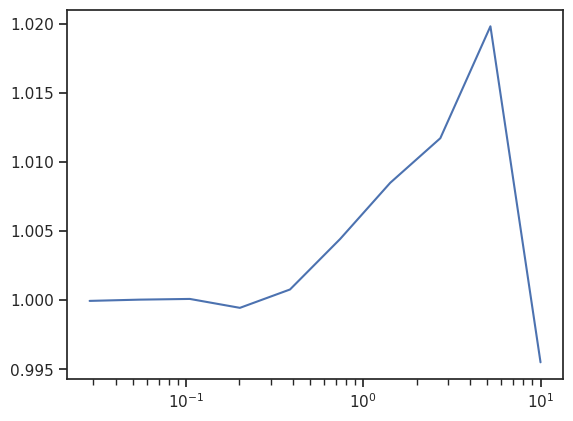

In [220]:
k_test = np.logspace(np.log10(2e-2/0.7), np.log10(7/0.7), 10)
err_test = Boost_error(cosmo_testing, [0, 0, 0, 1.0, 0,0],k_test, 1.0)
#testing_Pk = P_k_NL_CuGal(cosmo_testing, [0, 0, 0, 1.0, 0,0],  k_test, 1.0)/ccl.power.nonlin_power(cosmo_testing, k_test, a=1.0)
#testing_Pk0 = P_k_NL_CuGal(cosmo_testing, [0, 0, 0, 1.0, 0,0],  k_test, 1.0)/ccl.power.nonlin_power(cosmo_testing, k_test, a=1.0)
plt.semilogx(k_test, err_test)
#plt.semilogx(k_test, (testing_Pk - 1)/(testing_Pk0 - 1))
#plt.loglog(k_test, testing_Pk)
#plt.loglog(k_test, testing_Pk0)
#plt.semilogx(np.array([2e-2/0.7,1.2e-1/0.7, 4.5e-1/0.7,2/0.7,7/0.7]), np.array([1.001, 1.02, 1.0, 0.9,0.91]), "r")

In [306]:
# NL matter power spectra in CG

def P_k_NL_CuGal_witherror(cosmo, MGparams, k, a):
    """
    input k (array) -> wavevector, units 1/Mpc
    input a (float) -> scale factor (1/(1+z))
    input cosmo (cosmology object) -> Cosmology object from CCL
    input MGparams (array) -> Modified gravity parameters ([Omega_rc, fR0, n, mu])
    
    output Pk_fR (array) -> Nonlinear matter power spectrum for Hu-Sawicki fR gravity, units (Mpc)^3
    """
    H0rc, fR0, n, f_phi, mu, Sigma = MGparams

    input_params_and_redshift = np.append(np.array([cosmo["Omega_m"],cosmo["n_s"],1e9*cosmo["A_s"],cosmo["h"],f_phi]) , 1.0/a -1.0)     
    bk_target, err_target = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list, z_all)
    pkratio_CuGal = np.interp(k, k_all*cosmo["h"], bk_target.reshape(len(k_all)))

    ## get cov
    """
    k_interp, k_interp = np.meshgrid(k, k, indexing='ij', sparse=True)
    cov_CuGal_interp = scipy.interpolate.RegularGridInterpolator((k_interp, k_interp), err_target.reshape(len(k_all),len(k_all)))
    pts = np.meshgrid(k_all*cosmo["h"], k_all*cosmo["h"], indexing='ij', sparse=True)
    cov_CuGal = cov_CuGal_interp(pts)
    """
    Pk_ccl = ccl.power.nonlin_power(cosmo, k, a=a) # units (Mpc)^3
    Pk = pkratio_CuGal*Pk_ccl
    if isinstance(k, (float, int)) and isinstance(a, (float, int)):  # Check for float or int
        cov_temp = (Pk*0.05)**2
    else:
        cov_temp = np.diag((Pk*0.03)**2)

    return Pk, cov_temp

In [ ]:

pk_test = P_k_NL_CuGal_witherror(cosmo_testing, [0.0,0,0,1.0,0,0], k_all, 1)

plt.imshow(pk_test[1], origin='upper', cmap='bwr', norm=LogNorm(vmin=1e1, vmax=1e3))

plt.colorbar()
plt.show()


In [ ]:

def findCovCell_kk_CuGal(i,j, cosmo,MGparams, z, ell, Binned_distribution_s, Binned_distribution_l,Bias_distribution):

    c = 3e5
    zmax = 4
    a = np.logspace(np.log10(1/(1+zmax)),np.log10(1), int(100)) 
    z_var = 1/a -1 #np.linspace(0.001, 4., int(1e2))                              # find useful functs of z

    chiz = comoving_radial_dist_CuGal(cosmo, a) + 1e-3
    q_k_val_i = q_kappa_CuGal(i, cosmo,MGparams, z, Binned_distribution_s)          # find tomographic lens efficiency
    q_k_val_j = q_kappa_CuGal(j, cosmo,MGparams, z, Binned_distribution_s)          # find tomographic lens efficiency

    # In Cubic Galileon, Sigma = mu
    Sigma_val = mu_CuGal(MGparams, a)
    
    integrand_term = -Sigma_val**2 * q_k_val_i*q_k_val_j/E_CuGal(cosmo, a)/chiz**2/cosmo['H0'] * c

    C_ell = []
    C_ell_cov = []
    for k in range(len(ell)):
        Pk = []
        err = []
        for m in range(len(a)):
            P_k_CG, cov_CG = P_k_NL_CuGal_witherror(cosmo, MGparams, (ell[k] + 0.5)/chiz[m], a[m])
            Pk.append(P_k_CG)
            err.append(cov_CG)
        
        integrand = integrand_term*np.array(Pk).reshape(len(a))
        integrand_cov = -integrand_term*integrand_term*np.array(err).reshape(len(a))
        C_ell.append([scipy.integrate.simps(integrand, z_var)])
        C_ell_cov.append([scipy.integrate.simps(integrand_cov, z_var)])

    return np.array(C_ell), np.array(C_ell_cov).reshape(len(C_ell_cov))
    
"""
    C_ell = []
    for k_1 in range(len(ell)):
        for k_2 in range(len(ell)):
            
            Pk_1 = []
            Pk_2 = []
            covPk = np.zeros(len(a), len(a))
      
            for zdash in range(len(a)):
                Pk_CG_1, cov_dummy = P_k_NL_CuGal_witherror(cosmo, MGparams, (ell[k_1] + 0.5)/chiz[zdash], a[zdash])
                Pk_CG_2, cov_dummy = P_k_NL_CuGal_witherror(cosmo, MGparams, (ell[k_2] + 0.5)/chiz[zdash], a[zdash])
                Pk_dummy, covPk_CG_2 = P_k_NL_CuGal_witherror(cosmo, MGparams, (ell[k_2] + 0.5)/chiz[zdash], a[zdash])
                
                if k_1==k_2:
                    covPk[k_1,k_2] = (covPk_CG_1)
                Pk_2.append(Pk_CG_2)
                covPk_2.append(covPk_CG_2)
    
            for zdash in range(len(a)):
                for zbar in range(len(a)):
                    covPk[zdash]*
            integrand = integrand_term*np.array(Pk).reshape(len(a))
            C_ell.append([scipy.integrate.simps(integrand, z_var)])
            
    return np.array(C_ell)

"""

In [201]:
Cell, cov = findCovCell_kk_CuGal(0,0, cosmo_testing,[0, 0, 0, 1.0, 0,0], z, bins(20, 1478.5, 13), Binned_distribution_source, Binned_distribution_lens,Bias_distribution_fiducial)
#initialize_cosmology_CuGal(cosmo_testing, [0, 0, 0, 1.0, 0,0])
#Cell = findC_ell_deldel_CuGal(0,0, cosmo_testing, [0,0,0,1.0,0,0],z, bins(20, 1478.5, 13), Binned_distribution_source, Binned_distribution_lens,Bias_distribution_fiducial)


NameError: name 'findCovCell_kk_CuGal' is not defined

In [202]:
#plt.plot(bins(20, 1478.5, 13), cov)

plt.imshow(np.diag(cov), origin='upper', cmap='bwr', vmin=0, vmax=11e-19)

plt.colorbar()
plt.show()


NameError: name 'cov' is not defined

In [ ]:
cov_forplots = (SRD_compare[:13,:13])
print(cov_forplots.shape)
plt.imshow(cov_forplots, origin='upper', cmap='bwr', vmin=0, vmax=11e-19)


In [ ]:
plt.imshow(cov_forplots + np.diag(cov), origin='upper', cmap='bwr', vmin=0, vmax=11e-19)


## Find Cell for Cubic Galileon (old)

In [56]:
"""Functions to find Cell for Cubic Galileon given a Pdelta_2D ccl object"""


#### NOTE: NEED TO INITIALIZE BACKGROUND FILES FIRST FOR A GIVEN f_phi AND cosmo ######

"""Comoving radial distance in Cubic Galileon"""
def comoving_radial_dist_CuGal(cosmo, a_array):
    c = 3e5  # Speed of light in km/s
    
    # Define the redshift integral range
    #z_integral = np.linspace(1/a_array.min() - 1, 0, int(1e4))  # Use the minimum value of `a_array`
    x_integral = np.linspace(np.log(a_array.min()), 0, int(2e2)) # Compute the scale factor over the range
    a_integral = np.exp(x_integral)
    z_integral = 1/a_integral - 1
    
    # Calculate E(a_integral) only once over the entire range
    E_val = E_CuGal(cosmo, a_integral)

    # Define the integrand for each value of a
    integrand = c / (a_integral * E_val * cosmo["H0"])
    
    # Now integrate over the entire range for each value in `a_array`
    results = []
    for a_iter in a_array:
        z_lower_bound = 1/a_iter - 1  # Adjust the upper bound of the integration
        mask = (z_integral <= z_lower_bound)  # Mask the integrand for the valid integration range
        
        # Perform integration for the valid portion of the integrand
        integral = scipy.integrate.simps(integrand[mask], x_integral[mask])
        results.append(integral)

    return np.array(results)

"""radial kernel - shear"""
def q_kappa_CuGal(i, cosmo, MGparams, z, Binned_distribution_s):
    c = 3e5
    zmax = 4
    a = np.logspace(np.log10(1/(1+zmax)),np.log10(1), int(100)) 
    z_var = 1 / a - 1  # Find useful functs of z
    
    # Precompute comoving radial distance for a grid of 'a' values (for zp and ap)
    ap_grid = np.logspace(np.log10(1 / (1 + zmax + 1)), np.log10(1), int(5e2))   # Grid of 'ap' values
    chip_grid = comoving_radial_dist_CuGal(cosmo, ap_grid)  # Compute comoving distance once for the grid

    # Create an interpolation function for comoving radial distance
    chip_interp = scipy.interpolate.interp1d(ap_grid, chip_grid, kind='cubic', fill_value=0.0)

    # Precompute comoving radial distance for 'a' values
    chiz = comoving_radial_dist_CuGal(cosmo, a)  # units of Mpc

    q_kappa_array = []

    for k in range(len(z_var)):
        zp = np.linspace(z_var[k] + 1e-3,zmax,int(50))                                # variable we integrate over
        ap = 1 / (1 + zp)

        # Use the precomputed interpolation for comoving radial distance
        chip = chip_interp(ap)
        
        # Interpolate n_p
        n_p = np.interp(zp, z, Binned_distribution_s[i])

        # Compute the integrand using np.where for vectorized conditional calculation
        integrand = n_p * chiz[k] * (chip - chiz[k]) / (a[k] * chip)

        # Integrate using simpson's rule
        q_k = scipy.integrate.simps(integrand, zp) * 3 * cosmo['Omega_m'] * (cosmo['H0']**2) / (2 * c * c)
        q_kappa_array.append(q_k)

    return np.array(q_kappa_array).reshape(len(q_kappa_array))
    
"""radial kernel - galaxy clustering"""
def q_delta_CuGal(i, cosmo,MGparams, z, Binned_distribution_l,Bias_distribution):
    
    # takes in the cosmology
    # finds radial kernel for the n_{i}th bin of the lens redshift distribution
    c=3e5
    zmax = 4
    a = np.logspace(np.log10(1/(1+zmax)),np.log10(1), int(100)) 
    z_var = 1/a -1 #np.linspace(0.001, 4., int(1e2))                              # find useful functs of z
    #a = 1/(1 + z_var)
    
    chiz = comoving_radial_dist_CuGal(cosmo, a)                  # units of Mpc
    dzdchi = E_CuGal(cosmo, a) * cosmo['H0'] / c
    n_p = np.interp(z_var, z , Binned_distribution_l[i])
    
    q_del = dzdchi * np.interp(z_var, z ,Bias_distribution[i]) * n_p

    return np.array(q_del).reshape(len(q_del))
    
def findC_ell_kk_CuGal(i,j, cosmo,MGparams, z, ell, Binned_distribution_s, Binned_distribution_l,Bias_distribution):

    c = 3e5
    zmax = 4
    a = np.logspace(np.log10(1/(1+zmax)),np.log10(1), int(100)) 
    z_var = 1/a -1 #np.linspace(0.001, 4., int(1e2))                              # find useful functs of z

    chiz = comoving_radial_dist_CuGal(cosmo, a) + 1e-3
    q_k_val_i = q_kappa_CuGal(i, cosmo,MGparams, z, Binned_distribution_s)          # find tomographic lens efficiency
    q_k_val_j = q_kappa_CuGal(j, cosmo,MGparams, z, Binned_distribution_s)          # find tomographic lens efficiency

    # In Cubic Galileon, Sigma = mu
    Sigma_val = mu_CuGal(MGparams, a)
    
    integrand_term = -Sigma_val**2 * q_k_val_i*q_k_val_j/E_CuGal(cosmo, a)/chiz**2/cosmo['H0'] * c

    C_ell = []
    for k in range(len(ell)):
        Bk = []
        for m in range(len(a)):
            Bk.append(B_k_NL_CuGal(cosmo,MGparams, (ell[k] + 0.5)/chiz[m] , a[m]))
        
        Pk = np.array(Bk).reshape(len(a)) * np.diag(ccl.nonlin_matter_power(cosmo, (ell[k] + 0.5)/chiz , a))
        integrand = integrand_term*Pk
        C_ell.append([scipy.integrate.simps(integrand, z_var)])
        
    return np.array(C_ell)

def findC_ell_delk_CuGal(i,j, cosmo,MGparams, z, ell, Binned_distribution_s, Binned_distribution_l,Bias_distribution):

    c = 3e5
    zmax = 4
    a = np.logspace(np.log10(1/(1+zmax)),np.log10(1), int(100)) 
    z_var = 1/a -1 #np.linspace(0.001, 4., int(1e2))                              # find useful functs of z
    #a = 1/(1 + z_var)
    chiz = comoving_radial_dist_CuGal(cosmo, a) + 1e-3
    q_k_val_i = q_kappa_CuGal(i, cosmo, MGparams,z, Binned_distribution_s)          # find tomographic lens efficiency
    q_k_val_j = q_delta_CuGal(j, cosmo,MGparams, z, Binned_distribution_l,Bias_distribution)          # find tomographic lens efficiency

    # In Cubic Galileon, Sigma = mu
    Sigma_val = mu_CuGal(MGparams, a)
    
    integrand_term = -Sigma_val * q_k_val_i*q_k_val_j/E_CuGal(cosmo, a)/chiz**2/cosmo['H0'] * c
    
    C_ell = []
    for k in range(len(ell)):
        Bk = []
        for m in range(len(a)):
            Bk.append(B_k_NL_CuGal(cosmo,MGparams, (ell[k] + 0.5)/chiz[m] , a[m]))
        
        Pk = np.array(Bk).reshape(len(a)) * np.diag(ccl.nonlin_matter_power(cosmo, (ell[k] + 0.5)/chiz , a))
        integrand = integrand_term*Pk
        C_ell.append([scipy.integrate.simps(integrand, z_var)])
    
    return np.array(C_ell)

def findC_ell_deldel_CuGal(i,j, cosmo,MGparams, z, ell, Binned_distribution_s, Binned_distribution_l,Bias_distribution):

    c = 3e5
    zmax = 4
    a = np.logspace(np.log10(1/(1+zmax)),np.log10(1), int(100)) 
    z_var = 1/a -1 #np.linspace(0.001, 4., int(1e2))                              # find useful functs of z
    #a = 1/(1 + z_var)
    chiz = comoving_radial_dist_CuGal(cosmo, a) + 1e-3
    q_k_val_i = q_delta_CuGal(i, cosmo,MGparams, z, Binned_distribution_l,Bias_distribution)          # find tomographic lens efficiency
    q_k_val_j = q_delta_CuGal(j, cosmo,MGparams, z, Binned_distribution_l,Bias_distribution)          # find tomographic lens efficiency
    
    integrand_term = -q_k_val_i*q_k_val_j/E_CuGal(cosmo, a)/chiz**2/cosmo['H0'] * c

    C_ell = []
    for k in range(len(ell)):
        Bk = []
        for m in range(len(a)):
            Bk.append(B_k_NL_CuGal(cosmo,MGparams, (ell[k] + 0.5)/chiz[m] , a[m]))
        
        Pk = np.array(Bk).reshape(len(a)) * np.diag(ccl.nonlin_matter_power(cosmo, (ell[k] + 0.5)/chiz , a))
        integrand = integrand_term*Pk
        C_ell.append([scipy.integrate.simps(integrand, z_var)])

    return np.array(C_ell)

In [29]:
"""Functions to find Cell given a Pdelta_2D ccl object"""
         

# A: Function for cosmic shear angular power spectrum (lensing-lensing C_ell) from a given P_delta2D_S
def C_ell_arr_kk_CuGal(ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution, MGParams):
    C_ell_array = []
    n_zbins = int(((len(Binned_distribution_s)+1)*len(Binned_distribution_s))/2)
    # how far along z binning we are
    idx = 0
    # at what z bin we start calculating Cell
    start_idx = n_zbins - len(ell_binned)

    for j in range(len(Binned_distribution_s)):
        for k in range(len(Binned_distribution_s)):
            if k >= j:
                if start_idx <= idx:
                    C_ell = findC_ell_kk_CuGal(k,j, cosmo,MGParams, z, ell_binned[idx - start_idx], Binned_distribution_s, Binned_distribution_s,Bias_distribution)
                    C_ell_array.append([C_ell])
                    idx += 1
                else:
                    idx += 1
    return C_ell_array

# B: Function for galaxy-galaxy lensing angular power spectrum (clustering-lensing C_ell) from a given P_delta2D_S
def C_ell_arr_delk_CuGal(ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution, MGParams):
    C_ell_array = []
    
    n_zbins = 0
    for j in range(len(Binned_distribution_l)):
        for k in range(len(Binned_distribution_s)):
            if k - 1 > j or (k == 4 and j == 3):
                n_zbins += 1
                
    # how far along z binning we are
    idx = 0
    # at what z bin we start calculating Cell
    start_idx = n_zbins - len(ell_binned)

    for j in range(len(Binned_distribution_l)):
        for k in range(len(Binned_distribution_s)):
            if k - 1 > j or (k == 4 and j == 3):
                if start_idx <= idx:
                    C_ell = findC_ell_delk_CuGal(k,j, cosmo,MGParams, z, ell_binned[idx - start_idx], Binned_distribution_s, Binned_distribution_l,Bias_distribution)
                    C_ell_array.append([C_ell])
                    idx += 1
                else:
                    idx += 1
    return C_ell_array

# C: Function for galaxy-galaxy clustering angular power spectrum (clustering-clustering C_ell) from a given P_delta2D_S
def C_ell_arr_deldel_CuGal(ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution, MGParams):
    C_ell_array = []
    n_zbins = len(Binned_distribution_l)
    # how far along z binning we are
    idx = 0
    # at what z bin we start calculating Cell
    start_idx = n_zbins - len(ell_binned)

    for j in range(len(Binned_distribution_l)):
        for k in range(len(Binned_distribution_l)):
            if k == j:
                if start_idx <= idx:
                    C_ell = findC_ell_deldel_CuGal(k,j, cosmo,MGParams, z, ell_binned[idx - start_idx], Binned_distribution_s, Binned_distribution_l,Bias_distribution)
                    C_ell_array.append([C_ell])
                    idx += 1
                else:
                    idx += 1
    return C_ell_array

In [30]:
def Cell_CuGal(ell, cosmo, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution, MGParams,\
         tracer1_type="k", 
         tracer2_type="k"):
    """
    Finds C^{i,j}(ell) for {i,j} redshift bins.
    tracer_type = "k", "g"
    linear = True, False
    gravity theory = "GR", "nDGP", "f(R)", "muSigma"
    if tracer1_type = "k" and tracer2_type = "k", shape-shape angular power spectrum
    if tracer1_type = "k" and tracer2_type = "g", galaxy-galaxy lensing angular power spectrum
    if tracer1_type = "g" and tracer2_type = "g", pos-pos angular power spectrum
    if linear=True, use linear matter power spectrum to compute the angular one, otherwise use the non-linear
    input:
        ell_binned: array of ell bins for the full C{ij}(ell) range (for all i and j), with scale cuts included
        cosmo: ccl cosmology object
        redshift z: numpy.array with dim:N
        Binned_distribution_s: numpy.array with dim:(N,M) (M = no. source z bins)
        Binned_distribution_l: numpy.array with dim:(N,L) (L = no. lens z bins)
        Bias_distribution: numpy.array with dim:(N,L) (galaxy bias)
        pk_F: function (cosmo, MGParams, k,a) for k (in 1/Mpc), returns matter power spectrum (in Mpc^3)
        MGParams: 
    returns:
        ell bins: numpy.array (dim = dim C_ell)
        C_ell: numpy.array
    """

    ops = {
        ("k" , "k"): C_ell_arr_kk_CuGal,
        ("k" , "g"): C_ell_arr_delk_CuGal, 
        ("g" , "k"): C_ell_arr_delk_CuGal,
        ("g" , "g"): C_ell_arr_deldel_CuGal
    }

    def invalid_op2():
        raise ValueError('invalid tracer selected.')
    ########## Find Cell ##########

    C_ell_array_funct = ops.get((tracer1_type, tracer2_type), invalid_op2)
    C_ell_array = C_ell_array_funct(ell, cosmo, z, Binned_distribution_s, Binned_distribution_l,Bias_distribution,MGParams)

    return np.array(list(itertools.chain(*ell))), C_ell_array

#### Test Plots CuGal

In [41]:

"""radial kernel - shear"""
def q_kappa(i, cosmo, z, Binned_distribution_s):
    # takes in the cosmology
    # finds radial kernel for the n_{i}th bin of the source redshift distribution
    c=3e5
    zmax = 4
    a = np.logspace(np.log10(1/(1+zmax)),np.log10(1), int(5e2)) 
    z_var = 1/a -1 #np.linspace(0.001, 4., int(1e2))                              # find useful functs of z
    #a = 1/(1 + z_var)
    chiz = ccl.comoving_radial_distance(cosmo,a)                           # units of Mpc
    
    q_kappa_array = []   
    for k in range(len(z_var)):
        zp = np.linspace(z_var[k] + 1e-3,zmax,int(1e3))                                # variable we integrate over
        ap = 1/(1 + zp)
        chip = ccl.comoving_radial_distance(cosmo,ap)
        n_p = np.interp(zp, z , Binned_distribution_s[i])
        
        integrand = n_p * chiz[k] * (chip - chiz[k]) / (a[k] * chip)
        q_k = scipy.integrate.simps(integrand, zp)*3*cosmo['Omega_m']*(cosmo['H0']**2)/2/c/c
        q_kappa_array.append([q_k])
    
    return np.array(q_kappa_array).reshape(len(q_kappa_array))
    
"""radial kernel - galaxy clustering"""
def q_delta(i, cosmo, z, Binned_distribution_l,Bias_distribution):
    
    # takes in the cosmology
    # finds radial kernel for the n_{i}th bin of the lens redshift distribution
    c=3e5
    zmax = 4
    a = np.logspace(np.log10(1/(1+zmax)),np.log10(1), int(5e2)) 
    z_var = 1/a -1 #np.linspace(0.001, 4., int(1e2))                              # find useful functs of z
    #a = 1/(1 + z_var)
    chiz = ccl.comoving_radial_distance(cosmo,a)                           # units of Mpc
    dzdchi = ccl.h_over_h0(cosmo,a) * cosmo['H0'] / c
    n_p = np.interp(z_var, z , Binned_distribution_l[i])
    
    q_del = dzdchi * np.interp(z_var, z ,Bias_distribution[i]) * n_p

    return np.array(q_del).reshape(len(q_del))

In [42]:
initialize_cosmology_CuGal(cosmo_testing, [0, 0, 0, 1.0, 0,0])

/global/homes/c/carolazn/.conda/envs/HiCOLA_Env/lib/python3.12/site-packages/scipy/integrate/_ivp/ivp.py:621: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)
/global/homes/c/carolazn/.conda/envs/HiCOLA_Env/lib/python3.12/site-packages/scipy/integrate/_ivp/ivp.py:621: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)
<lambdifygenerated-13>:2: RuntimeWarning: divide by zero encountered in scalar divide
  return 2.0*E**2.0*g_31*phiprime**3.0/((1.0 - 1.0*(1.0*E - 0.5*E**3.0*g_31*phiprime**3.0)/E)**2 - 1.0 + 1.0*(1.0*E - 0.5*E**3.0*g_31*phiprime**3.0)/E + 1.0*(-1.5*E**3.0*g_31*phiprime**2.0*phiprimeprime + Eprime*(-1.5*E**2.0*g_31*phiprime**3.0 + 1.0))/E - 0.5*(2.0*E*Eprime + 1.0*E**2.0*k_1*phiprime**2.0 - 1.0*E**3.0*g_31*p

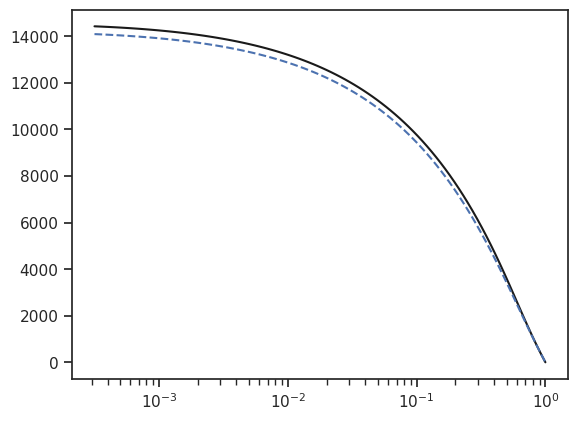

In [43]:
a_val_CG = np.logspace(-3.5,0,100)
a_val = np.logspace(-3.5,0,100)


#initialize_cosmology_CuGal(cosmo_testing, [0, 0, 0, 0.0, 0,0])
plt.plot(a_val_CG, comoving_radial_dist_CuGal(cosmo_testing, a_val), "k")
plt.plot(a_val, ccl.comoving_radial_distance(cosmo_testing,a_val), "b--")
plt.xscale("log")

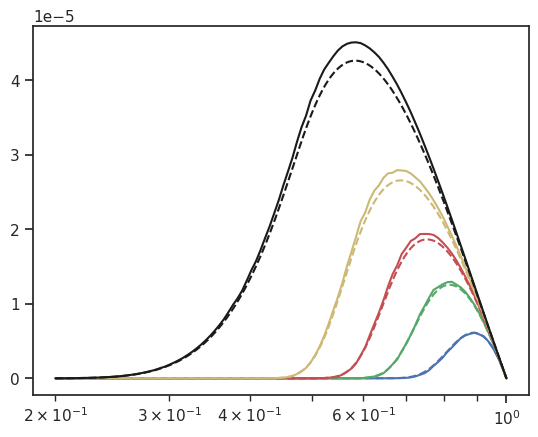

In [44]:
zmax = 4
a_val = np.logspace(np.log10(1/(1+zmax)),np.log10(1), int(5e2)) 
a_val_CG = np.logspace(np.log10(1/(1+zmax)),np.log10(1), int(100)) 

#initialize_cosmology_CuGal(cosmo_testing, [0, 0, 0, 0.0, 0,0])
#plt.plot(a_val, comoving_radial_dist_CuGal(cosmo_testing, a_val), "k")
#plt.plot(a_val, ccl.comoving_radial_distance(cosmo_testing,a_val), "b--")

plt.plot(a_val_CG,q_kappa_CuGal(0, cosmo_testing,[0, 0, 0, 1.0, 0,0], z, Binned_distribution_source), "b")
plt.plot(a_val,q_kappa(0, cosmo_testing, z, Binned_distribution_source), "b--")
plt.plot(a_val_CG,q_kappa_CuGal(1, cosmo_testing,[0, 0, 0, 1.0, 0,0], z, Binned_distribution_source), "g")
plt.plot(a_val,q_kappa(1, cosmo_testing, z, Binned_distribution_source), "g--")
plt.plot(a_val_CG,q_kappa_CuGal(2, cosmo_testing,[0, 0, 0, 1.0, 0,0], z, Binned_distribution_source), "r")
plt.plot(a_val,q_kappa(2, cosmo_testing, z, Binned_distribution_source), "r--")
plt.plot(a_val_CG,q_kappa_CuGal(3, cosmo_testing,[0, 0, 0, 1.0, 0,0], z, Binned_distribution_source), "y")
plt.plot(a_val,q_kappa(3, cosmo_testing, z, Binned_distribution_source), "y--")
plt.plot(a_val_CG,q_kappa_CuGal(4, cosmo_testing,[0, 0, 0, 1.0, 0,0], z, Binned_distribution_source), "k")
plt.plot(a_val,q_kappa(4, cosmo_testing, z, Binned_distribution_source), "k--")
plt.xscale("log")

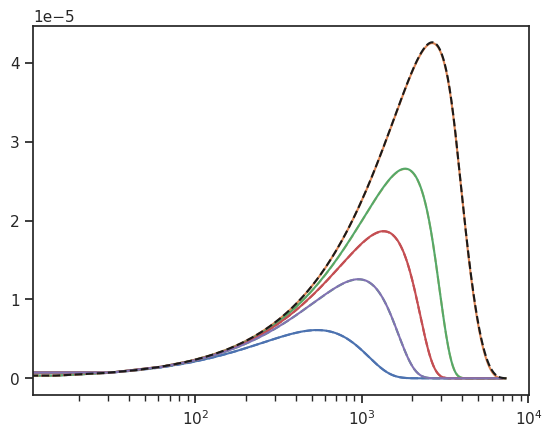

In [45]:
z_max = 4
a_val = np.logspace(np.log10(1/(1+z_max)),np.log10(1), int(5e2)) 

#initialize_cosmology_CuGal(cosmo_testing, [0, 0, 0, 1.0, 0,0])
#plt.plot(a_val, comoving_radial_dist_CuGal(cosmo_testing, a_val), "k")
#plt.plot(a_val, ccl.comoving_radial_distance(cosmo_testing,a_val), "b--")
ccl_testtracer = ccl.tracers.get_lensing_kernel(cosmo_testing, dndz=(z, Binned_distribution_source[0]))
plt.plot(ccl_testtracer[0], ccl_testtracer[1])
plt.plot(ccl.comoving_radial_distance(cosmo_testing,a_val),q_kappa(0, cosmo_testing, z, Binned_distribution_source), "b--")
plt.plot(ccl.comoving_radial_distance(cosmo_testing,a_val),q_kappa(1, cosmo_testing, z, Binned_distribution_source), "g--")
plt.plot(ccl.comoving_radial_distance(cosmo_testing,a_val),q_kappa(2, cosmo_testing, z, Binned_distribution_source), "r--")
plt.plot(ccl.comoving_radial_distance(cosmo_testing,a_val),q_kappa(3, cosmo_testing, z, Binned_distribution_source), "y--")

ccl_testtracer = ccl.tracers.get_lensing_kernel(cosmo_testing, dndz=(z, Binned_distribution_source[4]))
plt.plot(ccl_testtracer[0], ccl_testtracer[1])
ccl_testtracer = ccl.tracers.get_lensing_kernel(cosmo_testing, dndz=(z, Binned_distribution_source[3]))
plt.plot(ccl_testtracer[0], ccl_testtracer[1])
ccl_testtracer = ccl.tracers.get_lensing_kernel(cosmo_testing, dndz=(z, Binned_distribution_source[2]))
plt.plot(ccl_testtracer[0], ccl_testtracer[1])
ccl_testtracer = ccl.tracers.get_lensing_kernel(cosmo_testing, dndz=(z, Binned_distribution_source[1]))
plt.plot(ccl_testtracer[0], ccl_testtracer[1])



plt.plot(ccl.comoving_radial_distance(cosmo_testing,a_val),q_kappa(4, cosmo_testing, z, Binned_distribution_source), "k--")
plt.xscale("log")


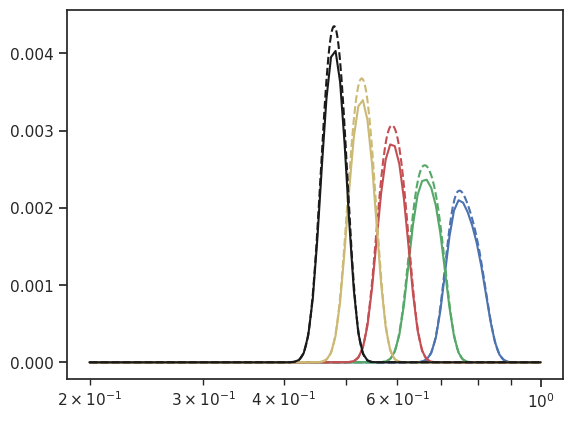

In [46]:
z_max = 4   
a_val = np.logspace(np.log10(1/(1+z_max)),np.log10(1), int(5e2)) 
a_val_CG = np.logspace(np.log10(1/(1+z_max)),np.log10(1), int(100)) 

#initialize_cosmology_CuGal(cosmo_testing, [0, 0, 0, 0.0, 0,0])
#plt.plot(a_val, comoving_radial_dist_CuGal(cosmo_testing, a_val), "k")
#plt.plot(a_val, ccl.comoving_radial_distance(cosmo_testing,a_val), "b--")
plt.plot(a_val_CG,q_delta_CuGal(0, cosmo_testing,[0, 0, 0, 1.0, 0,0], z, Binned_distribution_lens, Bias_distribution_fiducial), "b")
plt.plot(a_val,q_delta(0, cosmo_testing, z, Binned_distribution_lens, Bias_distribution_fiducial), "b--")
plt.plot(a_val_CG,q_delta_CuGal(1, cosmo_testing,[0, 0, 0, 1.0, 0,0], z, Binned_distribution_lens, Bias_distribution_fiducial), "g")
plt.plot(a_val,q_delta(1, cosmo_testing, z, Binned_distribution_lens, Bias_distribution_fiducial), "g--")
plt.plot(a_val_CG,q_delta_CuGal(2, cosmo_testing,[0, 0, 0, 1.0, 0,0], z, Binned_distribution_lens, Bias_distribution_fiducial), "r")
plt.plot(a_val,q_delta(2, cosmo_testing, z, Binned_distribution_lens, Bias_distribution_fiducial), "r--")
plt.plot(a_val_CG,q_delta_CuGal(3, cosmo_testing,[0, 0, 0, 1.0, 0,0], z, Binned_distribution_lens, Bias_distribution_fiducial), "y")
plt.plot(a_val,q_delta(3, cosmo_testing, z, Binned_distribution_lens, Bias_distribution_fiducial), "y--")
plt.plot(a_val_CG,q_delta_CuGal(4, cosmo_testing,[0, 0, 0, 1.0, 0,0], z, Binned_distribution_lens, Bias_distribution_fiducial), "k")
plt.plot(a_val,q_delta(4, cosmo_testing, z, Binned_distribution_lens, Bias_distribution_fiducial), "k--")
plt.xscale("log")

In [31]:
initialize_cosmology_CuGal(cosmo_testing, [0, 0, 0, 0.0, 0,0])


/global/homes/c/carolazn/.conda/envs/HiCOLA_Env/lib/python3.12/site-packages/scipy/integrate/_ivp/ivp.py:621: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)
<lambdifygenerated-13>:2: RuntimeWarning: divide by zero encountered in scalar divide
  return 2.0*E**2.0*g_31*phiprime**3.0/((1.0 - 1.0*(1.0*E - 0.5*E**3.0*g_31*phiprime**3.0)/E)**2 - 1.0 + 1.0*(1.0*E - 0.5*E**3.0*g_31*phiprime**3.0)/E + 1.0*(-1.5*E**3.0*g_31*phiprime**2.0*phiprimeprime + Eprime*(-1.5*E**2.0*g_31*phiprime**3.0 + 1.0))/E - 0.5*(2.0*E*Eprime + 1.0*E**2.0*k_1*phiprime**2.0 - 1.0*E**3.0*g_31*phiprime**2.0*(E*phiprimeprime + Eprime*phiprime) + 3.0*E**4.0*g_31*phiprime**3.0)/E**2)
<lambdifygenerated-14>:2: RuntimeWarning: invalid value encountered in scalar divide
  return (1.0 - 1.0*(1.0*E - 0.5*E**3.0*g_31*phiprime**3.0)/E)/((1.0 - 1.0*(1.0*E - 0.5*E**3.0*g_31*phiprime**3.0)/E)**2 -

In [57]:

manualdata = findC_ell_deldel_CuGal(0,0, cosmo_testing, [0,0,0,0.0,0,0],z, bins(20, 1478.5, 13), Binned_distribution_source, Binned_distribution_lens,Bias_distribution_fiducial)

print(manualdata.shape)


In [58]:
binned_ell = bin_ell_kk(20, 1478.5, 13, Binned_distribution_source)
"""GR"""
# find C_ell for non-linear matter power spectrum
start = time.time()
testdata = Cell_GR(binned_ell, \
                cosmo_testing, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,\
                tracer1_type="g", tracer2_type="g")

D_testdata_kk = testdata[1]

D_testdata_kk = (np.array(D_testdata_kk)).flatten()[:len(manualdata)]

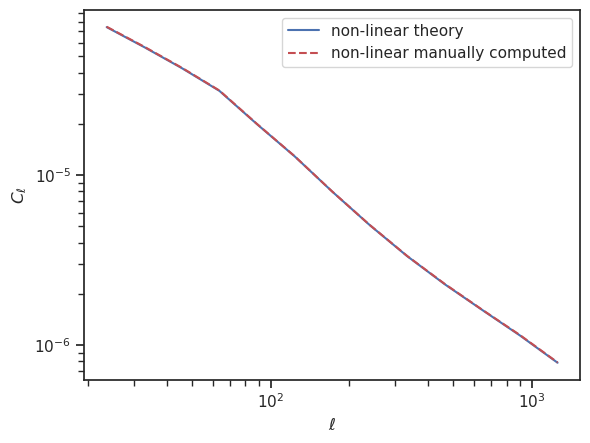

In [59]:
plt.plot(bins(20, 1478.5, 13), D_testdata_kk, "b", label = "non-linear theory")
plt.plot(bins(20, 1478.5, 13),manualdata, "r",linestyle="--",  label = "non-linear manually computed")

#plt.plot(ell, data/manualdata)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell$')
plt.legend()

In [ ]:
# NL matter power spectra boost in fR
def B_k_NL_CuGal(cosmo, MGparams, k, a):
    """
    input k (array) -> wavevector, units 1/Mpc
    input a (float or array) -> scale factor (1/(1+z))
    input cosmo (cosmology object) -> Cosmology object from CCL
    input MGparams (array) -> Modified gravity parameters ([Omega_rc, fR0, n, mu])
    
    output Pk_fR (array) -> Nonlinear matter power spectrum for Hu-Sawicki fR gravity, units (Mpc)^3
    """
    H0rc, fR0, n, f_phi, mu, Sigma = MGparams

    if isinstance(a, (float, int)):  # Single scale factor case
        input_params_and_redshift = np.append(
            np.array([cosmo["Omega_m"], cosmo["n_s"], 1e9 * cosmo["A_s"], cosmo["h"], f_phi]),
            1.0 / a - 1.0
        )
        bk_target, err_target = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list, z_all)
        interp_func = scipy.interpolate.interp1d(k_all * cosmo["h"], bk_target.flatten(), kind='linear', fill_value="extrapolate")
        pkratio_CuGal = interp_func(k)
        
    else:
        bk_target = []
        z_range = 1.0 / a - 1.0  # Array of redshift values

        # Loop over each redshift value
        for z_val in z_range:
            input_params_and_redshift = np.append(
                np.array([cosmo["Omega_m"], cosmo["n_s"], 1e9 * cosmo["A_s"], cosmo["h"], f_phi]),
                z_val
            )
            bk_target_i, _ = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list, z_all)
            bk_target.append(bk_target_i.flatten()) 
    
        # Convert list to array with shape (len(a), len(k_all))
        bk_target = np.array(bk_target)

        # Interpolating each row in bk_target over k
        pkratio_CuGal = np.array([
            scipy.interpolate.interp1d(k_all * cosmo["h"], bk_row, kind='linear', fill_value="extrapolate")(k) 
            for bk_row in bk_target
        ])
    
    return pkratio_CuGal

In [103]:
"""Explicit functions to find Cell-GR example"""

"""radial kernel - shear"""
def q_kappa(i, cosmo, z, Binned_distribution_s):
    # takes in the cosmology
    # finds radial kernel for the n_{i}th bin of the source redshift distribution
    c=3e5
    zmax = 6.                                                              # z at horizon from Planck 2018
    z_var = np.linspace(0.001, 4., int(1e2))                              # find useful functs of z
    a = 1/(1 + z_var)
    chiz = ccl.comoving_radial_distance(cosmo,a)                           # units of Mpc
    
    q_kappa_array = []   
    for k in range(len(z_var)):                                                # TODO is this a reasonable way of calculating this stuff?
        zp = np.linspace(z_var[k],zmax,int(1e4))                                # variable we integrate over
        ap = 1/(1 + zp)
        chip = ccl.comoving_radial_distance(cosmo,ap)
        n_p = np.interp(zp, z , Binned_distribution_s[i])
        integrand = n_p*chiz[k]*(chip - chiz[k])/(a[k]*chip)
        q_k = scipy.integrate.simps(integrand, zp)*3*cosmo['Omega_m']*(cosmo['H0']**2)/2/c/c
        q_kappa_array.append([q_k])

    return np.array(q_kappa_array).reshape(len(q_kappa_array))

"""radial kernel - galaxy clustering"""
def q_delta(i, cosmo, z, Binned_distribution_l,Bias_distribution):
    
    # takes in the cosmology
    # finds radial kernel for the n_{i}th bin of the lens redshift distribution
    c=3e5
    zmax = 6.                                                              # z at horizon from Planck 2018
    z_var = np.linspace(0.001, 4., int(1e2))                              # find useful functs of z

    a = 1/(1 + z_var)
    chiz = ccl.comoving_radial_distance(cosmo,a)                           # units of Mpc
    dzdchi = ccl.h_over_h0(cosmo,a) * cosmo['H0'] / c
    n_p = np.interp(z_var, z , Binned_distribution_l[i])
    
    q_del = dzdchi * np.interp(z_var, z ,Bias_distribution[i]) * n_p

    return np.array(q_del).reshape(len(q_del))
    
def findC_ell_kk(i,j, cosmo, z, ell, Binned_distribution_s, Binned_distribution_l,Bias_distribution):

    c = 3e5
    z_var = np.linspace(0.001, 4., int(1e2))                              # find useful functs of z
    a = 1/(1 + z_var)
    chiz = ccl.comoving_radial_distance(cosmo,a)
    q_k_val_i = q_kappa(i, cosmo, z, Binned_distribution_s)          # find tomographic lens efficiency
    q_k_val_j = q_kappa(j, cosmo, z, Binned_distribution_s)          # find tomographic lens efficiency

    C_ell = []
    for k in range(len(ell)):
        integrand = q_k_val_i*q_k_val_j/ccl.h_over_h0(cosmo,a)/chiz**2/cosmo['H0'] * c
        #integrand = q_k_val_i*q_k_val_j/chiz**2
        integrand = integrand*np.diag(ccl.nonlin_matter_power(cosmo, (ell[k] + 0.5)/chiz , a))
        C_ell.append([scipy.integrate.simps(integrand, z_var)])
    
    return np.array(C_ell)

def findC_ell_delk(i,j, cosmo, z, ell, Binned_distribution_s, Binned_distribution_l,Bias_distribution):

    c = 3e5
    z_var = np.linspace(0.001, 4., int(1e2))                              # find useful functs of z
    a = 1/(1 + z_var)
    chiz = ccl.comoving_radial_distance(cosmo,a)
    q_k_val_i = q_kappa(i, cosmo, z, Binned_distribution_s)          # find tomographic lens efficiency
    q_k_val_j = q_delta(j, cosmo, z, Binned_distribution_l,Bias_distribution)          # find tomographic lens efficiency

    C_ell = []
    for k in range(len(ell)):
        integrand = q_k_val_i*q_k_val_j/ccl.h_over_h0(cosmo,a)/chiz**2/cosmo['H0'] * c
        integrand = integrand*np.diag(ccl.nonlin_matter_power(cosmo, (ell[k] + 0.5)/chiz , a))
        C_ell.append([scipy.integrate.simps(integrand, z_var)])
    
    return np.array(C_ell)

def findC_ell_deldel(i,j, cosmo, z, ell, Binned_distribution_s, Binned_distribution_l,Bias_distribution):

    c = 3e5
    z_var = np.linspace(0.001, 4., int(1e2))                              # find useful functs of z
    a = 1/(1 + z_var)
    chiz = ccl.comoving_radial_distance(cosmo,a)
    q_k_val_i = q_delta(i, cosmo, z, Binned_distribution_l,Bias_distribution)          # find tomographic lens efficiency
    q_k_val_j = q_delta(j, cosmo, z, Binned_distribution_l,Bias_distribution)          # find tomographic lens efficiency

    C_ell = []
    for k in range(len(ell)):
        integrand = q_k_val_i*q_k_val_j/ccl.h_over_h0(cosmo,a)/chiz**2/cosmo['H0'] * c
        integrand = integrand*np.diag(ccl.nonlin_matter_power(cosmo, (ell[k] + 0.5)/chiz , a))
        C_ell.append([scipy.integrate.simps(integrand, z_var)])
    
    return np.array(C_ell)

### tests correlation #####

In [69]:
labels = [r"$\Omega_c$", r"$\mu_0 / \Omega_{rc}$",r"$10^{9}A_s$", r"$h$", r"$n_s$", r"$\omega_b$",\
         r'$b_1$', r'$b_2$', r'$b_3$', r'$b_4$', r'$b_5$']

value1 = [cosmo_universe["Omega_c"], 0.0, cosmo_universe["A_s"]*1e9, cosmo_universe["h"],\
          cosmo_universe["n_s"],cosmo_universe["Omega_b"]*cosmo_universe["h"]**2,\
         Bias_distribution_fiducial[0][0], Bias_distribution_fiducial[1][0],\
         Bias_distribution_fiducial[2][0],Bias_distribution_fiducial[3][0],\
         Bias_distribution_fiducial[4][0]]

mean = []
for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    mean.append(mcmc[1])

print(mean)

[0.27637272680074115, 0.06816506363481538, 2.1205526981435647, 0.694539477172393, 0.9743523047204532, 0.02262303666470148, 1.2374821573564994, 1.3746086443928733, 1.5166251705845664, 1.6556215044805374, 1.8068076315651296]


In [41]:
sampler_scalecut_arr = np.load("/home/c2042999/PCA_project/chains/3x2pt_DEparam_bias/nDGP_DEParam_scalecut.npy")
burnin = 1000

ndim = len(labels)

final_length = len(sampler_scalecut_arr)*(len(sampler_scalecut_arr[0])-burnin)

flat_samples = sampler_scalecut_arr[:,burnin:].reshape(final_length,ndim)
print(flat_samples.shape)

In [72]:
print(flat_samples.shape)
print(np.cov(flat_samples.T))

(87500, 11)
[[ 1.37241273e-04 -1.03677037e-04 -6.07399135e-04 -2.08931292e-04
  -8.24467381e-06 -2.51032013e-07  4.13033545e-04  4.54268418e-04
   4.47776994e-04  5.94651742e-04  5.08702802e-04]
 [-1.03677037e-04  1.76286176e-03 -1.17427177e-03  1.33548621e-04
  -1.69666017e-05 -4.88379217e-07 -4.12557527e-04 -1.46035442e-04
  -5.65662952e-05  1.25415269e-04  1.58532208e-04]
 [-6.07399135e-04 -1.17427177e-03  9.38238506e-03  3.44648524e-05
   2.68872331e-04  4.65424204e-06 -1.65610330e-03 -1.82803704e-03
  -1.62626922e-03 -2.75497589e-03 -2.04213289e-03]
 [-2.08931292e-04  1.33548621e-04  3.44648524e-05  4.93293874e-04
  -1.97699903e-05  6.85395213e-08 -6.65592607e-04 -7.82695771e-04
  -8.25393962e-04 -1.01952101e-03 -9.41244214e-04]
 [-8.24467381e-06 -1.69666017e-05  2.68872331e-04 -1.97699903e-05
   5.13980055e-05  1.04088363e-06 -9.01379470e-06 -1.39781496e-05
  -1.60233604e-05 -1.32939877e-05 -8.41307715e-06]
 [-2.51032013e-07 -4.88379217e-07  4.65424204e-06  6.85395213e-08
   1.04

In [73]:
df = pd.DataFrame(flat_samples, columns=labels, index=np.arange(0,len(flat_samples)))
print(df.head())

   $\Omega_c$  $\mu_0 / \Omega_{rc}$  $10^{9}A_s$       $h$     $n_s$  \
0    0.279773               0.112709     2.105487  0.675283  0.977861   
1    0.280628               0.110776     2.099131  0.675101  0.976389   
2    0.280628               0.110776     2.099131  0.675101  0.976389   
3    0.280628               0.110776     2.099131  0.675101  0.976389   
4    0.282359               0.111998     2.090269  0.673001  0.976481   

   $\omega_b$     $b_1$     $b_2$     $b_3$     $b_4$     $b_5$  
0    0.022108  1.208415  1.401732  1.544271  1.689624  1.861527  
1    0.022081  1.211211  1.404235  1.542978  1.695261  1.860751  
2    0.022081  1.211211  1.404235  1.542978  1.695261  1.860751  
3    0.022081  1.211211  1.404235  1.542978  1.695261  1.860751  
4    0.022118  1.242664  1.423183  1.547156  1.701338  1.861256  


In [83]:
C = np.cov(flat_samples.T)

chain2 = Chain.from_covariance(
    mean, C,
    plot_contour=True, columns=labels, 
    color='blue', name=r'from covariance', 
    linewidth=1, linestyle='-'
)

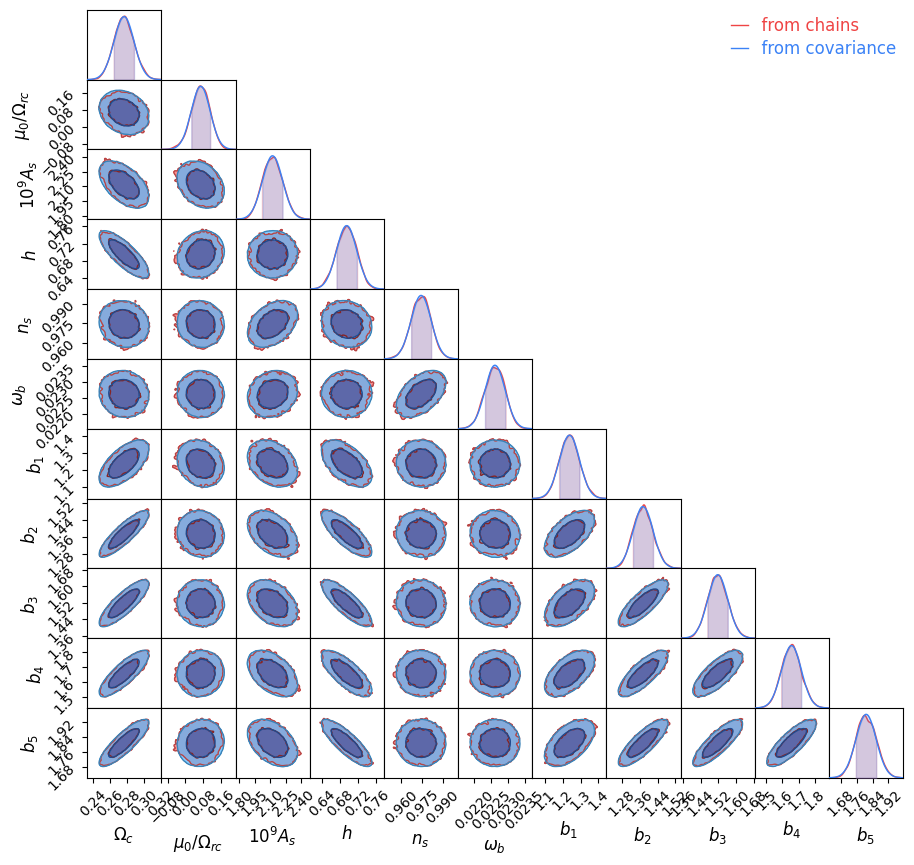

In [84]:
c = ChainConsumer()
c.add_chain(Chain(samples=df, color="r", name="from chains"))
c.add_chain(chain2)
fig = c.plotter.plot(figsize = 0.3)
